# Circadian cycles Analysis first week of crisis

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import powerlaw, truncnorm, ks_2samp
import powerlaw
import random

# Simple trapezoid integration for NumPy 2.0+ compatibility
def trapz(y, x):
    return np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2)


In [43]:
# import datasets
df = pd.read_json("../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.
df_links = pd.read_csv("../../Datasets/voluntariosdanavalencia_extracted_links.csv") # Import data from Voluntarios de Valencia groupchat with messages with links and misinformation score.
df_users = pd.read_csv("../../Datasets/voluntariosdanavalencia_extracted_users.csv") # Import data from Voluntarios de Valencia groupchat with user information.

## Prepare data

In [44]:
def normalize_data(df):
    df["id"]= pd.to_numeric(df["id"], errors='coerce').astype('Int64')   # Convert 'id' to numeric, coercing errors to NaN.
    df["sender_id"]= pd.to_numeric(df["sender_id"], errors='coerce').astype('Int64')   # Convert 'sender_id' to numeric, coercing errors to NaN.
    df["date"]= pd.to_datetime(df["date"], errors='coerce')   # Convert 'date' to datetime, coercing errors to NaT.
    df["edit_date"]= pd.to_datetime(df["edit_date"], errors='coerce')   # Convert 'edit_date' to datetime, coercing errors to NaT.
    df["reply_to_msg_id"]= pd.to_numeric(df["reply_to_msg_id"], errors='coerce').astype('Int64')   # Convert 'reply_to_message_id' to numeric, coercing errors to NaN.
    df["views"]= pd.to_numeric(df["views"], errors='coerce').astype('Int64')   # Convert 'views' to numeric, coercing errors to NaN.
    df["forwards"]= pd.to_numeric(df["forwards"], errors='coerce').astype('Int64')   # Convert 'forwards' to numeric, coercing errors to NaN.
    return df
df = normalize_data(df) # Normalize the data types of the DataFrame columns.

In [45]:
# Gather users with more than 40 messages of the groupchat.
user_message_counts = df['sender_id'].value_counts()
active_users = user_message_counts[user_message_counts > 40].index.tolist()
active_users_message_counts = user_message_counts[user_message_counts > 40]
# Print the number of active users.
print(f"Number of active users (more than 40 messages): {len(active_users)}")


Number of active users (more than 40 messages): 67


In [46]:
df = df.sort_values('date') # Sort messages by date to calculate inter-event times correctly.

# Calcular inter-event times en segundos
df['iet'] = df['date'].diff().dt.total_seconds()



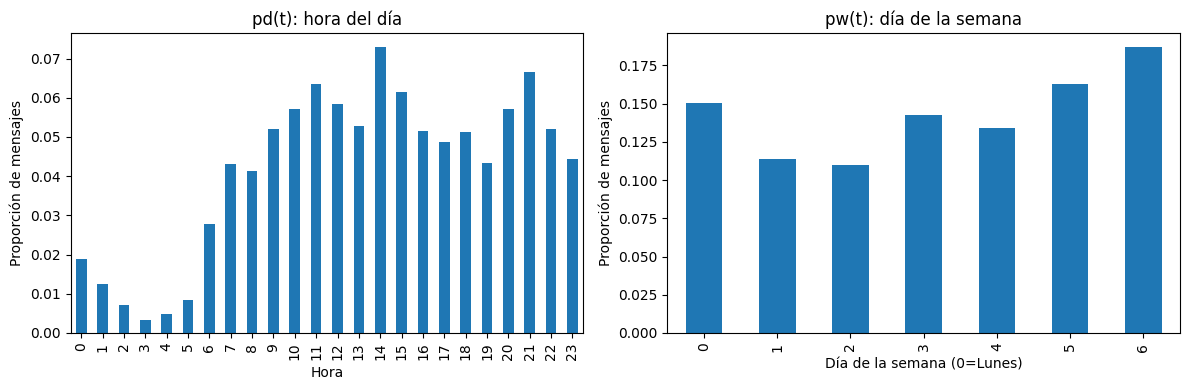

In [47]:
df['hour'] = df['date'].dt.hour
df['weekday'] = df['date'].dt.weekday  # 0=lunes

if df.empty:
    print("df está vacío: no hay datos para la primera semana. Revisa el filtrado de fechas.")
else:
    # pd(t): distribución por hora del día (aseguramos horas 0-23)
    hours = list(range(24))
    pd_t_counts = df.groupby('hour').size()
    pd_t = pd_t_counts.reindex(hours, fill_value=0) / len(df)

    # pw(t): distribución por día de la semana (aseguramos días 0-6)
    days = list(range(7))
    pw_t_counts = df.groupby('weekday').size()
    pw_t = pw_t_counts.reindex(days, fill_value=0) / len(df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    pd_t.plot(kind='bar', ax=axes[0], title='pd(t): hora del día')
    pw_t.plot(kind='bar', ax=axes[1], title='pw(t): día de la semana')
    axes[0].set_xlabel('Hora')
    axes[0].set_ylabel('Proporción de mensajes')
    axes[1].set_xlabel('Día de la semana (0=Lunes)')
    axes[1].set_ylabel('Proporción de mensajes')
    plt.tight_layout()
    plt.show()

## Active intervals identification (Annealing)

In [48]:

def compute_model_params(events, active_config):
    """
    events: array de tiempos en HORAS (relative to start).
    active_config: array booleano, True = mismo active interval que el evento anterior
    """
    # Separar inter-event times dentro y fuera de active intervals
    iets = np.diff(events)  # en horas
    
    iet_active = iets[active_config[1:]]   # dentro de cascadas
    iet_between = iets[~active_config[1:]] # entre cascadas
    
    # ρa: tasa dentro de active intervals (si es Poisson, es 1/mean)
    rho_a = 1.0 / np.mean(iet_active) if len(iet_active) > 0 else 0
    
    # Nw: número medio de active intervals por semana
    n_active_intervals = np.sum(~active_config[1:]) + 1
    total_weeks = (events[-1] - events[0]) / (7 * 24)  # events en horas, semanas en horas
    Nw = n_active_intervals / total_weeks if total_weeks > 0 else 0
    
    # pd(t) y pw(t) a partir de los inicios de active intervals
    starts_idx = np.where(~active_config[1:])[0] + 1
    start_times = events[starts_idx]  # ya en horas
    
    # Hora del día (0-24) y día de la semana (0-7)
    hours = start_times % 24
    weekdays = (start_times / 24) % 7
    
    # Histogramas: contar y normalizar a probabilidad discreta
    pd_counts, _ = np.histogram(hours, bins=24, range=(0, 24))
    pw_counts, _ = np.histogram(weekdays, bins=7, range=(0, 7))
    pd_t = pd_counts.astype(float) / pd_counts.sum() if pd_counts.sum() > 0 else np.zeros(24)
    pw_t = pw_counts.astype(float) / pw_counts.sum() if pw_counts.sum() > 0 else np.zeros(7)
    
    return rho_a, Nw, pd_t, pw_t

def area_test_statistic(empirical_iet, model_iet, n_bins=100, eps=1e-6):
    """
    Área entre CCDFs empírica y del modelo (en escala log).
    Esta versión evita llamadas a `np.trapz` y protege contra valores no positivos o NaN.
    """
    emp = np.asarray(empirical_iet)
    mod = np.asarray(model_iet)
    # Filtrar valores no finitos y no positivos (log escala requiere >0)
    emp = emp[np.isfinite(emp) & (emp > 0)]
    mod = mod[np.isfinite(mod) & (mod > 0)]
    if len(emp) == 0 or len(mod) == 0:
        return np.inf
    # límites seguros para la malla logarítmica
    lo = max(emp.min(), mod.min(), eps)
    hi = max(emp.max(), mod.max(), lo * 10)
    log_bins = np.logspace(np.log10(lo), np.log10(hi), n_bins)
    # CCDF = P(X > b)
    ccdf_emp = np.array([np.mean(emp > b) for b in log_bins])
    ccdf_mod = np.array([np.mean(mod > b) for b in log_bins])
    # Usar la implementación local `trapz(y, x)` definida arriba
    return trapz(np.abs(ccdf_emp - ccdf_mod), np.log(log_bins))

def simulate_cascading_nhpp(rho_a, Nw, pd_t, pw_t, p_Na, 
                             total_hours, n_samples):
    """
    Simula el cascading nonhomogeneous Poisson process
    """
    # Reconstruir ρ(t) = Nw * pd(t) * pw(t)
    # Simplificación: muestrear inicio de active intervals
    # y luego añadir Na eventos adicionales con tasa rho_a
    
    events = []
    t = 0
    week_hours = 7 * 24
    
    while t < total_hours:
        # Tiempo hasta próximo active interval
        # Usando inversión de la CDF de ρ(t) (simplificado)
        rate_mean = Nw / week_hours  # tasa media por hora
        dt = np.random.exponential(1.0 / rate_mean)
        t += dt
        
        if t >= total_hours:
            break
            
        events.append(t)
        
        # Na eventos adicionales en esta cascada
        Na = np.random.choice(len(p_Na), p=p_Na/p_Na.sum())
        for _ in range(Na):
            dt_a = np.random.exponential(1.0 / rho_a)
            t += dt_a
            if t < total_hours:
                events.append(t)
    
    return np.array(sorted(events))[:n_samples]

def simulated_annealing(events_hours, n_iter=5000, T_init=1.0, cooling=0.95):
    """
    SA para encontrar la configuración óptima de active intervals
    """
    N = len(events_hours)
    iets = np.diff(events_hours)
    
    # Inicializar: separar en active intervals donde IET < umbral
    threshold = np.median(iets)
    config = iets < threshold  # True = mismo active interval
    
    # Calcular p(Na) inicial
    def get_pNa(config, max_Na=10):
        na_counts = []
        count = 0
        for c in config:
            if c:
                count += 1
            else:
                na_counts.append(count)
                count = 0
        na_counts.append(count)
        hist = np.bincount(na_counts, minlength=max_Na+1)[:max_Na+1]
        return hist / hist.sum()
    
    T = T_init
    best_config = config.copy()
    
    rho_a, Nw, pd_t, pw_t = compute_model_params(events_hours, 
                                                   np.concatenate([[False], config]))
    p_Na = get_pNa(config)
    
    model_events = simulate_cascading_nhpp(
        rho_a, Nw, pd_t, pw_t, p_Na,
        total_hours=events_hours[-1] - events_hours[0],
        n_samples=N
    )
    
    A_current = area_test_statistic(iets, np.diff(model_events) if len(model_events) > 1 else iets)
    A_best = A_current
    
    for iteration in range(n_iter):
        # Proponer cambio: flip aleatorio en config
        idx = random.randint(0, N-2)
        new_config = config.copy()
        new_config[idx] = not new_config[idx]
        
        # Recalcular parámetros y estadístico
        rho_a, Nw, pd_t, pw_t = compute_model_params(
            events_hours, 
            np.concatenate([[False], new_config])
        )
        p_Na = get_pNa(new_config)
        
        model_events = simulate_cascading_nhpp(
            rho_a, Nw, pd_t, pw_t, p_Na,
            total_hours=events_hours[-1] - events_hours[0],
            n_samples=N
        )
        
        if len(model_events) > 1:
            A_new = area_test_statistic(iets, np.diff(model_events))
        else:
            A_new = A_current + 1
        
        # Criterio de aceptación
        delta = A_new - A_current
        if delta < 0 or random.random() < np.exp(-delta / T):
            config = new_config
            A_current = A_new
            if A_new < A_best:
                A_best = A_new
                best_config = new_config.copy()
        
        # Enfriar
        if iteration % 100 == 0:
            T *= cooling
    
    return best_config, A_best

In [49]:
# Guardar parámetros por usuario
parameters_users = {}
i=0
for user_id in active_users:
    print(f"Procesando usuario {user_id}... ({i+1}/{len(active_users)})")
    i += 1
    user_events = df[df['sender_id'] == user_id]['date'].sort_values()
    if len(user_events) < 2:
        continue
    
    events_hours = (user_events - user_events.iloc[0]).dt.total_seconds() / 3600
    
    best_config, A_best = simulated_annealing(events_hours.values)
    
    rho_a, Nw, pd_t, pw_t = compute_model_params(
        events_hours.values, 
        np.concatenate([[False], best_config])
    )
    
    parameters_users[user_id] = {
        'rho_a': rho_a,
        'Nw': Nw,
        'pd_t': pd_t,
        'pw_t': pw_t,
        'A_best': A_best
    }


Procesando usuario 1762777403... (1/67)
Procesando usuario 7094531229... (2/67)
Procesando usuario 1505404600... (3/67)
Procesando usuario 271855505... (4/67)
Procesando usuario 6973904485... (5/67)
Procesando usuario 6601816159... (6/67)
Procesando usuario 6221273187... (7/67)
Procesando usuario 1095473116... (8/67)
Procesando usuario 5689570195... (9/67)
Procesando usuario 1151037126... (10/67)
Procesando usuario 1110241832... (11/67)
Procesando usuario 1457424889... (12/67)
Procesando usuario 702737014... (13/67)
Procesando usuario 2047003776... (14/67)
Procesando usuario 791270353... (15/67)
Procesando usuario 57072401... (16/67)
Procesando usuario 5212333848... (17/67)
Procesando usuario 1354320169... (18/67)
Procesando usuario 1357872899... (19/67)
Procesando usuario 6938249017... (20/67)
Procesando usuario 1131058651... (21/67)
Procesando usuario 7567764882... (22/67)
Procesando usuario 693274644... (23/67)
Procesando usuario 1065332141... (24/67)
Procesando usuario 1551829597..

/var/folders/t0/sjtcv6y97xnczv424tb3c5yc0000gn/T/ipykernel_73602/3554929584.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  rho_a = 1.0 / np.mean(iet_active) if len(iet_active) > 0 else 0


Procesando usuario 5782910539... (45/67)
Procesando usuario 1283367810... (46/67)
Procesando usuario 1669337139... (47/67)
Procesando usuario 7472715818... (48/67)
Procesando usuario 1383986630... (49/67)
Procesando usuario 709835653... (50/67)
Procesando usuario 5197641355... (51/67)
Procesando usuario 6743180623... (52/67)
Procesando usuario 223210667... (53/67)
Procesando usuario 1154304070... (54/67)
Procesando usuario 650840442... (55/67)
Procesando usuario 373434202... (56/67)
Procesando usuario 6690818723... (57/67)
Procesando usuario 1441033459... (58/67)
Procesando usuario 94837647... (59/67)
Procesando usuario 1101084020... (60/67)
Procesando usuario 2081915527... (61/67)
Procesando usuario 2041547852... (62/67)
Procesando usuario 261376227... (63/67)
Procesando usuario 1025190273... (64/67)
Procesando usuario 1591133078... (65/67)
Procesando usuario 5201154677... (66/67)
Procesando usuario 7286408806... (67/67)


In [50]:
print("Parámetros estimados para usuarios activos:")
for user_id, params in parameters_users.items():
    print(f"Usuario {user_id}: rho_a={params['rho_a']:.4f}, Nw={params['Nw']:.4f}, A_best={params['A_best']:.4f}, pd_t={params['pd_t']}, pw_t={params['pw_t']}")

Parámetros estimados para usuarios activos:
Usuario 1762777403: rho_a=62.9021, Nw=29.3400, A_best=1.1945, pd_t=[0.05909091 0.05       0.06818182 0.04090909 0.01818182 0.01363636
 0.00454545 0.         0.         0.         0.         0.
 0.04545455 0.01363636 0.02272727 0.03636364 0.09090909 0.06818182
 0.07727273 0.10909091 0.09545455 0.05       0.08181818 0.05454545], pw_t=[0.25       0.27272727 0.15909091 0.09545455 0.08636364 0.08636364
 0.05      ]
Usuario 7094531229: rho_a=62.4647, Nw=14.0461, A_best=1.5022, pd_t=[0.12037037 0.06018519 0.06018519 0.03240741 0.01851852 0.08796296
 0.0462963  0.00925926 0.03240741 0.         0.         0.
 0.         0.00925926 0.07407407 0.07407407 0.06481481 0.06481481
 0.02777778 0.03240741 0.05555556 0.02777778 0.0462963  0.05555556], pw_t=[0.19444444 0.16203704 0.2962963  0.12037037 0.0462963  0.09259259
 0.08796296]
Usuario 1505404600: rho_a=125.3082, Nw=93.0278, A_best=0.9004, pd_t=[0.06153846 0.04102564 0.02564103 0.02564103 0.03076923 0.02

In [51]:
# Simuilar cascadas para cada usuario con los parámetros obtenidos
simulated_cascades = {}
for user_id, params in parameters_users.items():
    sim_events = simulate_cascading_nhpp(
        params['rho_a'], params['Nw'], params['pd_t'], params['pw_t'], 
        p_Na=np.array([0.5, 0.3, 0.2]),  # Distribución de Na (ejemplo)
        total_hours=24*7,  # Simular una semana
        n_samples=1000     # Número de eventos a simular
    )
    simulated_cascades[user_id] = sim_events


In [52]:
# Fit all users' IETs to power-law with exponential cutoff: P(x) ∝ x^(-alpha) * exp(-lambda*x)
from scipy.optimize import minimize

def fit_power_law_with_cutoff(iets):
    """
    Fit data to power-law with exponential cutoff using MLE.
    Returns (alpha, lambda) where P(x) ∝ x^(-alpha) * exp(-lambda*x)
    """
    if len(iets) < 2:
        return None, None
    
    iets = np.asarray(iets)
    iets = iets[iets > 0]  # Remove non-positive values
    if len(iets) < 2:
        return None, None
    
    # Negative log-likelihood for power-law with exponential cutoff
    def neg_loglik(params):
        alpha, lam = params
        if alpha <= 0 or lam <= 0:
            return 1e10
        # log P(x) = -alpha*log(x) - lambda*x + const
        return np.sum(alpha * np.log(iets) + lam * iets)
    
    # Initial guess: alpha from simple power-law, lambda small
    alpha_init = 2.0
    lam_init = 0.01
    
    # Optimize
    result = minimize(neg_loglik, [alpha_init, lam_init], 
                     method='Nelder-Mead',
                     options={'maxiter': 1000})
    
    if result.success:
        alpha, lam = result.x
        return float(alpha), float(lam)
    else:
        return None, None

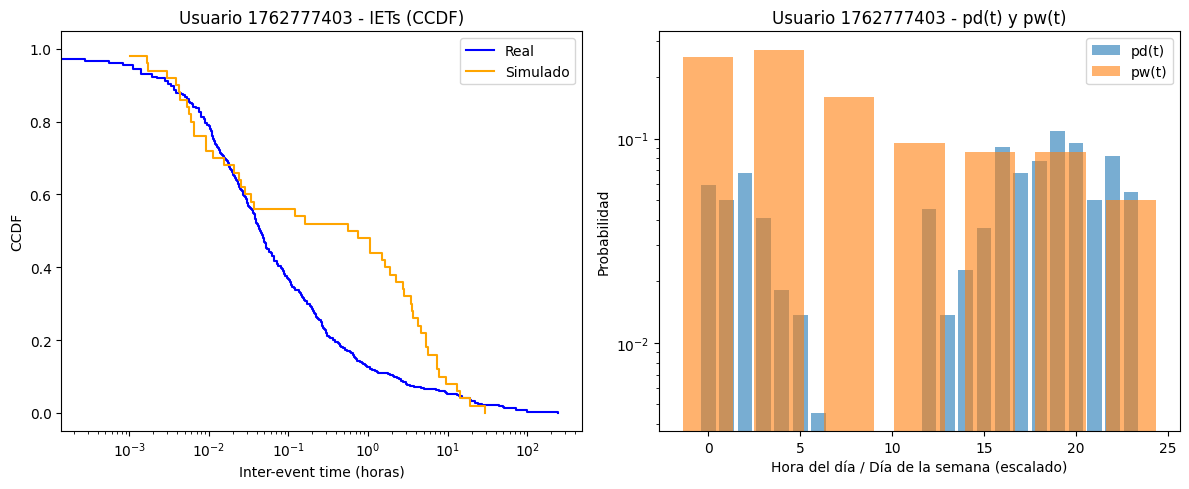

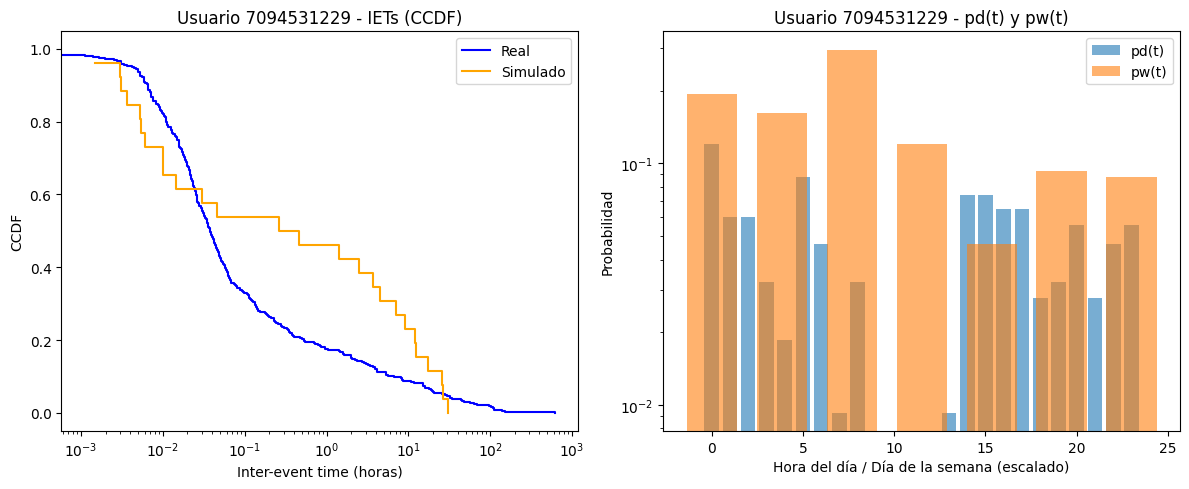

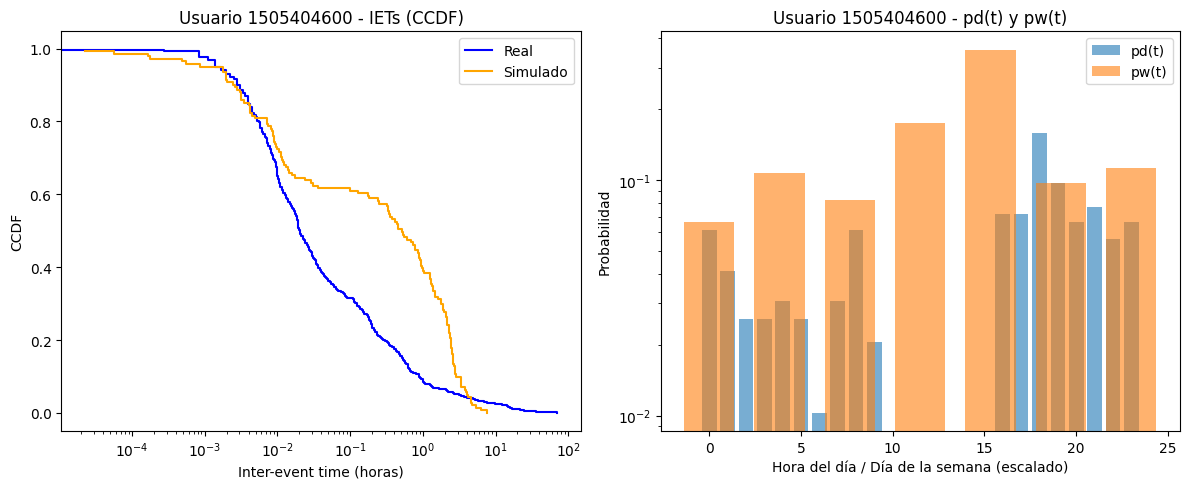

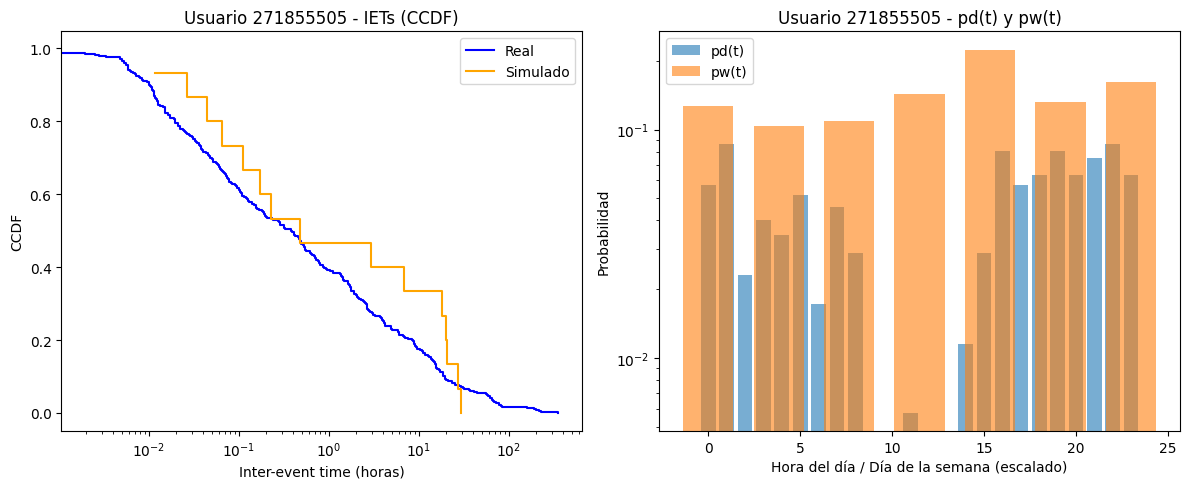

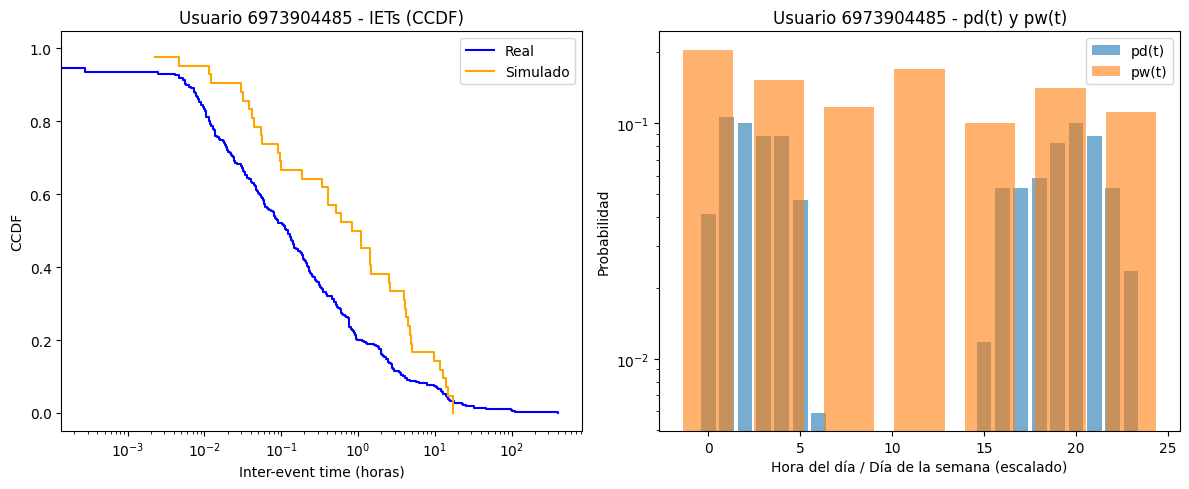

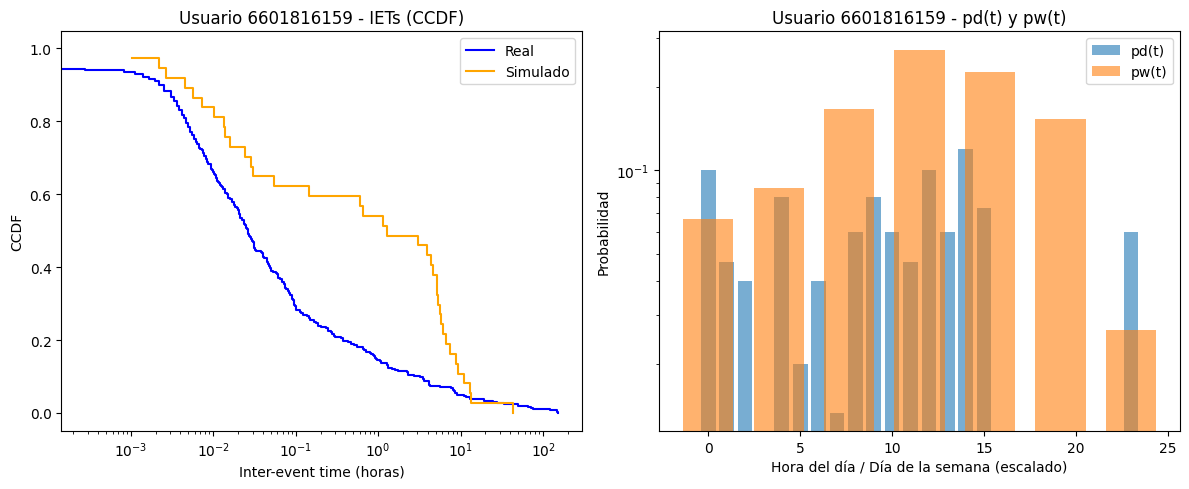

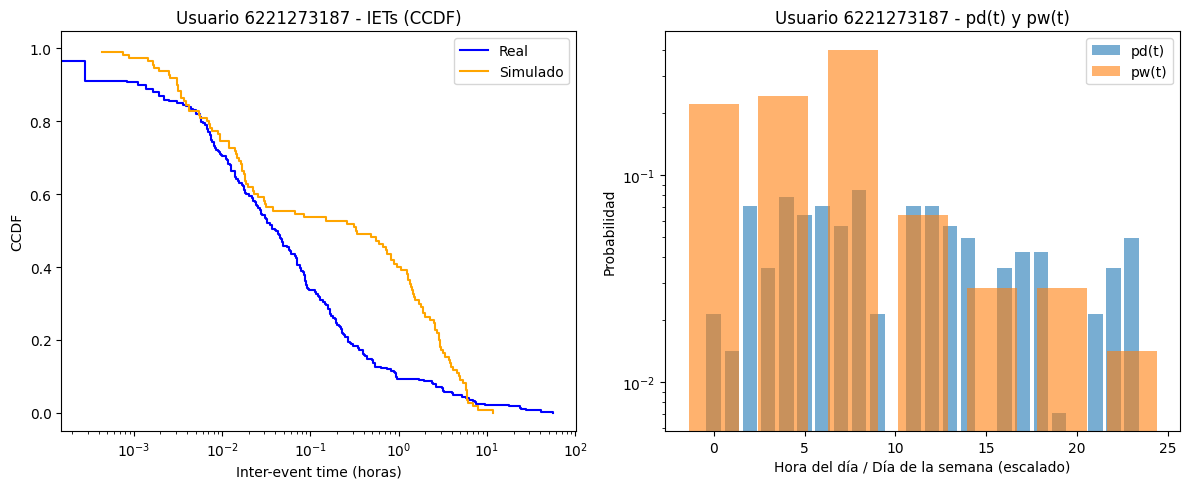

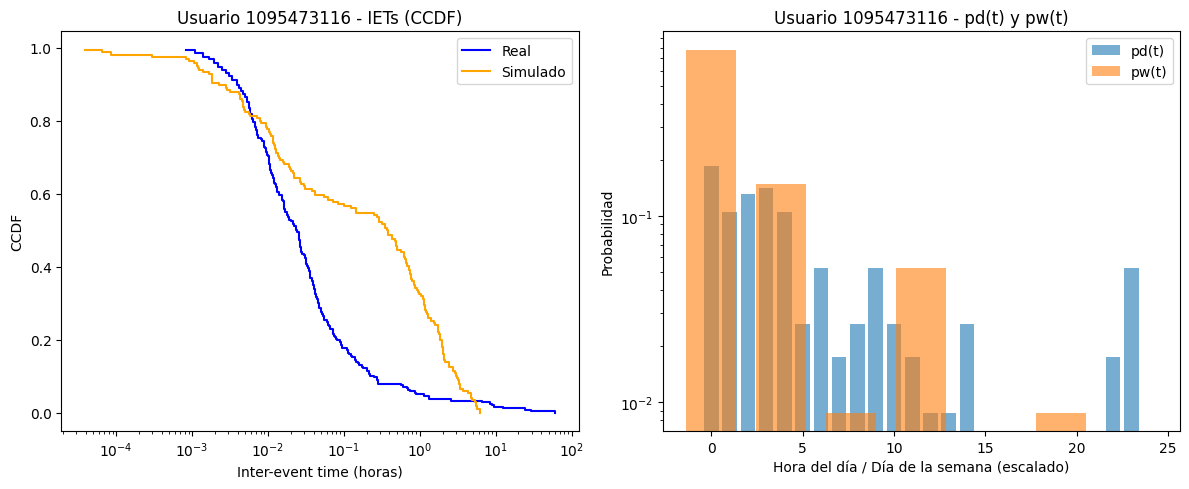

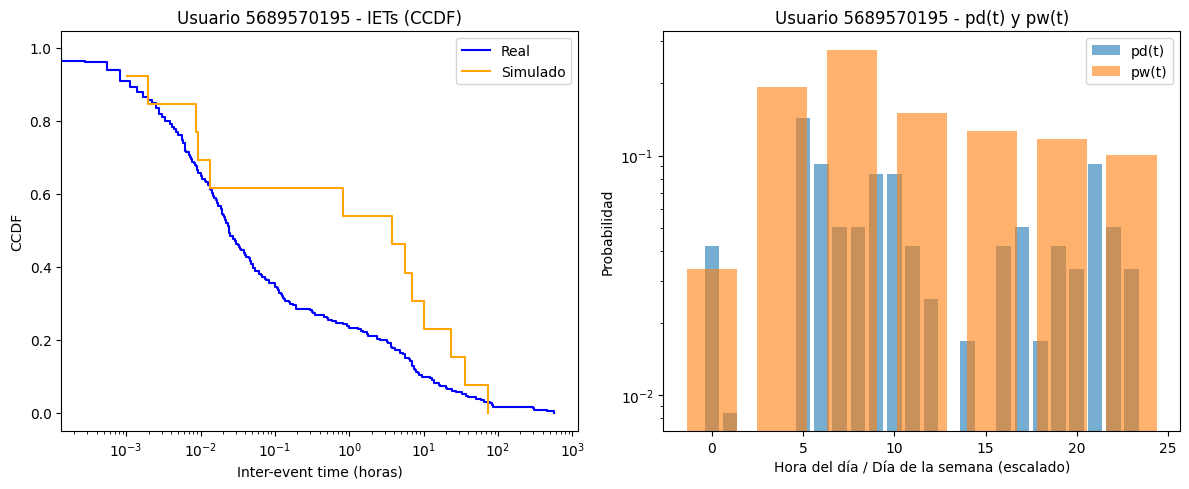

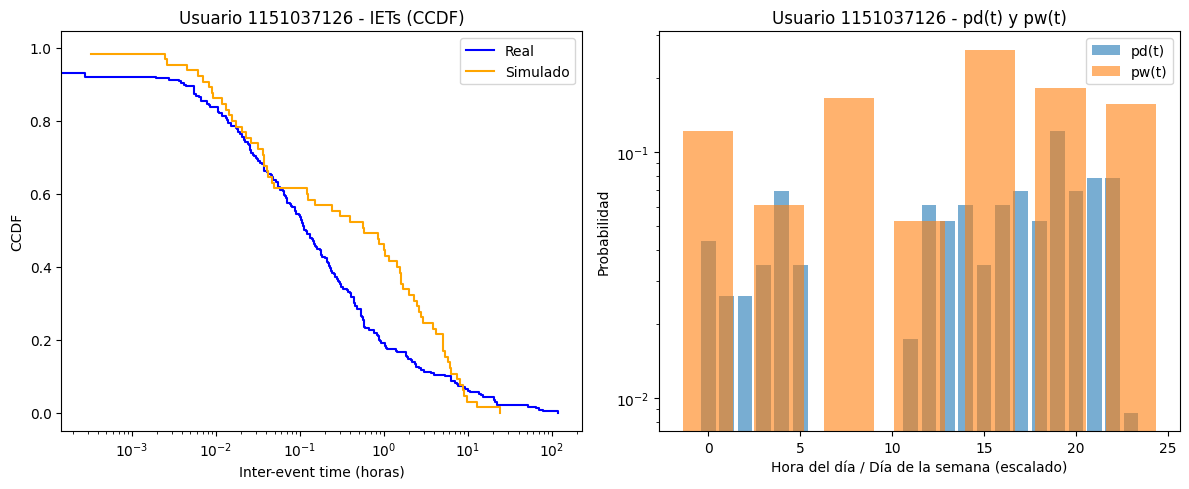

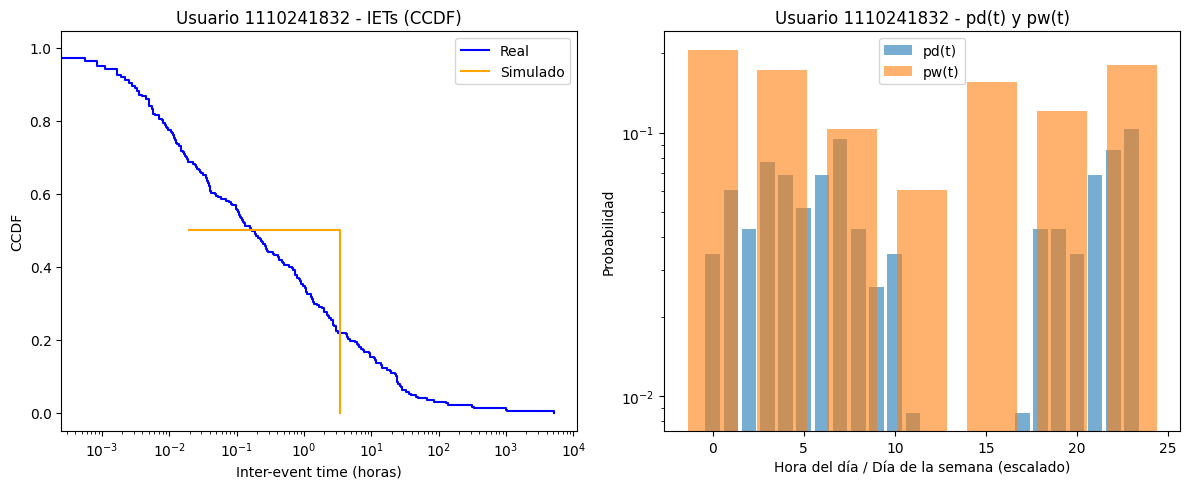

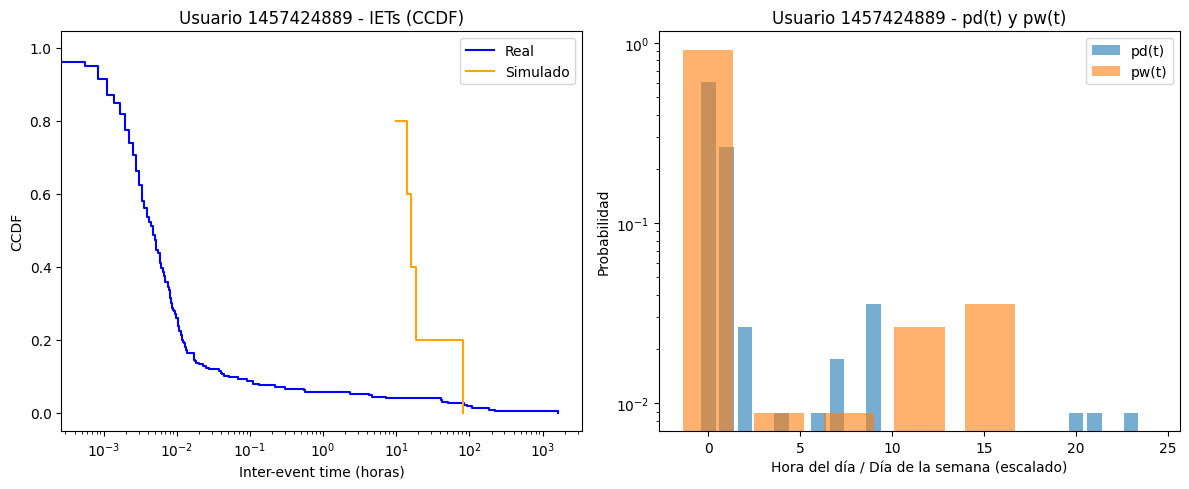

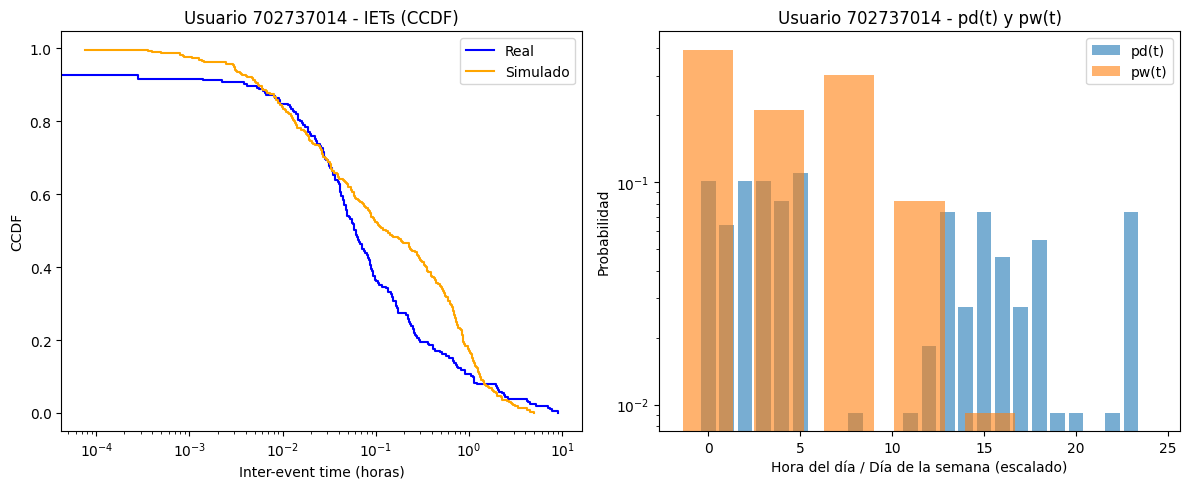

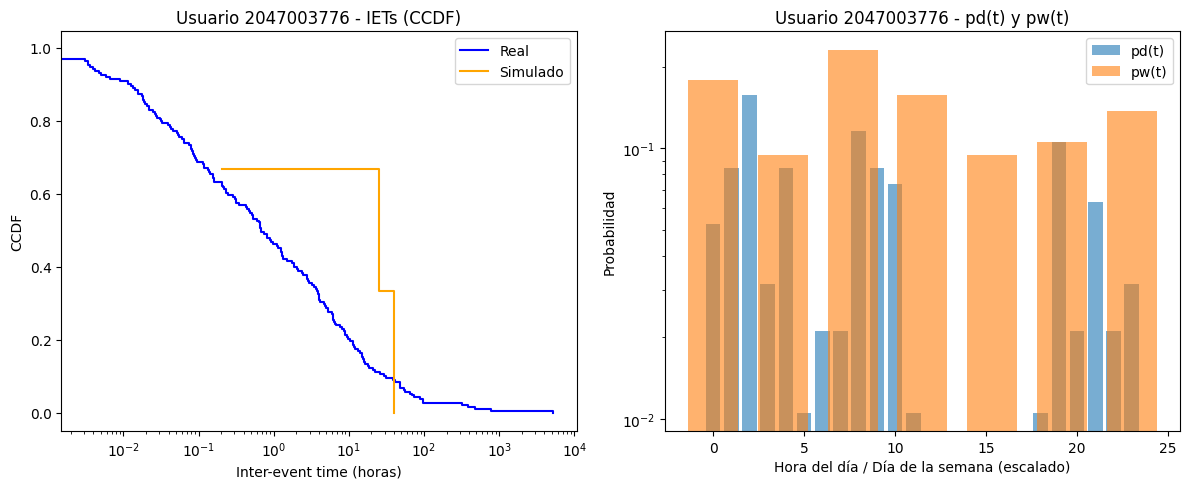

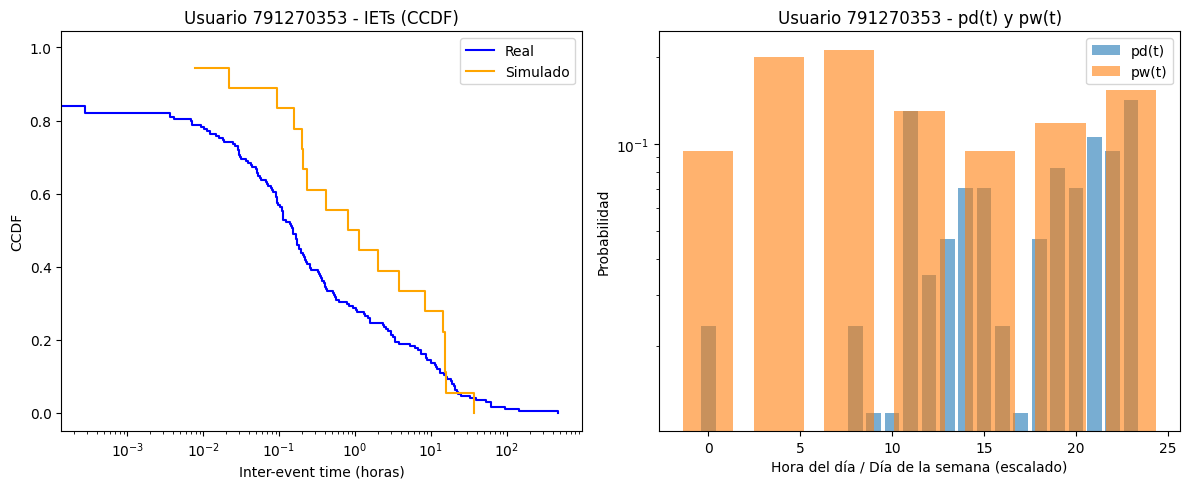

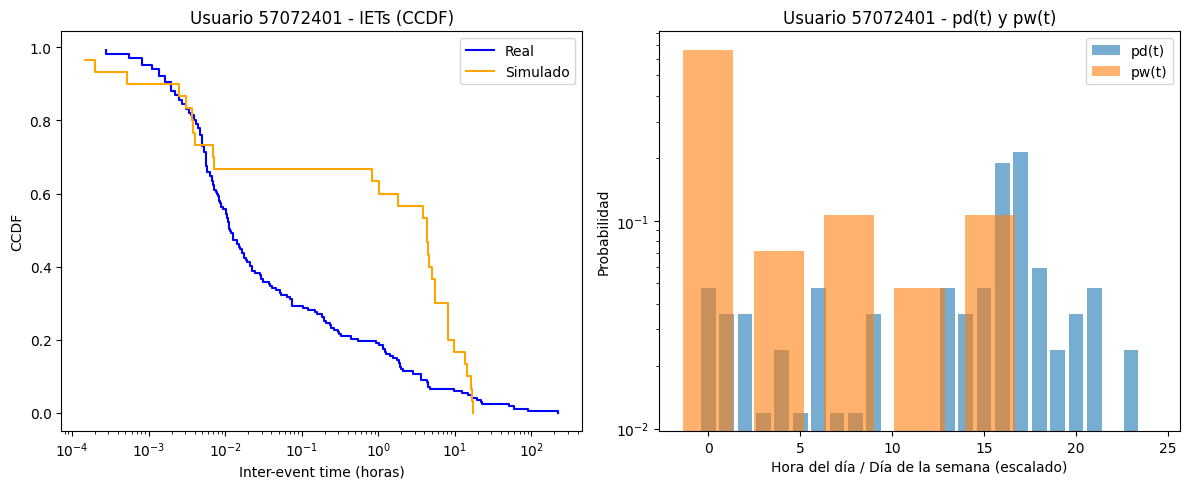

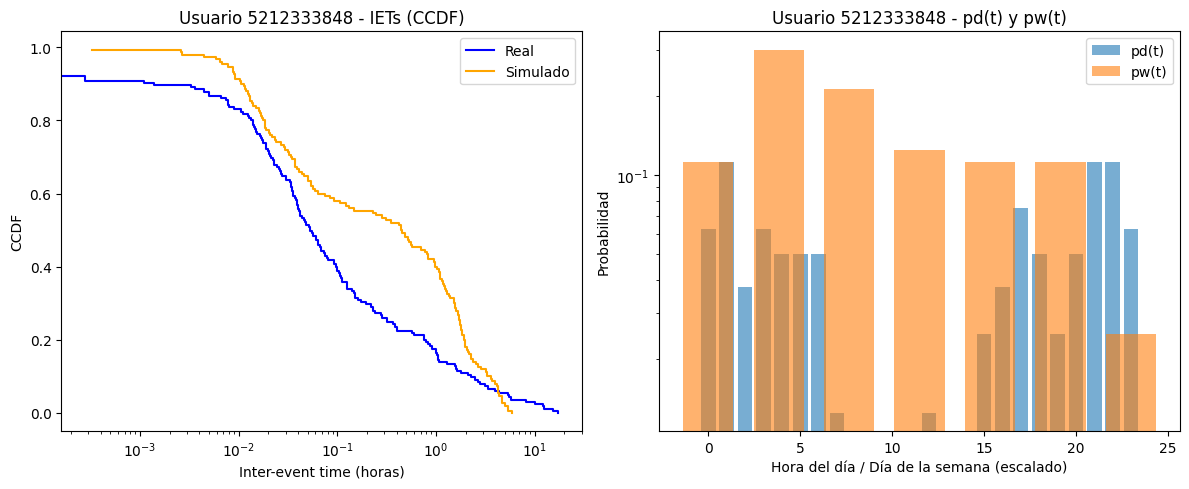

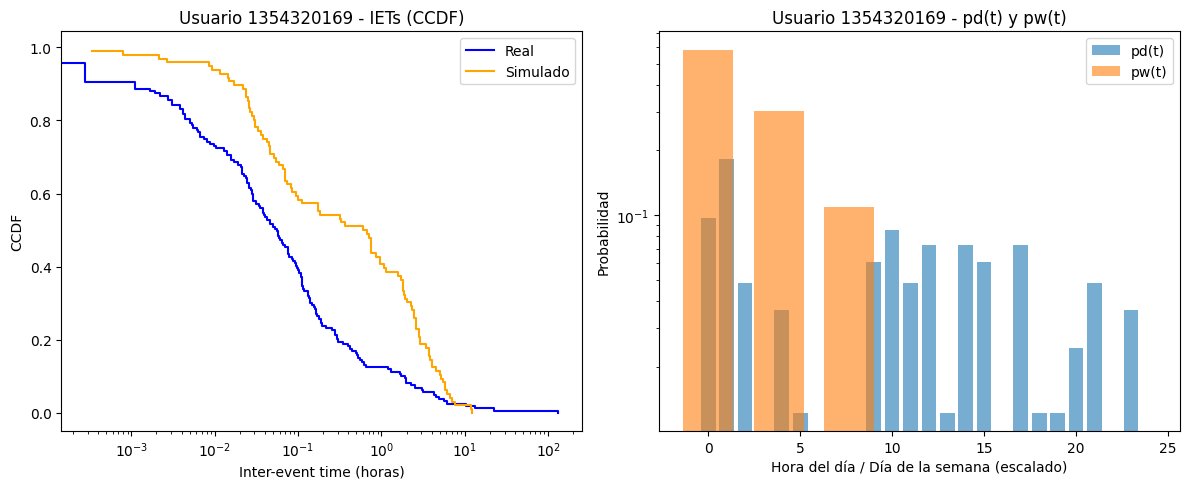

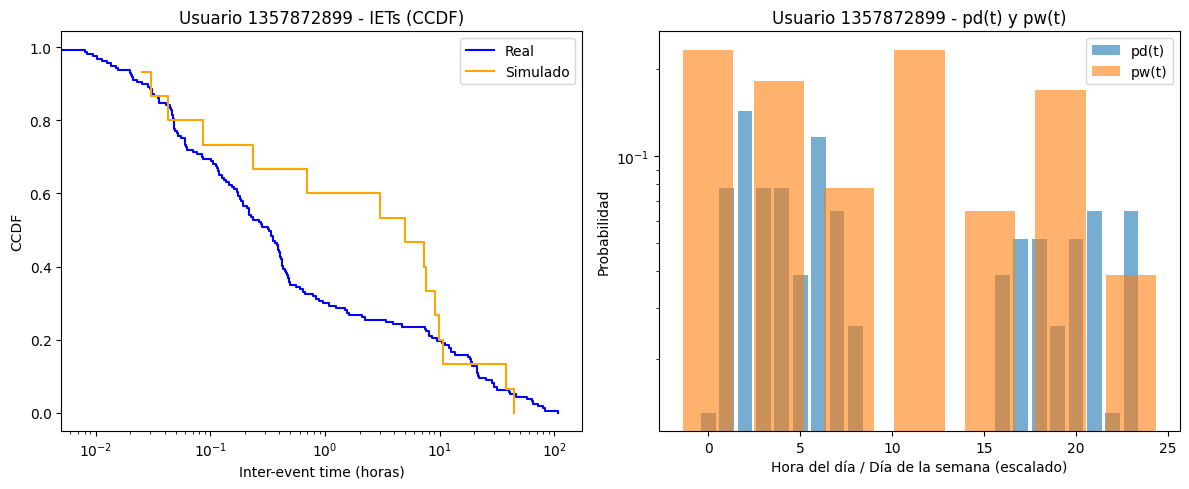

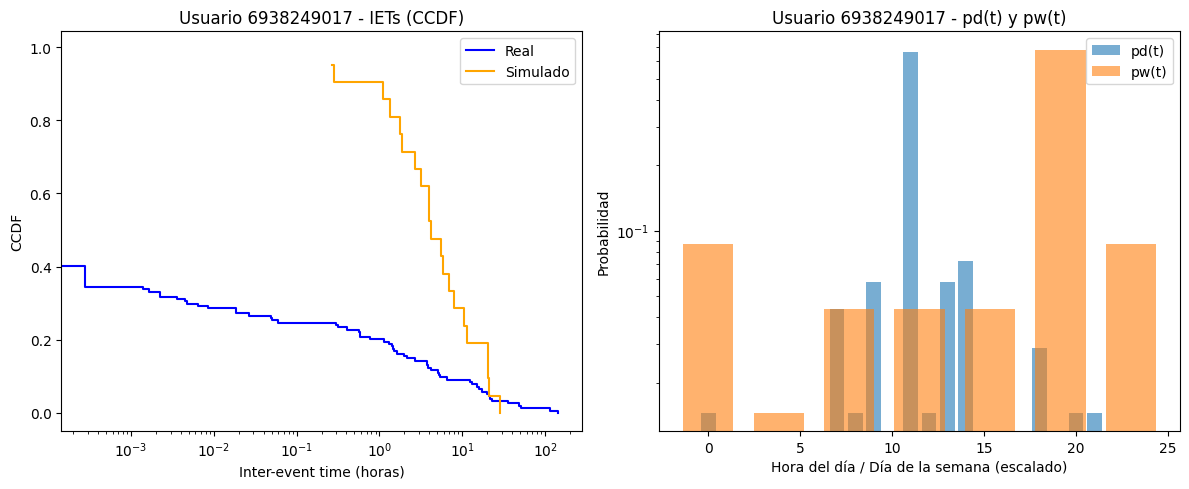

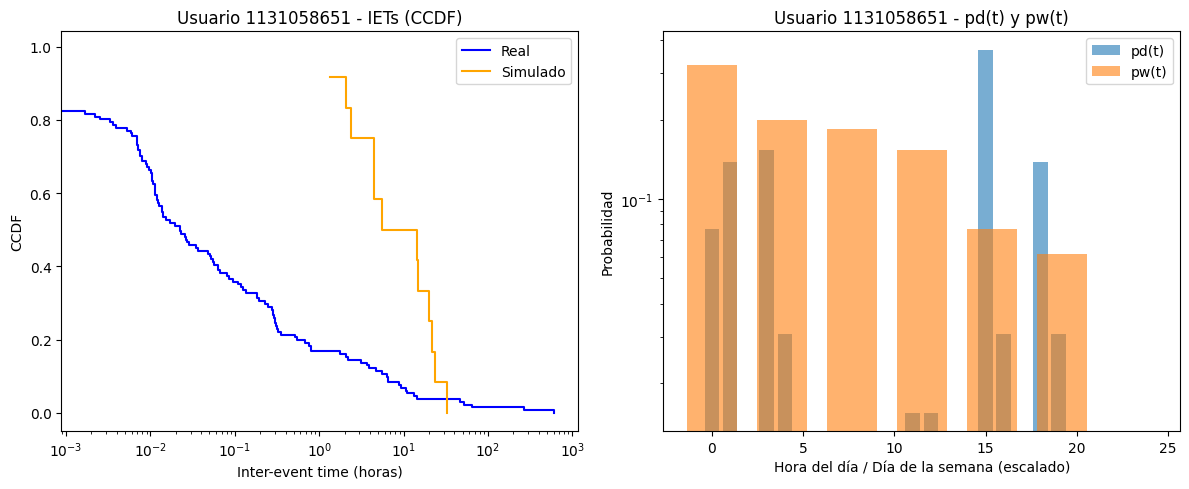

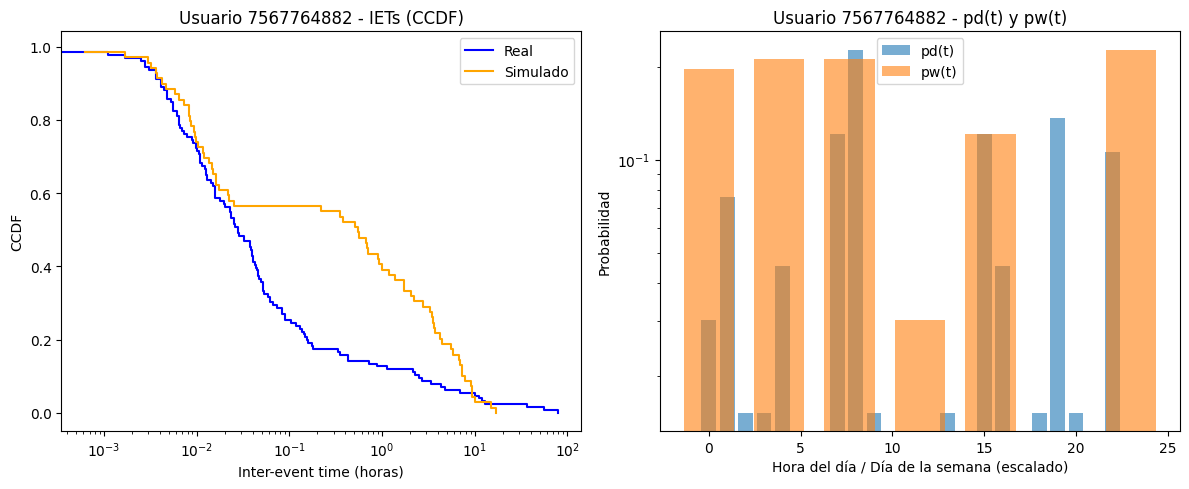

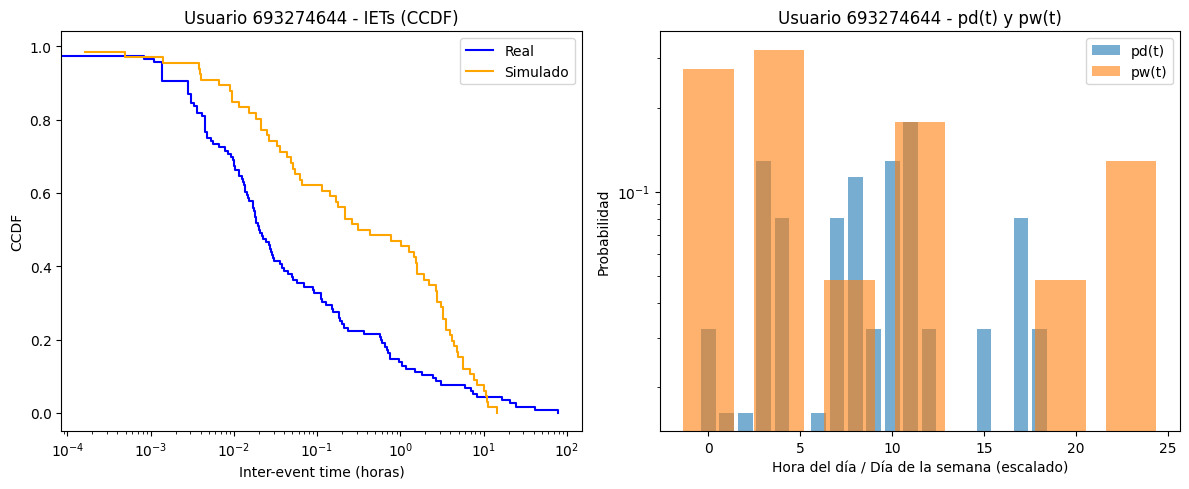

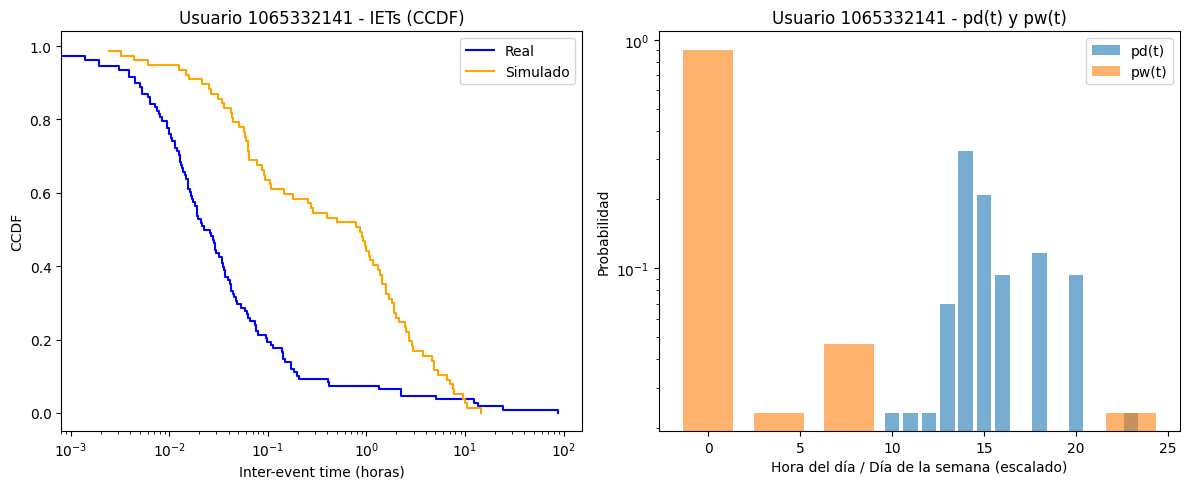

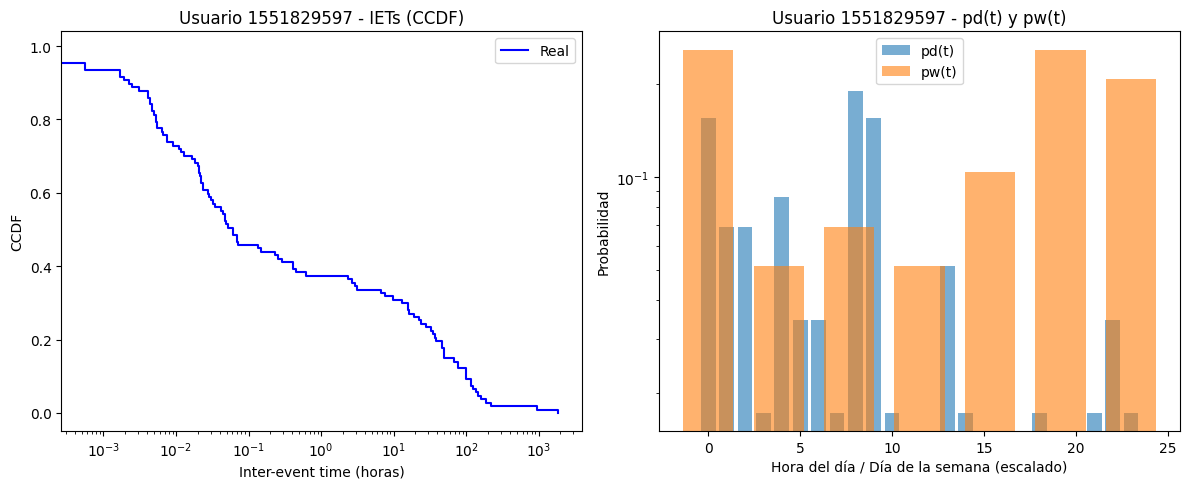

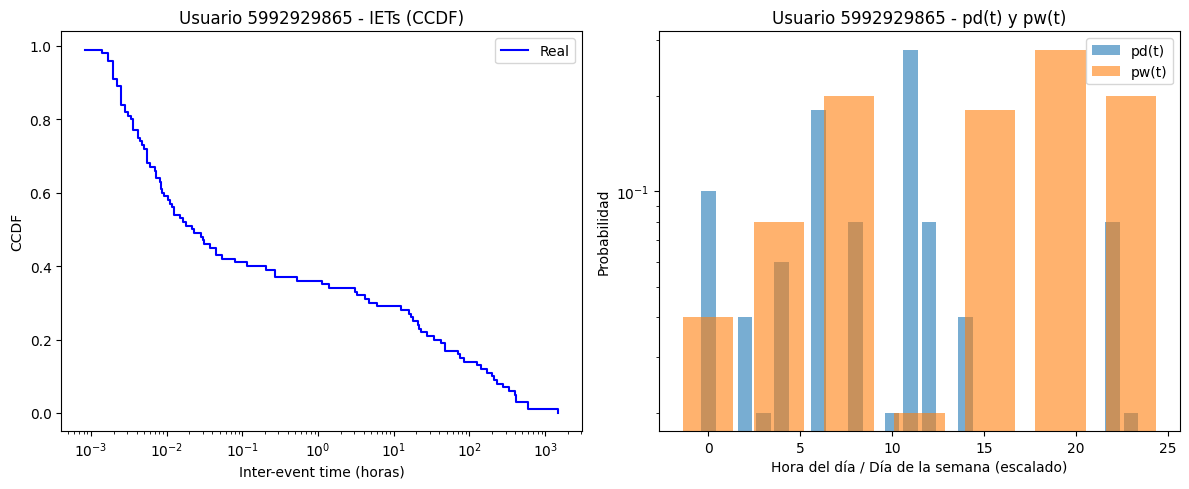

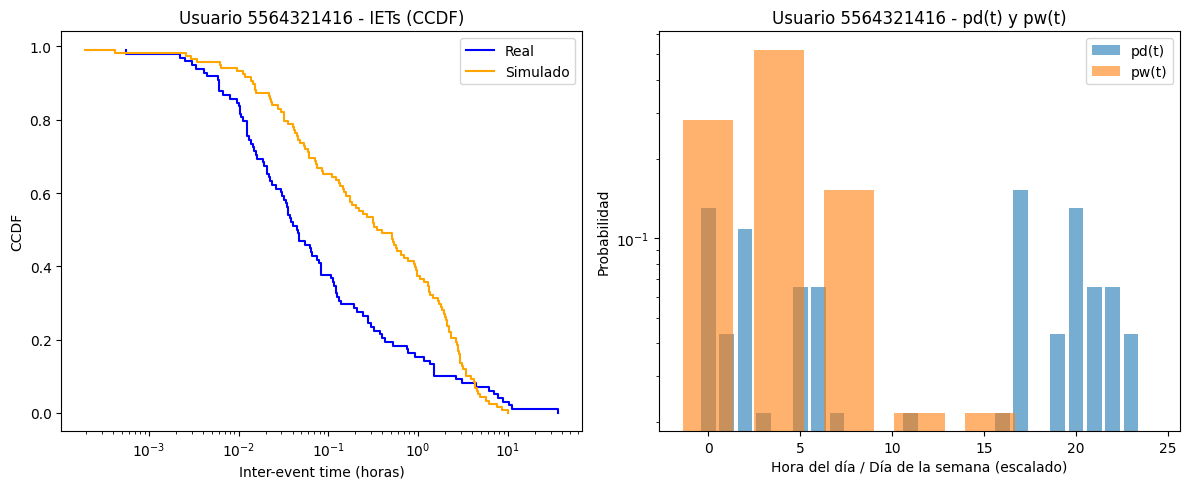

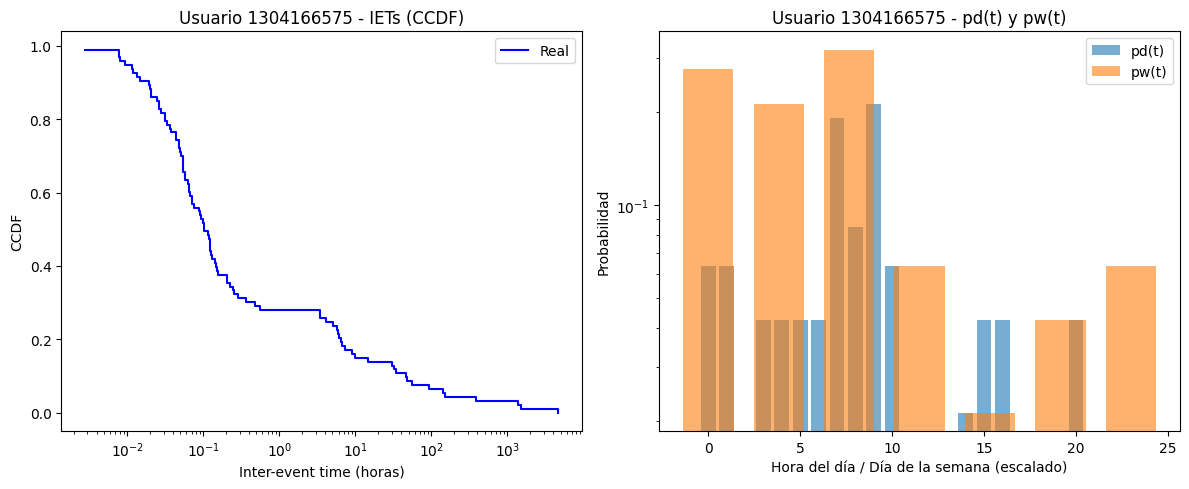

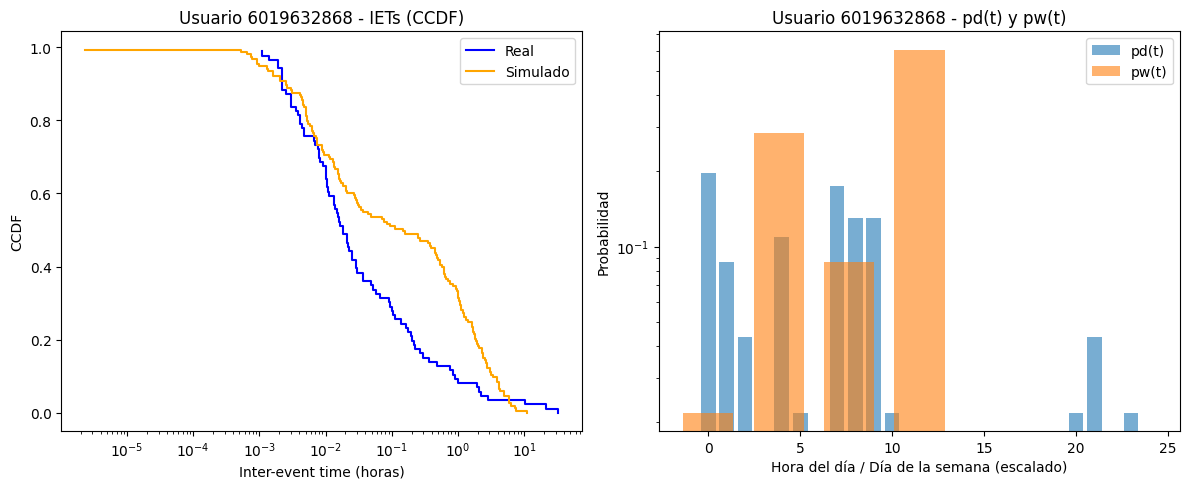

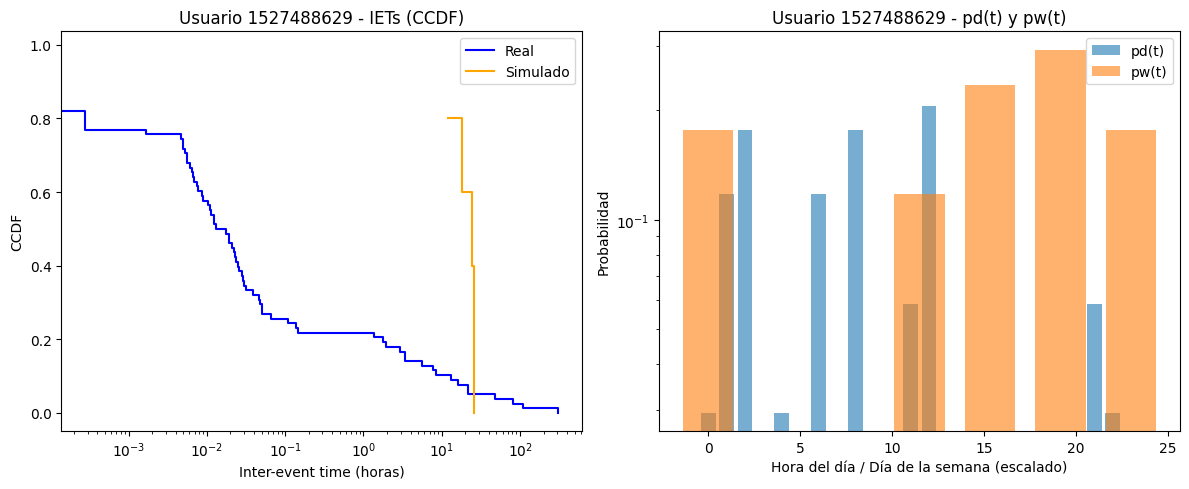

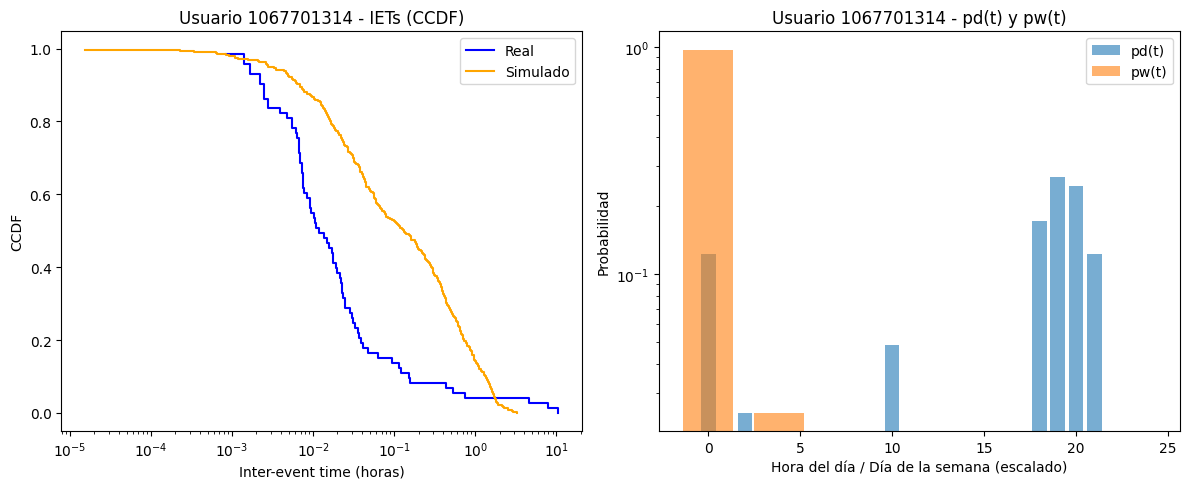

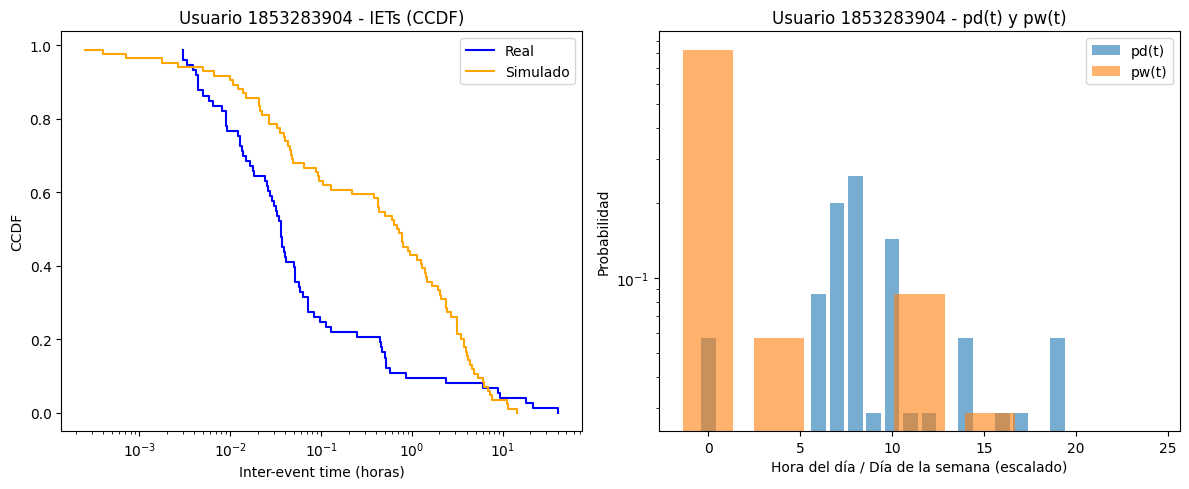

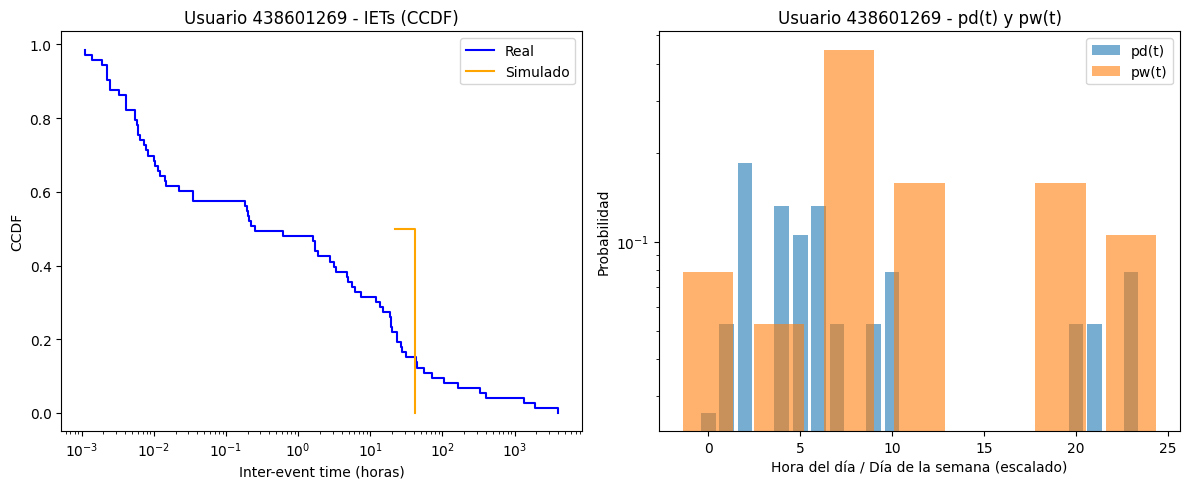

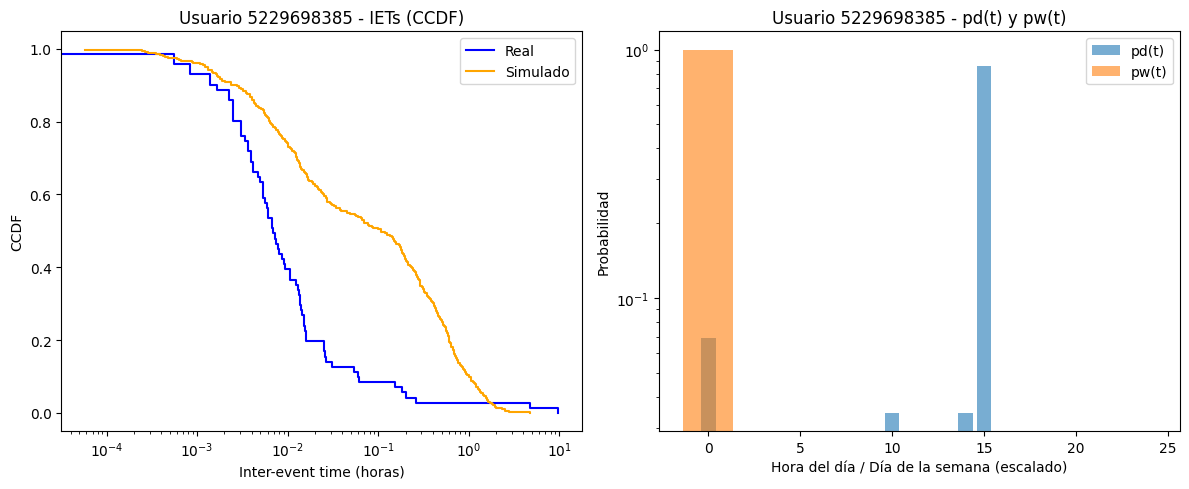

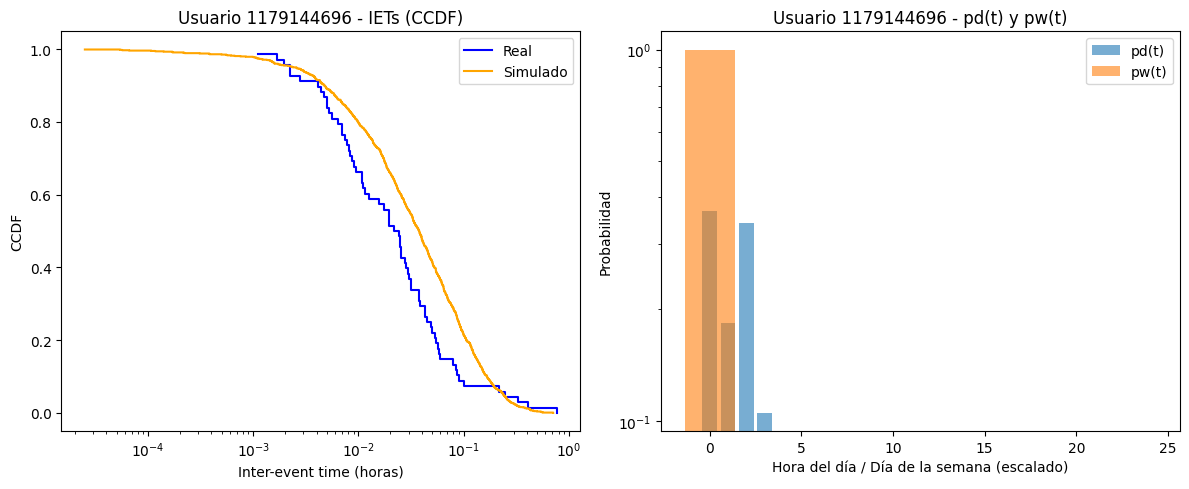

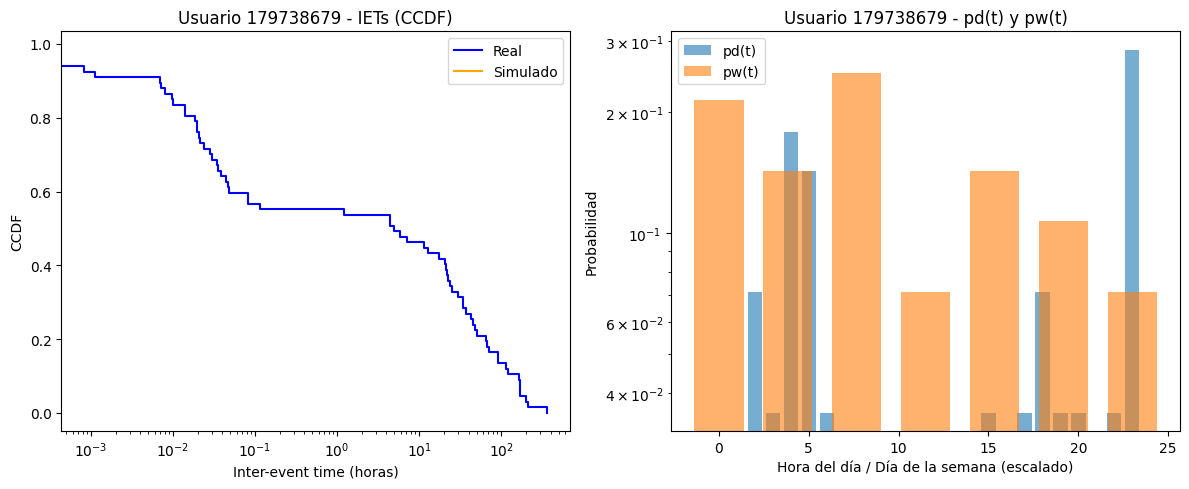

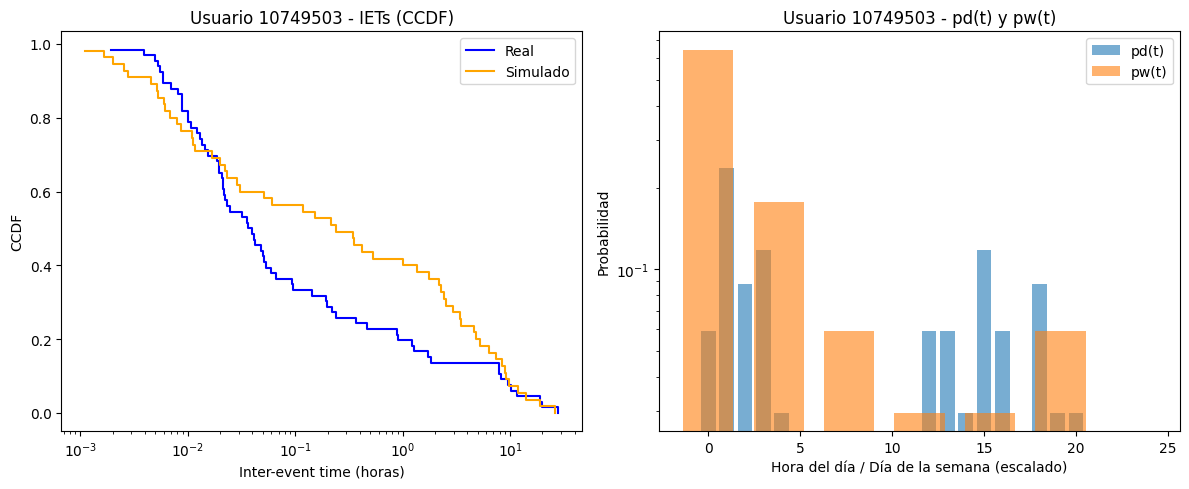

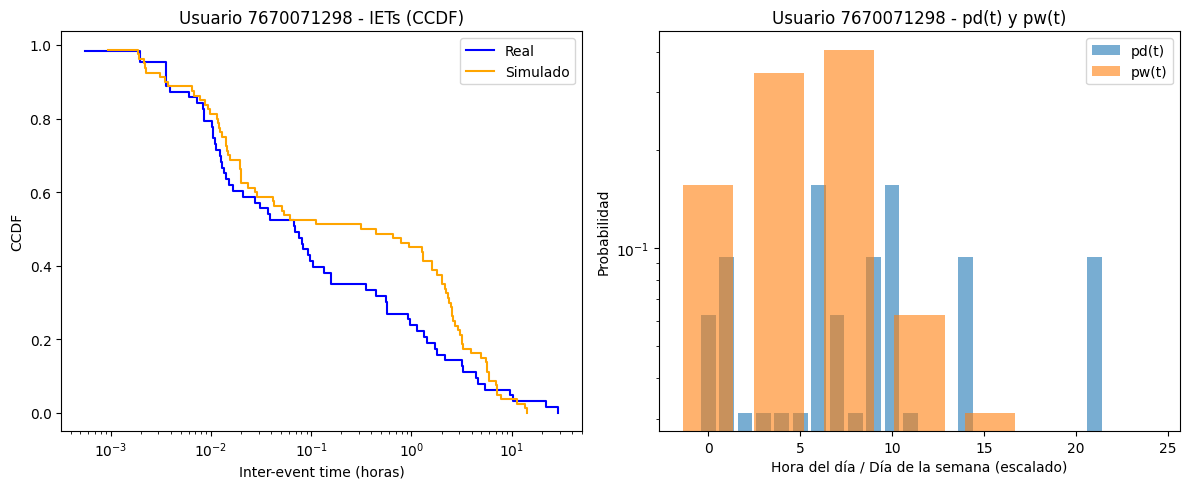

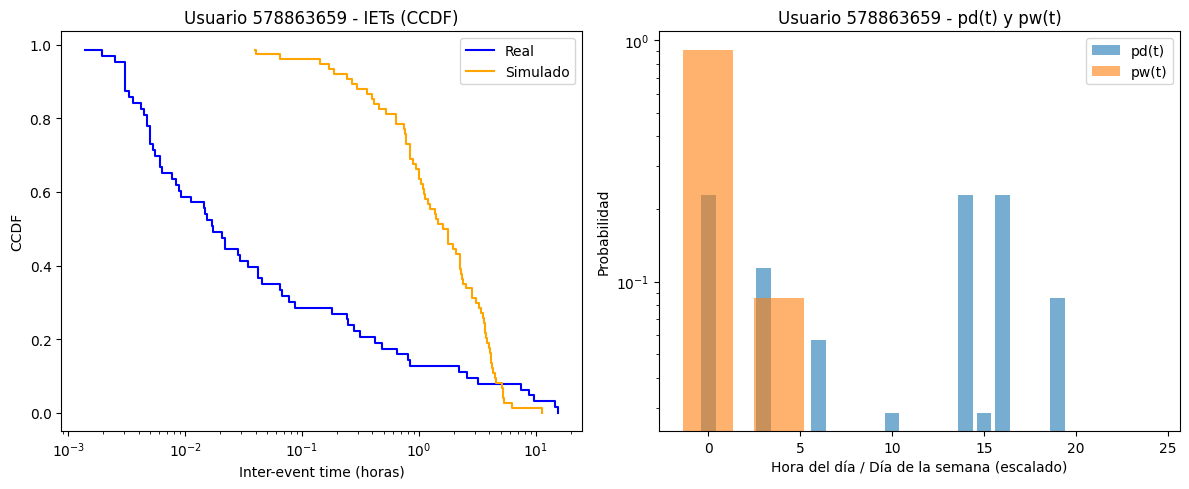

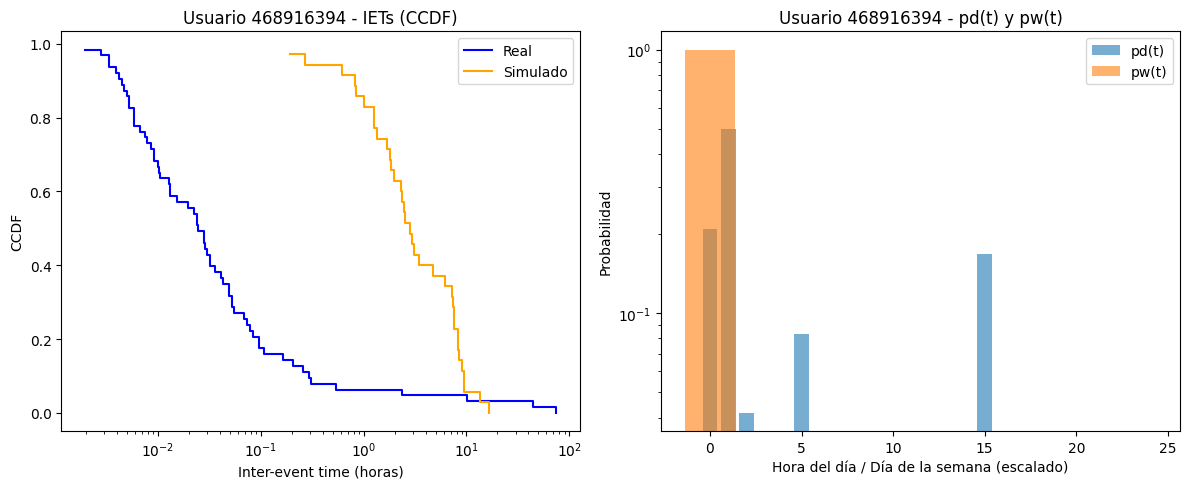

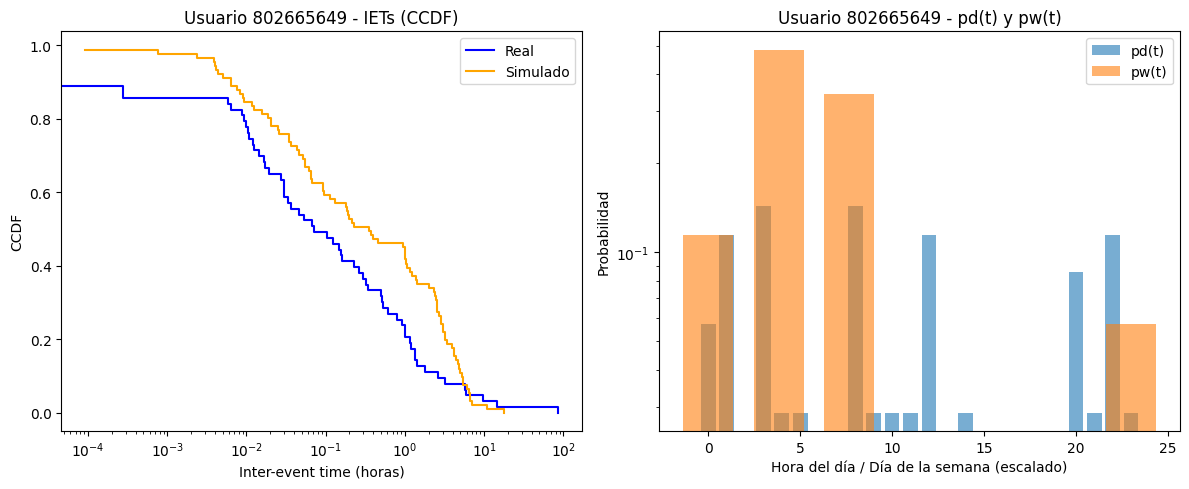

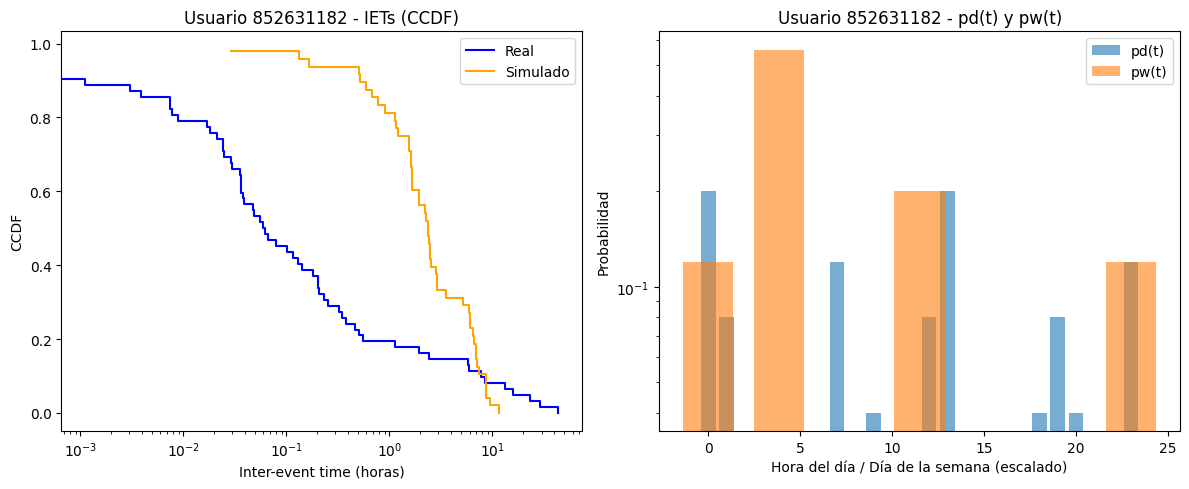

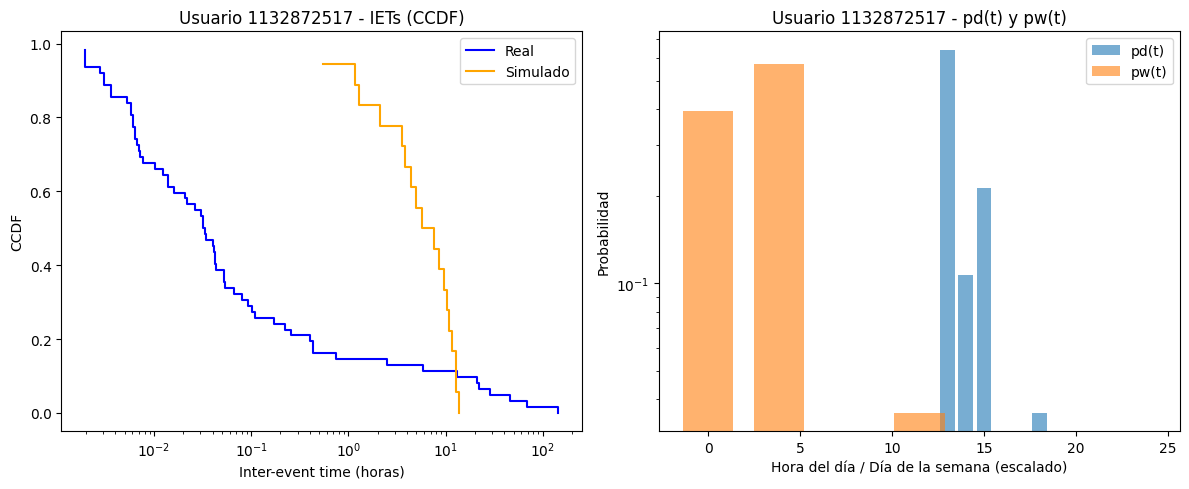

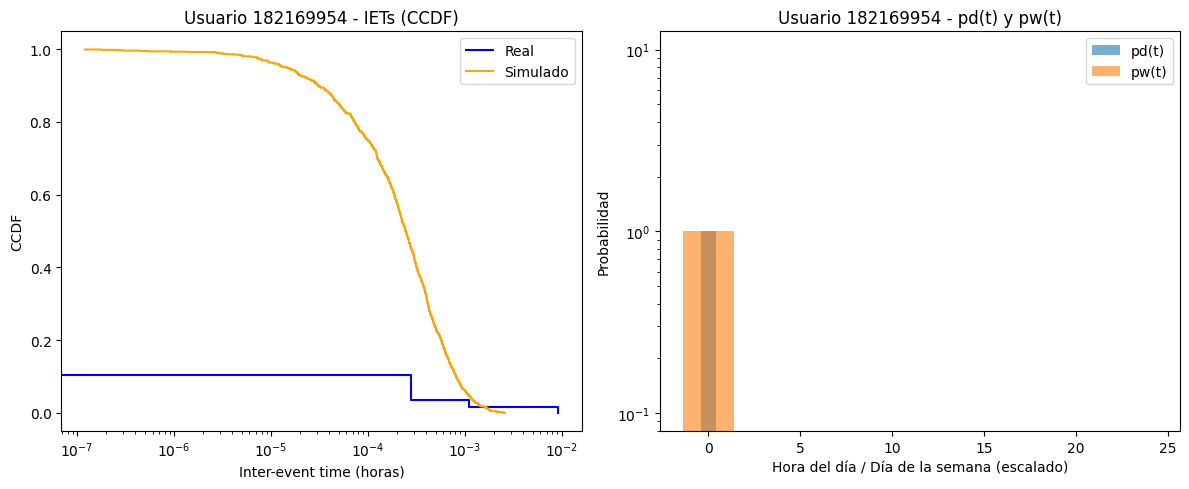

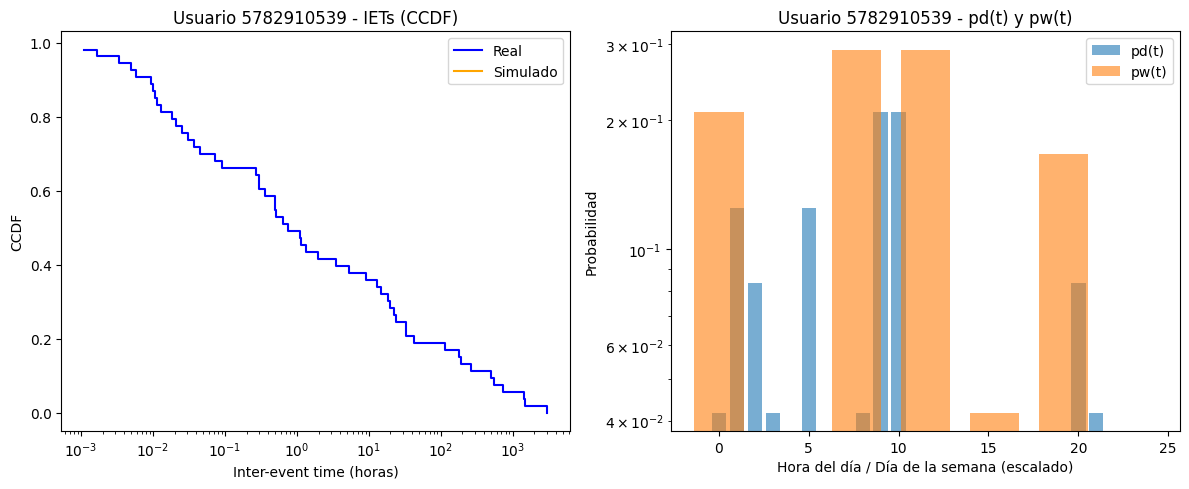

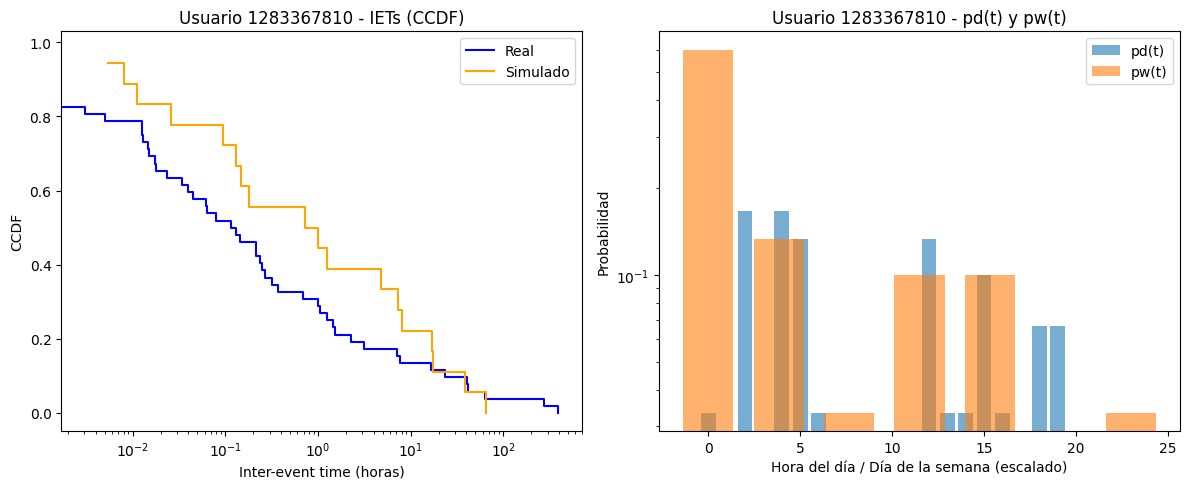

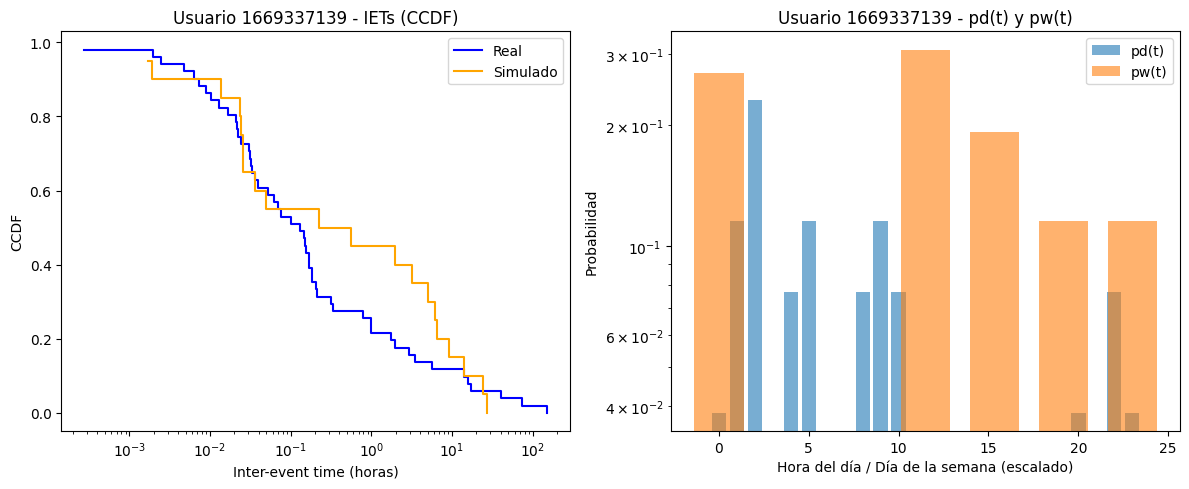

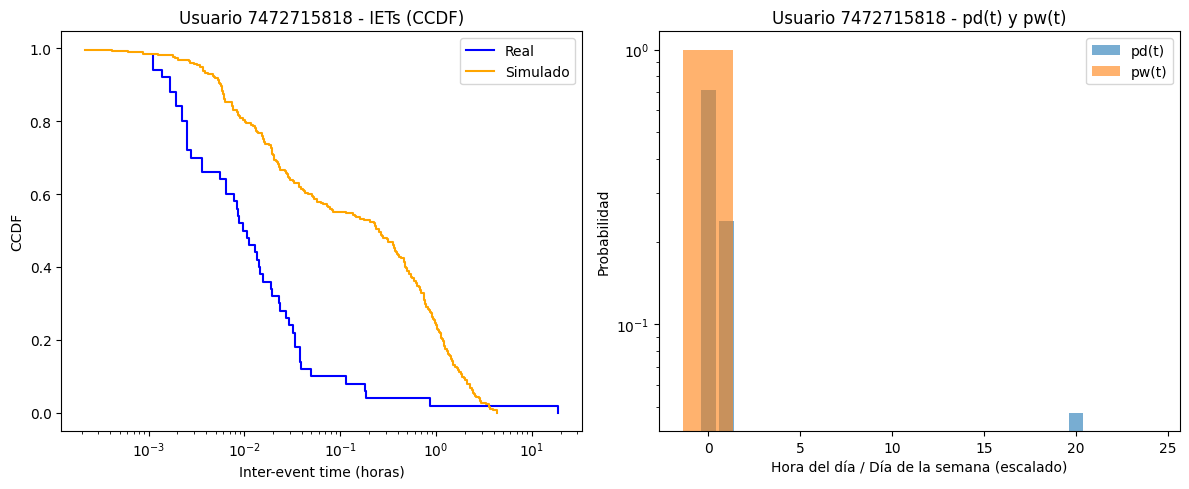

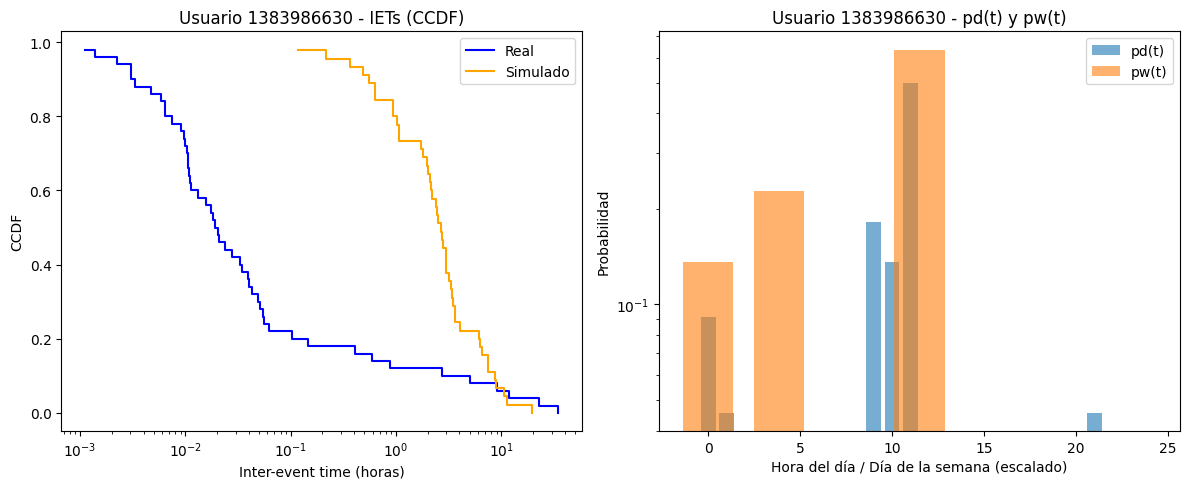

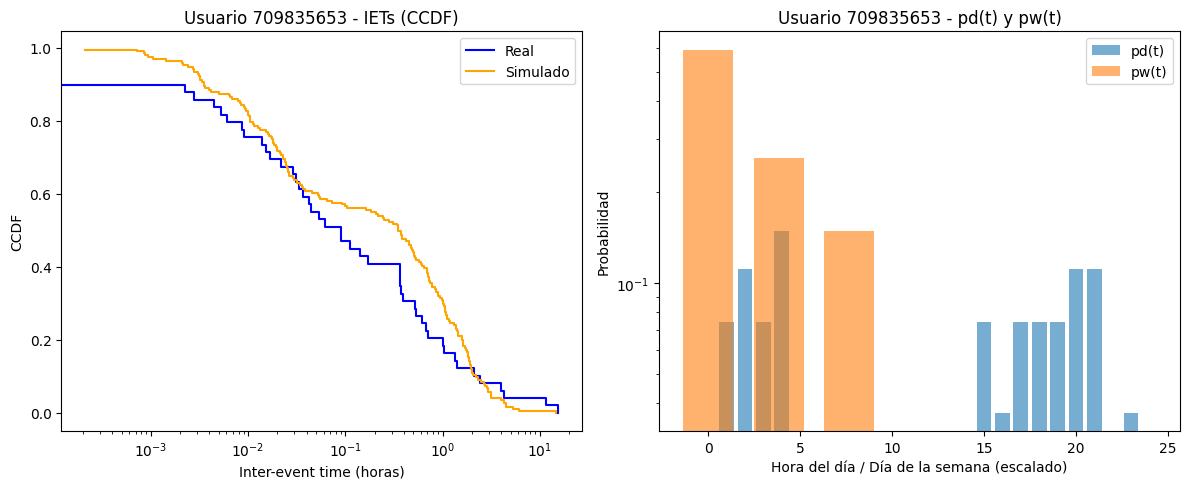

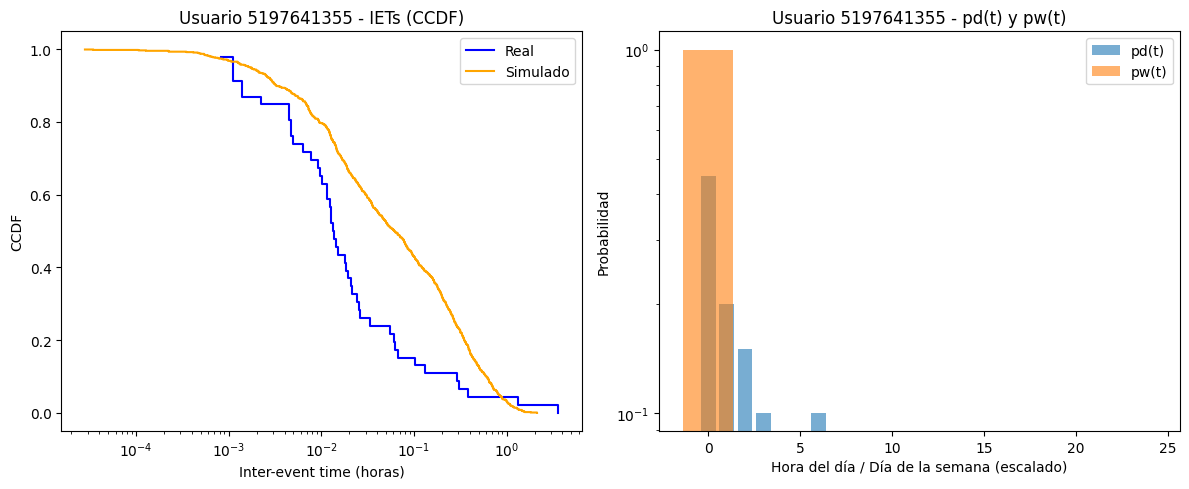

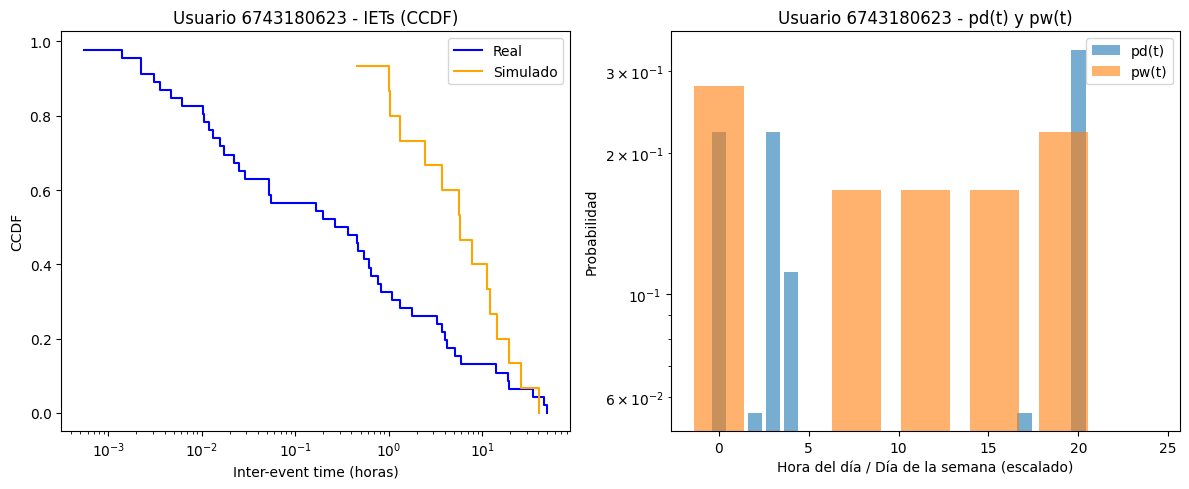

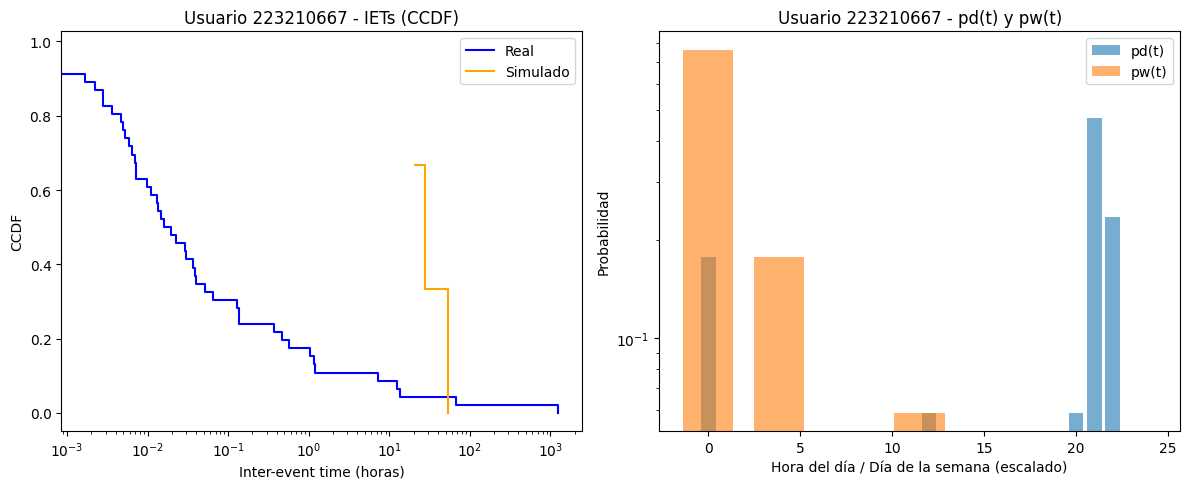

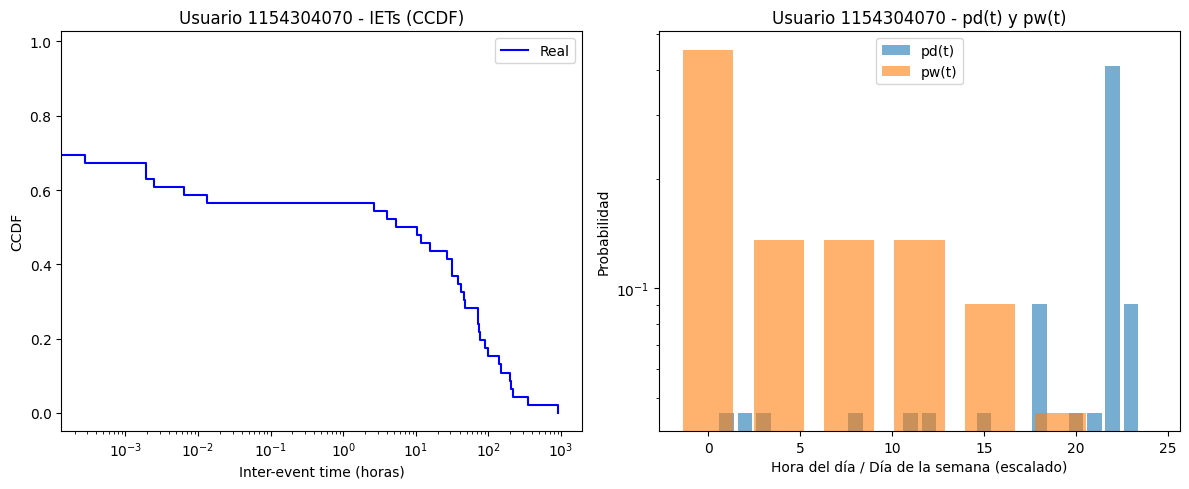

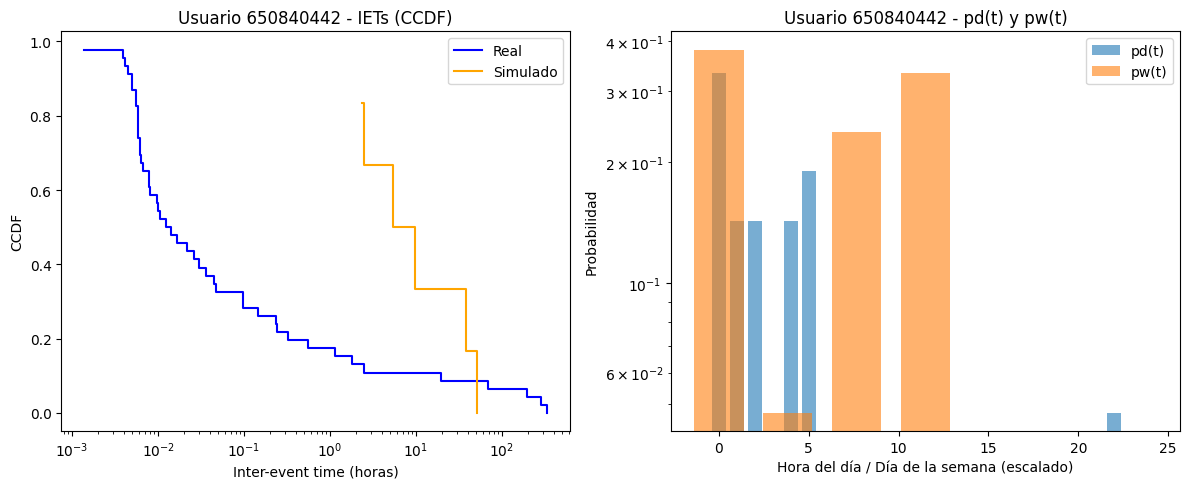

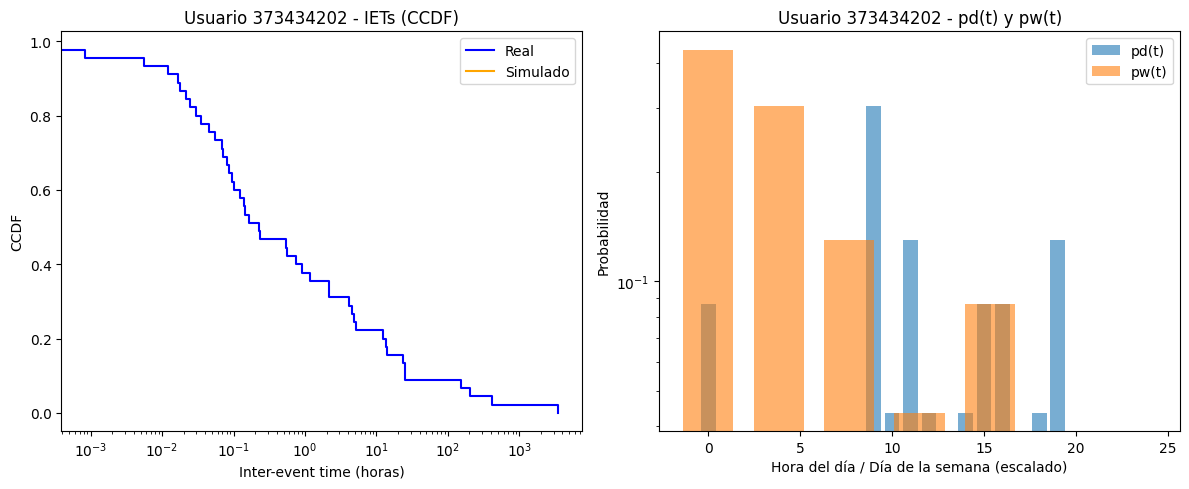

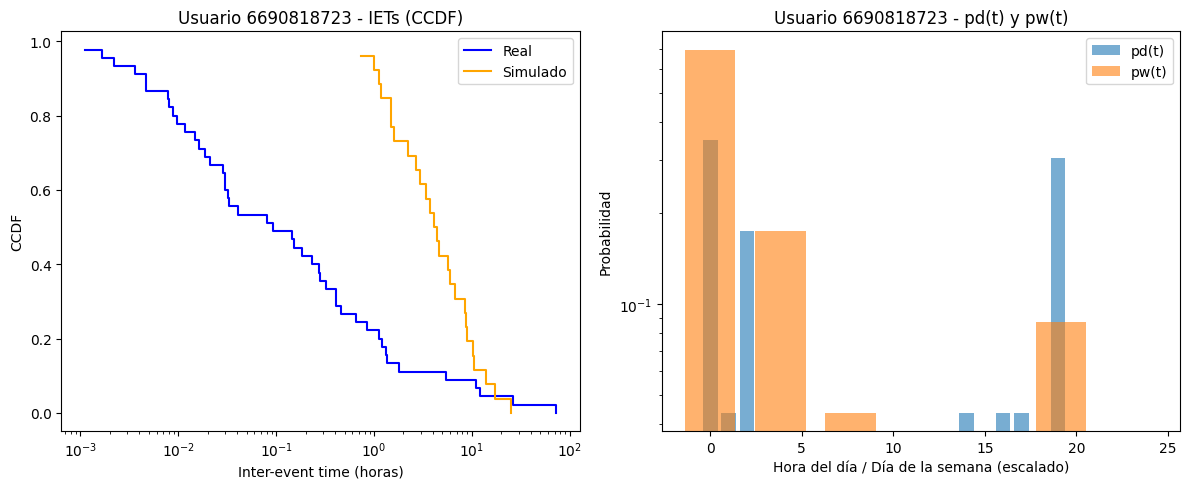

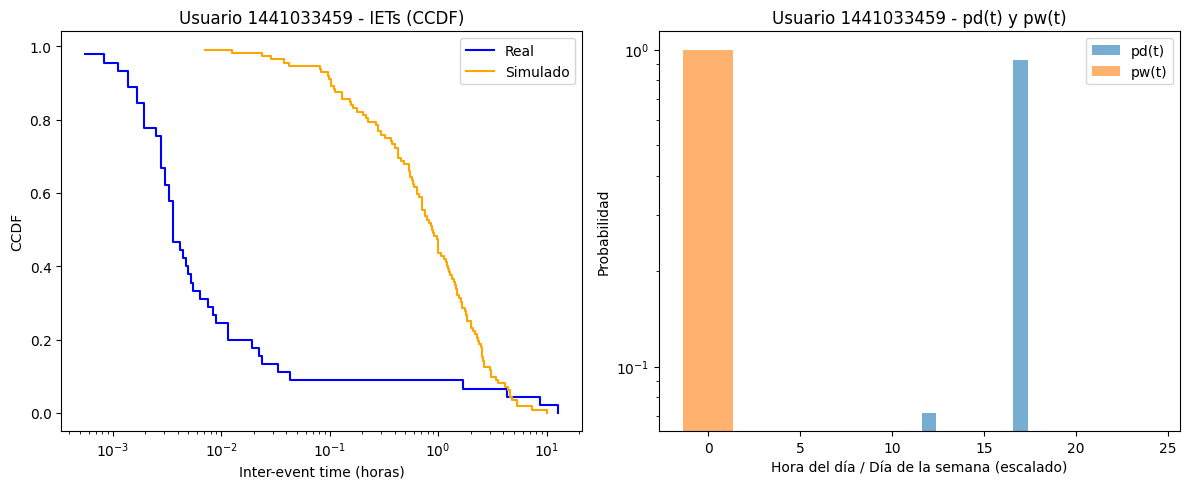

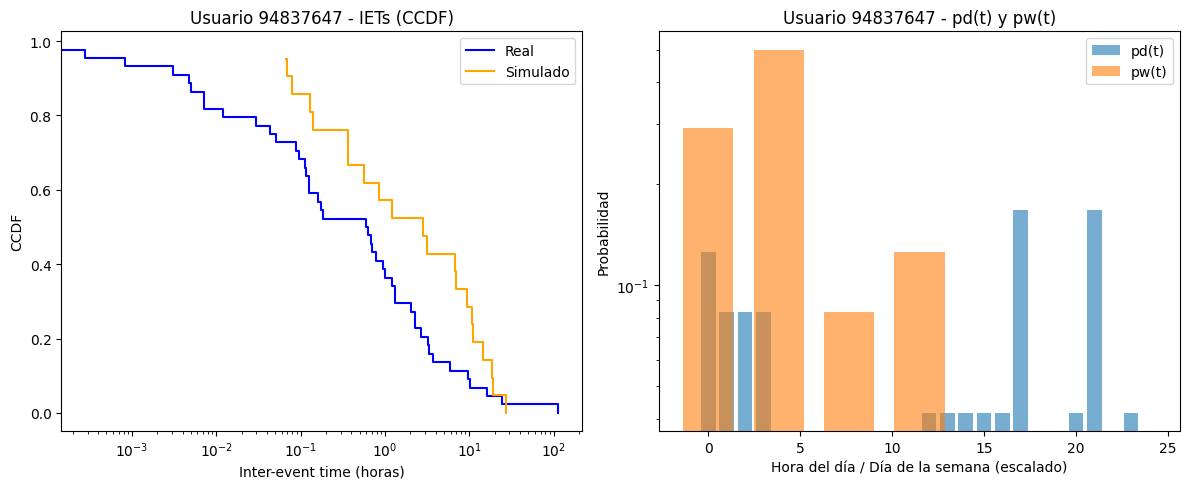

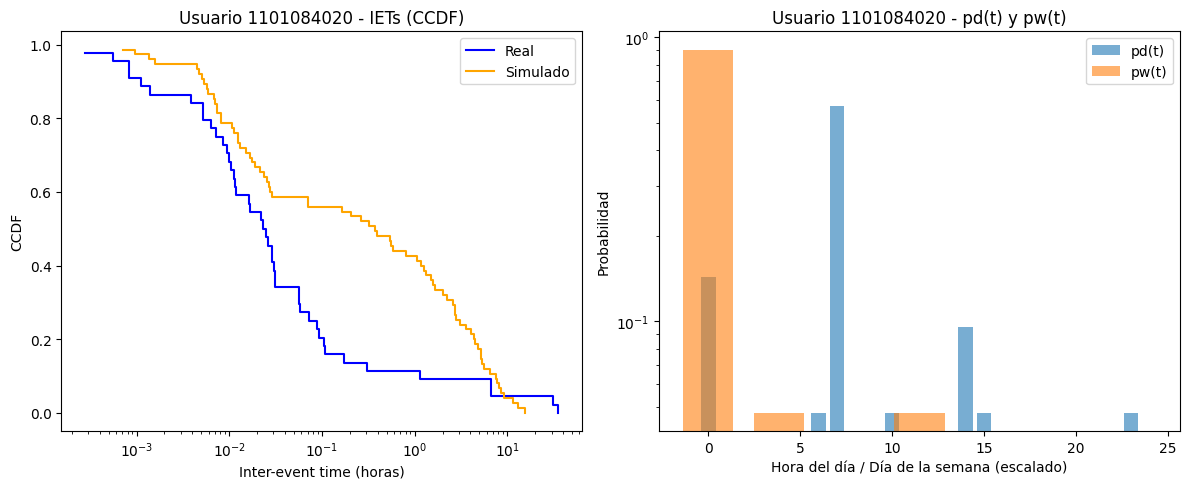

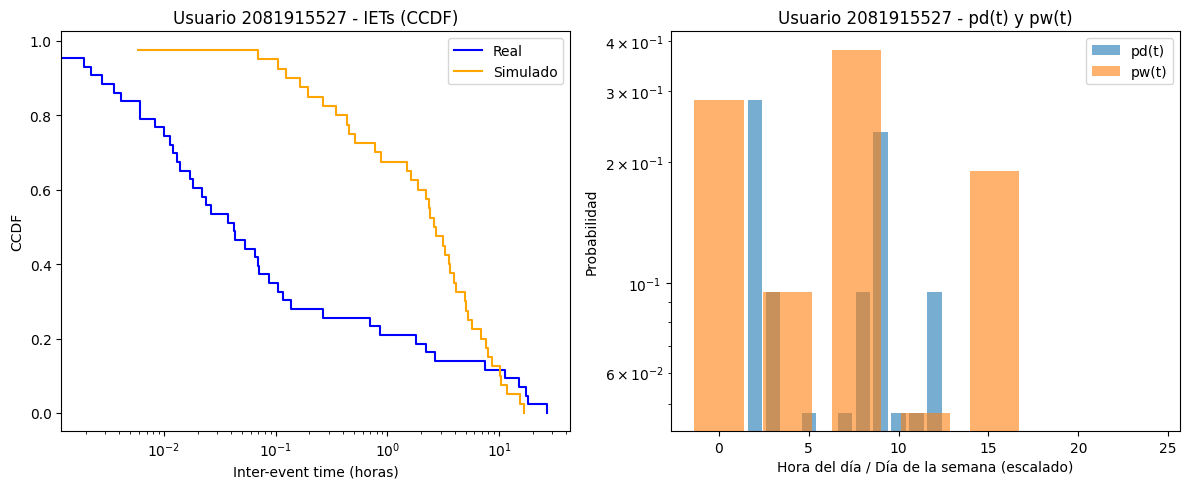

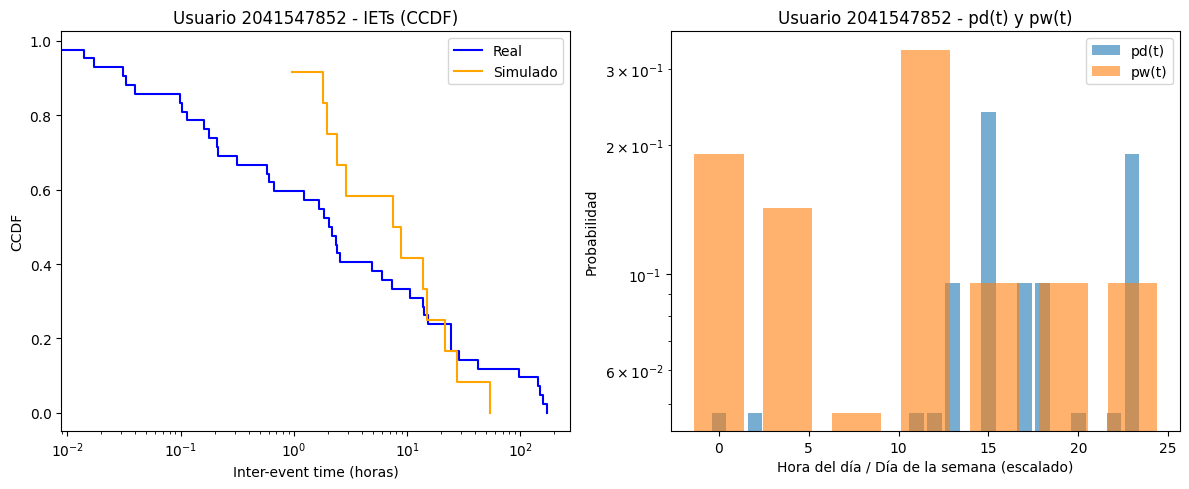

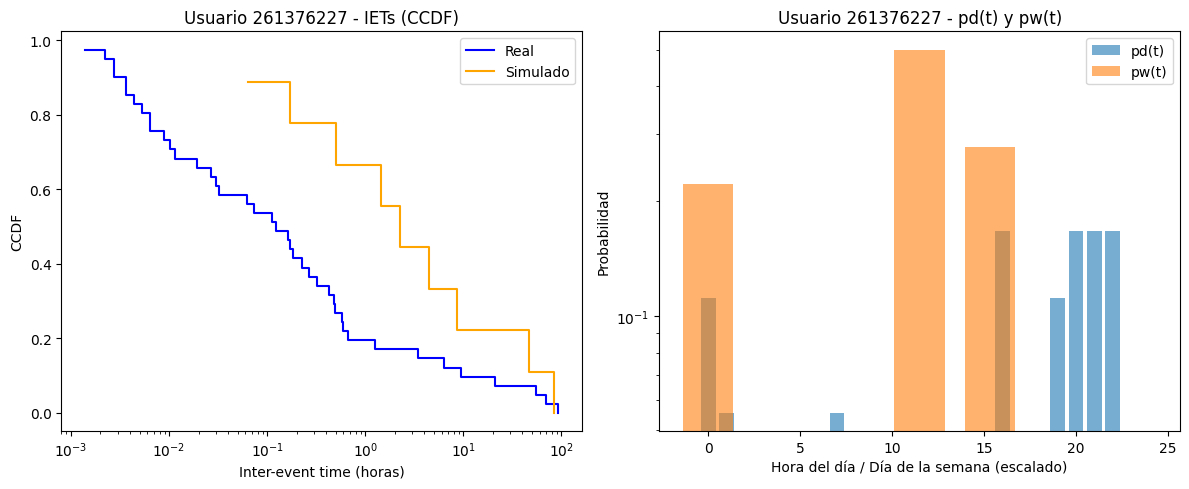

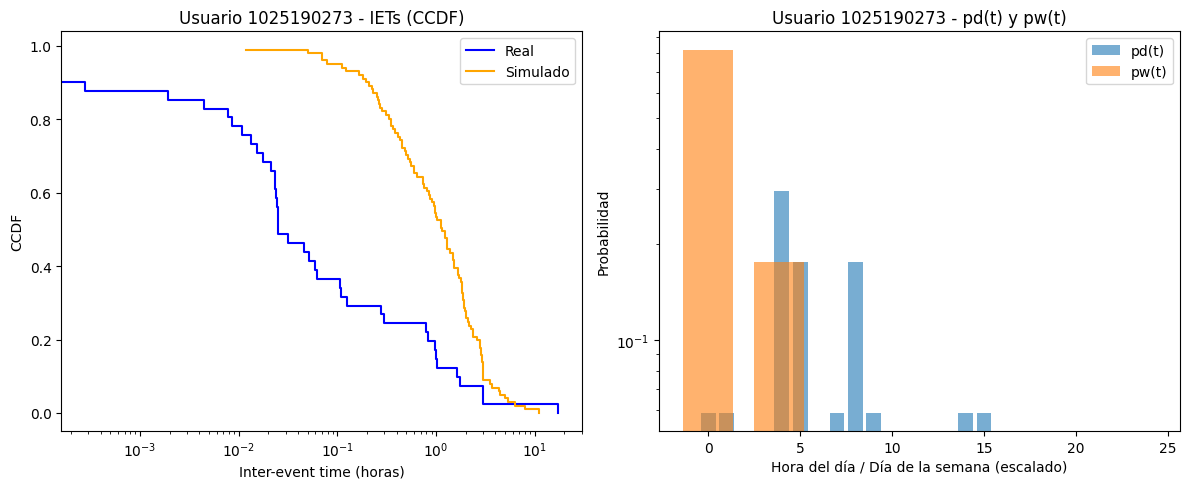

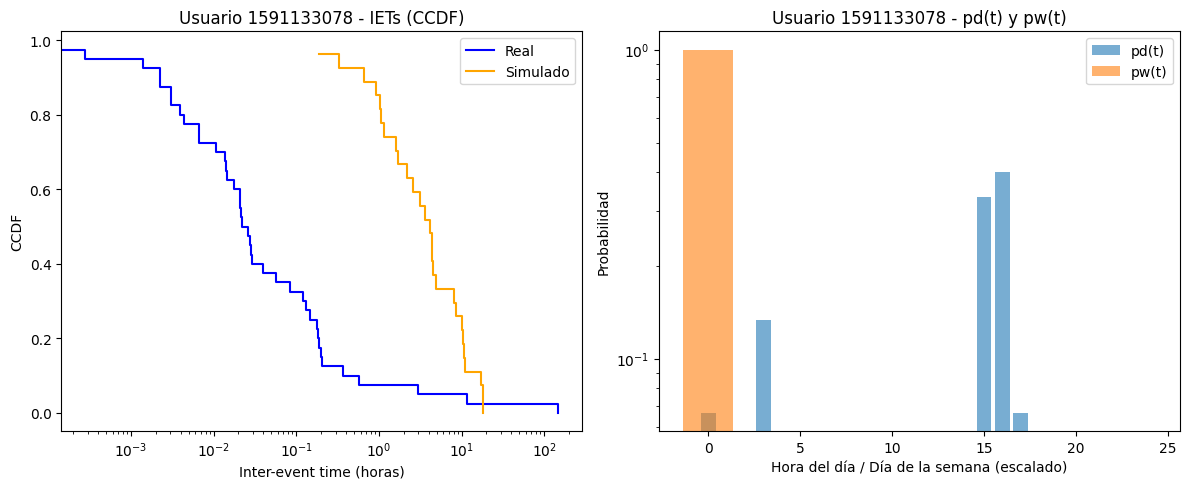

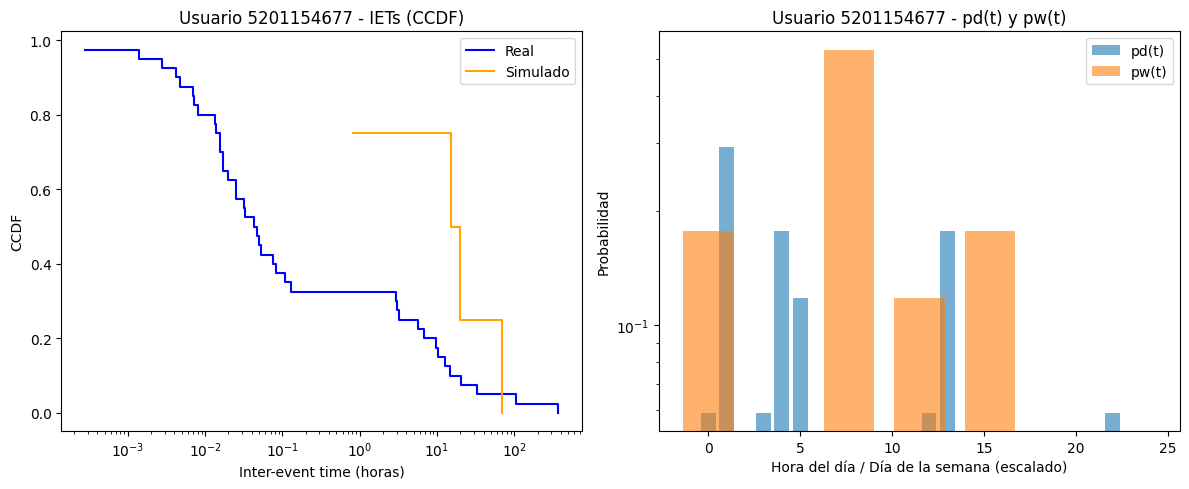

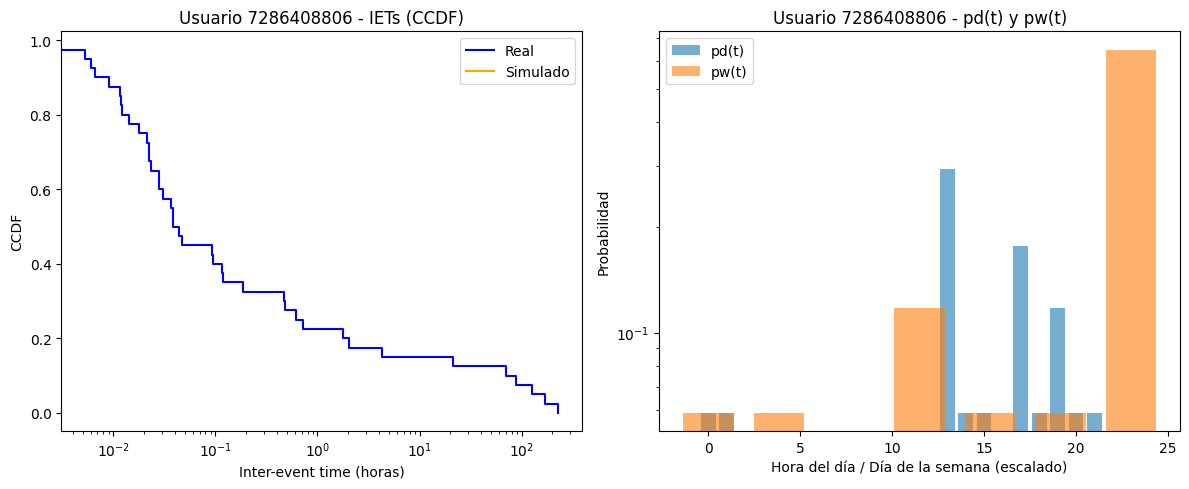

In [53]:
# Comparar IETs reales vs simulados para cada usuario y CCDFs una al lado de la otra
for user_id in active_users:
    user_events = df[df['sender_id'] == user_id]['date'].sort_values()
    if len(user_events) < 2:
        continue
    real_iets = np.diff((user_events - user_events.iloc[0]).dt.total_seconds() / 3600)
    sim_iets = np.diff(simulated_cascades[user_id])
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    # Dibujar CCDF empírica (1 - ECDF) usando step
    def plot_ccdf(data, **kwargs):
        if len(data) == 0:
            return
        x = np.sort(data)
        y = 1.0 - np.arange(1, len(x) + 1) / len(x)
        plt.step(x, y, where='post', **kwargs)
    plot_ccdf(real_iets, label='Real', color='blue')
    plot_ccdf(sim_iets, label='Simulado', color='orange')
    plt.xscale('log')
    plt.xlabel('Inter-event time (horas)')
    plt.ylabel('CCDF')
    plt.title(f'Usuario {user_id} - IETs (CCDF)')
    plt.legend()
    plt.subplot(1, 2, 2)
    # Mostrar pd(t) y pw(t); pw se dibuja sobre 7 posiciones distribuidas en 24h
    plt.bar(range(24), parameters_users[user_id]['pd_t'], alpha=0.6, label='pd(t)')
    pw_x = np.linspace(0, 23, 7)
    plt.bar(pw_x, parameters_users[user_id]['pw_t'], width=24/7*0.8, alpha=0.6, label='pw(t)')
    plt.xlabel('Hora del día / Día de la semana (escalado)')
    plt.ylabel('Probabilidad')
    plt.yscale('log')
    plt.title(f'Usuario {user_id} - pd(t) y pw(t)')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Montecarlo Testing

In [54]:
def monte_carlo_pvalue(empirical_iet, model_params, M=100):
    """
    Calcula el p-valor comparando A_empirico con distribución de A_sintéticos
    """
    rho_a, Nw, pd_t, pw_t, p_Na, total_hours = model_params
    N = len(empirical_iet) + 1
    
    A_empirical = area_test_statistic(
        empirical_iet,
        np.diff(simulate_cascading_nhpp(rho_a, Nw, pd_t, pw_t, 
                                        p_Na, total_hours, N))
    )
    
    A_synthetic = []
    for _ in range(M):
        syn_events = simulate_cascading_nhpp(
            rho_a, Nw, pd_t, pw_t, p_Na, total_hours, N
        )
        if len(syn_events) > 1:
            syn_iets = np.diff(syn_events)
            # Re-fitear el modelo a los datos sintéticos
            A_s = area_test_statistic(syn_iets, syn_iets)  # simplificado
            A_synthetic.append(A_s)
    
    A_synthetic = np.array(A_synthetic)
    A_mean = np.mean(A_synthetic)
    
    # P-valor de dos colas
    p_value = np.mean(
        np.abs(A_synthetic - A_mean) > np.abs(A_empirical - A_mean)
    )
    
    return p_value

In [55]:
# Calcular p-valores para cada usuario
for user_id in active_users:
    if user_id not in parameters_users:
        continue
    
    user_events = df[df['sender_id'] == user_id]['date'].sort_values()
    events_hours = (user_events - user_events.iloc[0]).dt.total_seconds() / 3600
    empirical_iets = np.diff(events_hours.values)
    
    params = parameters_users[user_id]
    model_params = (
        params['rho_a'], params['Nw'], params['pd_t'], 
        params['pw_t'], np.array([0.5, 0.3, 0.2]),  # p_Na ejemplo
        events_hours.iloc[-1] - events_hours.iloc[0]  # total_hours
    )
    
    p_value = monte_carlo_pvalue(empirical_iets, model_params, M=100)
    print(f"Usuario {user_id} - P-valor del test de Monte Carlo: {p_value:.4f}")


Usuario 1762777403 - P-valor del test de Monte Carlo: 0.0000
Usuario 7094531229 - P-valor del test de Monte Carlo: 0.0000
Usuario 1505404600 - P-valor del test de Monte Carlo: 0.0000
Usuario 271855505 - P-valor del test de Monte Carlo: 0.0000
Usuario 6973904485 - P-valor del test de Monte Carlo: 0.0000
Usuario 6601816159 - P-valor del test de Monte Carlo: 0.0000
Usuario 6221273187 - P-valor del test de Monte Carlo: 0.0000
Usuario 1095473116 - P-valor del test de Monte Carlo: 0.0000
Usuario 5689570195 - P-valor del test de Monte Carlo: 0.0000
Usuario 1151037126 - P-valor del test de Monte Carlo: 0.0000
Usuario 1110241832 - P-valor del test de Monte Carlo: 0.0000
Usuario 1457424889 - P-valor del test de Monte Carlo: 0.0000
Usuario 702737014 - P-valor del test de Monte Carlo: 0.0000
Usuario 2047003776 - P-valor del test de Monte Carlo: 0.0000
Usuario 791270353 - P-valor del test de Monte Carlo: 0.0000
Usuario 57072401 - P-valor del test de Monte Carlo: 0.0000
Usuario 5212333848 - P-valor 

### Representación gráfica

In [56]:
def plot_log_residuals(empirical_iet, model_iet, title=''):
    """
    R = ln(p_model(τ) / p_empirical(τ))
    Si el modelo es bueno, R debe ser pequeño y sin estructura sistemática
    """
    log_bins = np.logspace(-2, 3, 50)  # en horas
    
    hist_emp, _ = np.histogram(empirical_iet, bins=log_bins, density=True)
    hist_mod, _ = np.histogram(model_iet, bins=log_bins, density=True)
    
    bin_centers = np.sqrt(log_bins[:-1] * log_bins[1:])
    
    # Evitar log(0)
    mask = (hist_emp > 0) & (hist_mod > 0)
    R = np.log(hist_mod[mask] / hist_emp[mask])
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.loglog(bin_centers[mask], hist_emp[mask], 'o', label='Datos SMS')
    plt.loglog(bin_centers[mask], hist_mod[mask], '-', label='Modelo CNHPP')
    plt.axvline(16, ls='--', color='gray', label='16h')
    plt.axvline(32, ls='--', color='gray', label='32h')
    plt.xlabel('Inter-event time (h)')
    plt.ylabel('PDF')
    plt.legend()
    plt.title(f'CCDF comparison {title}')
    
    plt.subplot(1, 2, 2)
    plt.semilogx(bin_centers[mask], R, 'o-')
    plt.axhline(0, color='k', ls='--')
    plt.axvspan(16, 32, alpha=0.2, color='red', label='Zona de interés')
    plt.xlabel('Inter-event time (h)')
    plt.ylabel('Log-residual R')
    plt.title('Si R≈0 en 16-32h → modelo captura el bump')
    plt.legend()
    plt.tight_layout()
    plt.show()

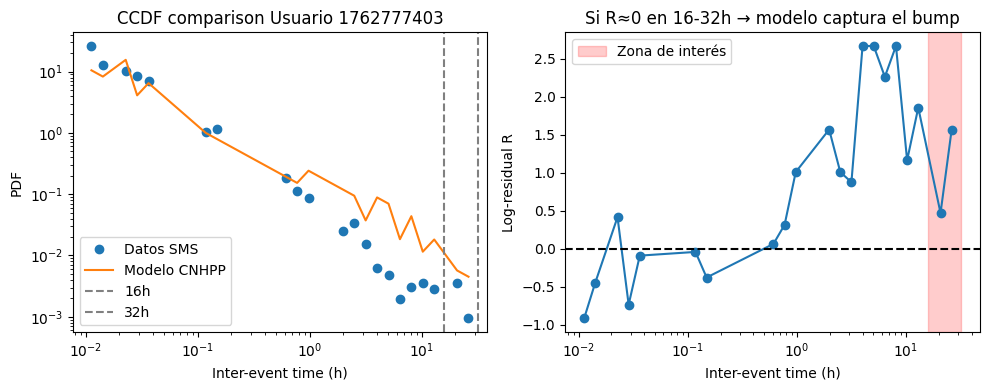

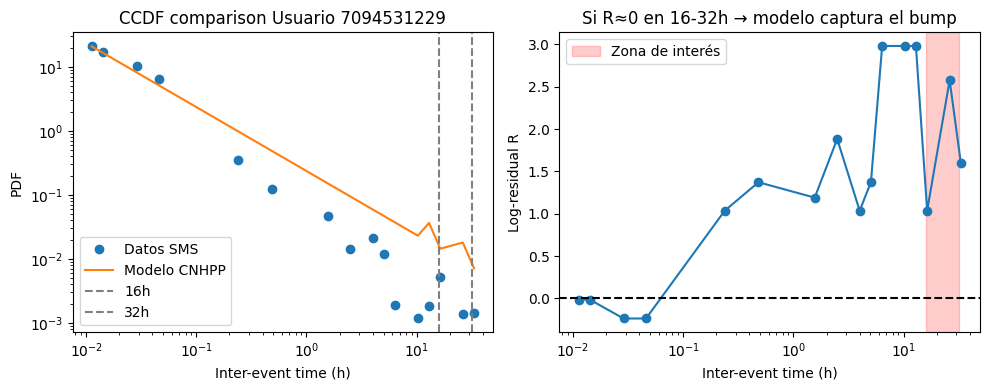

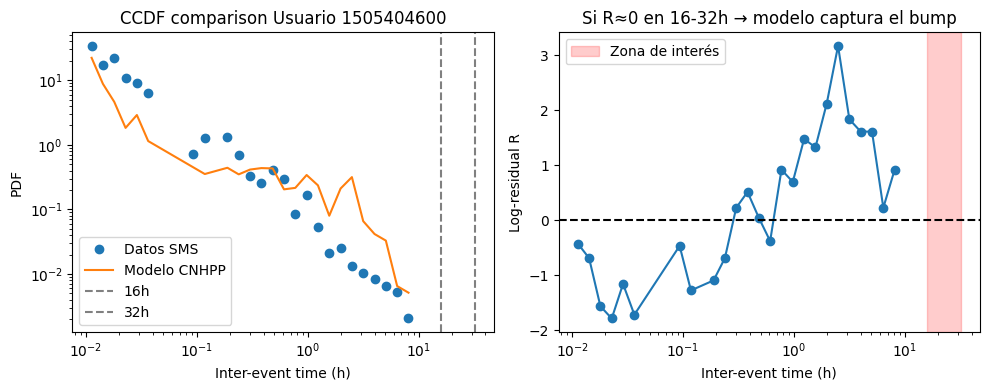

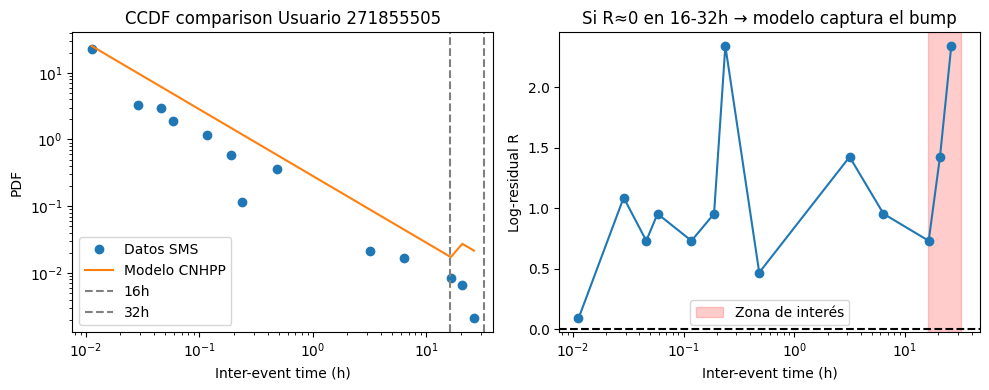

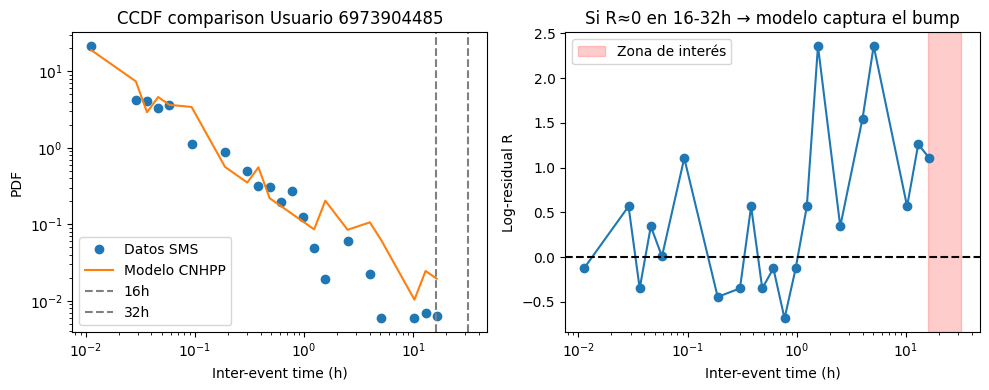

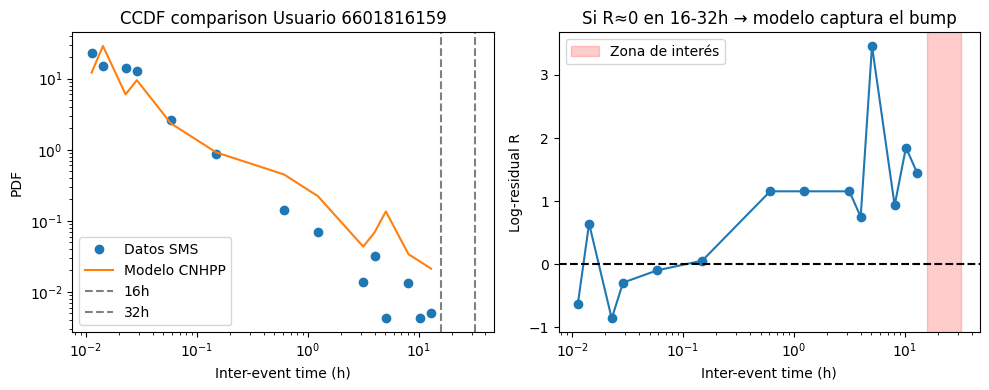

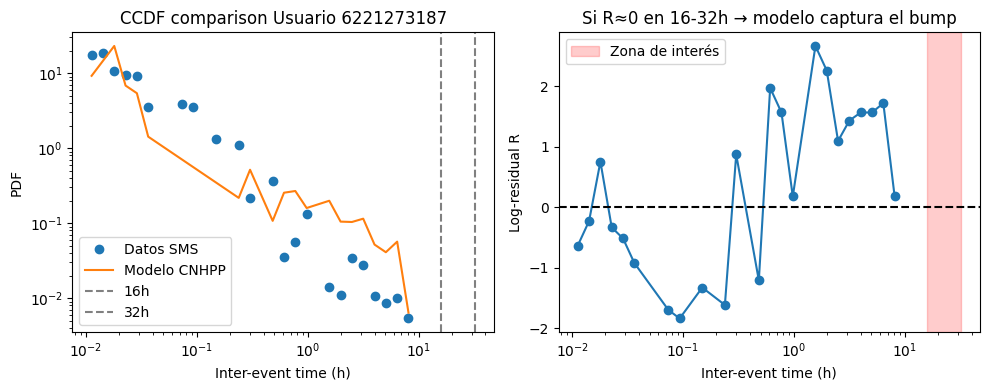

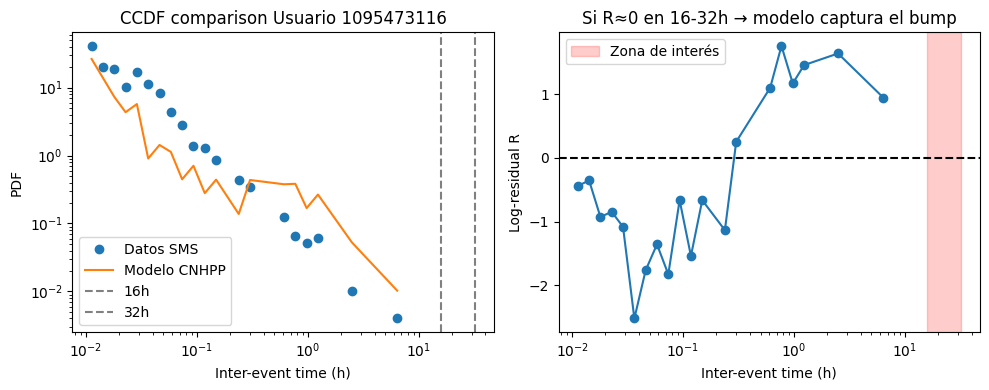

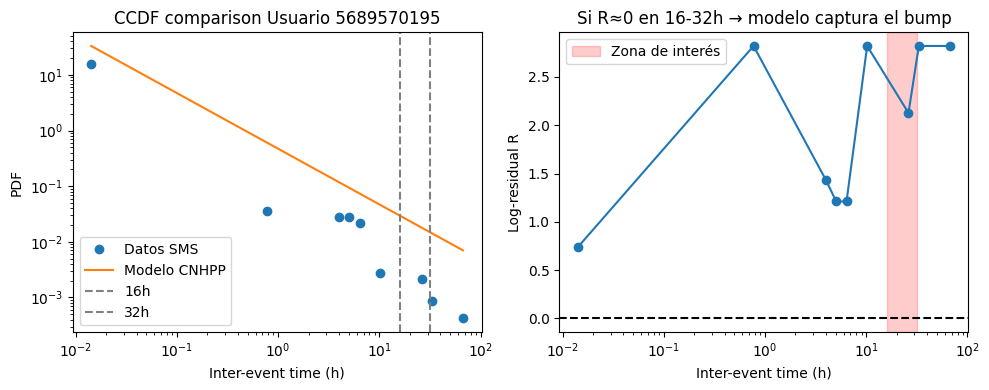

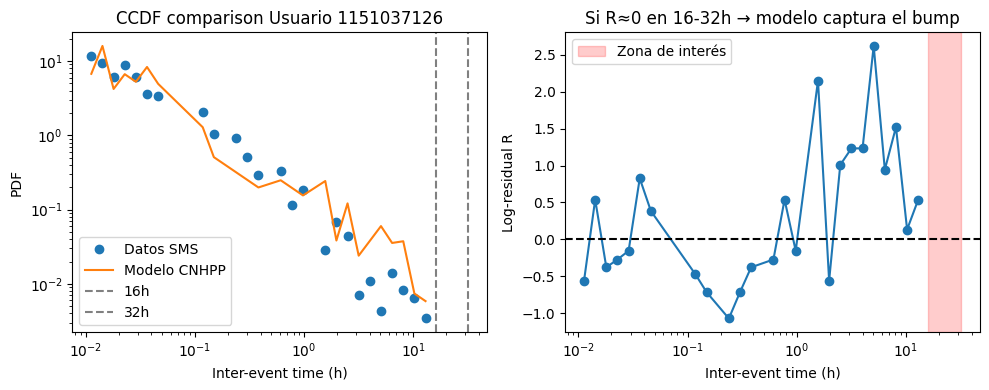

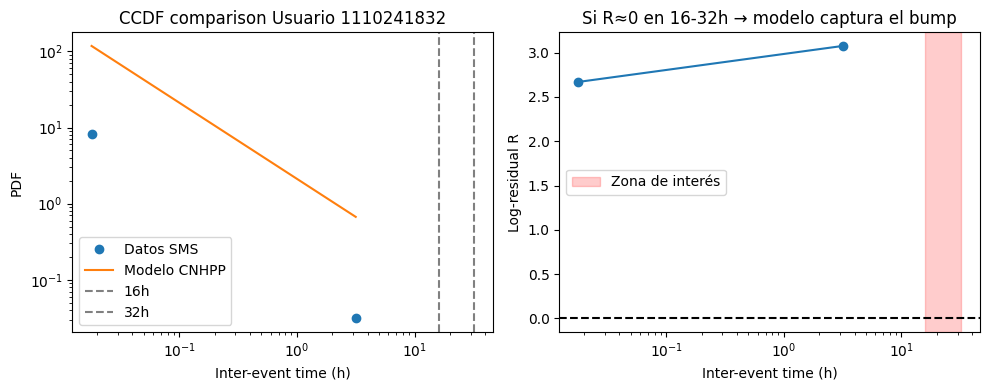

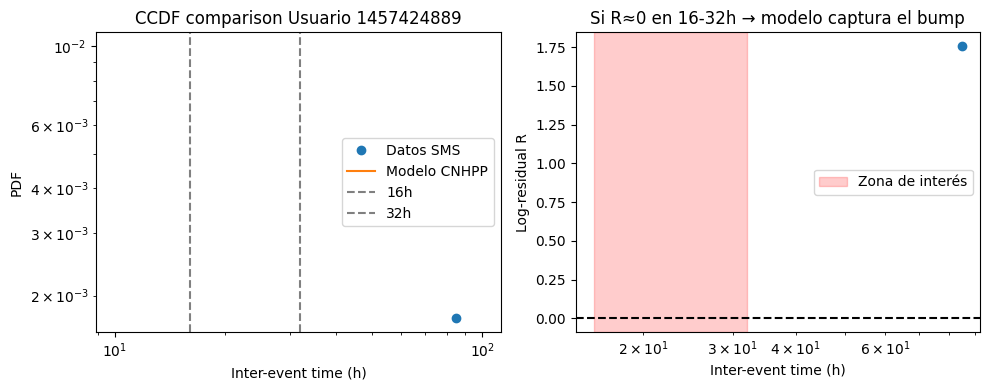

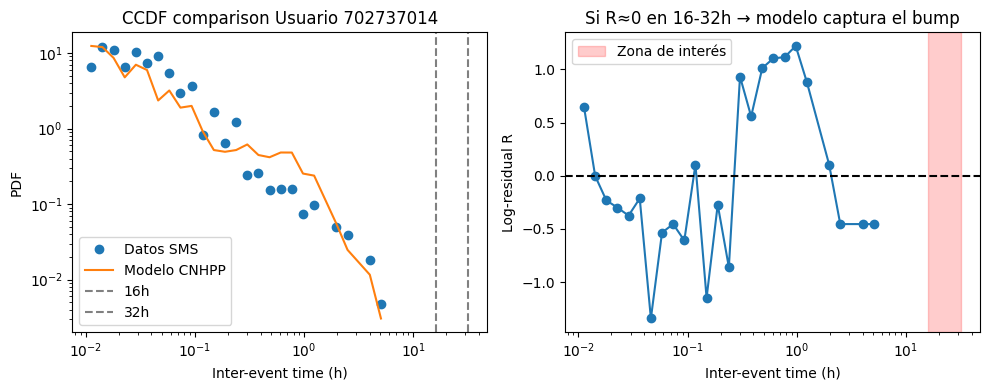

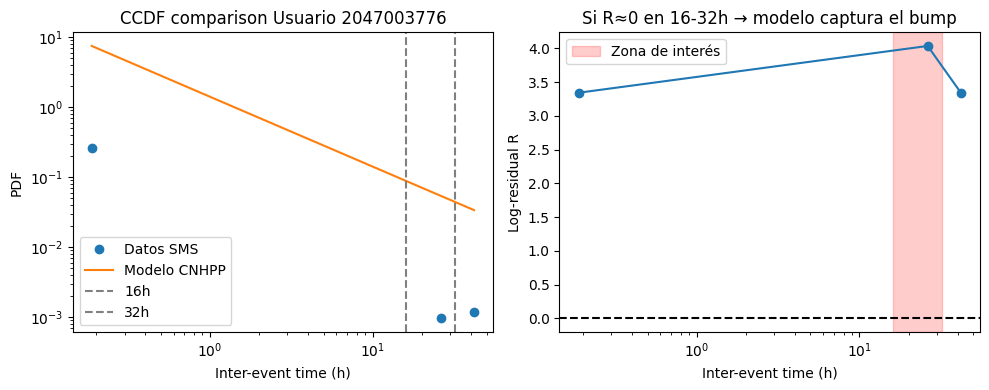

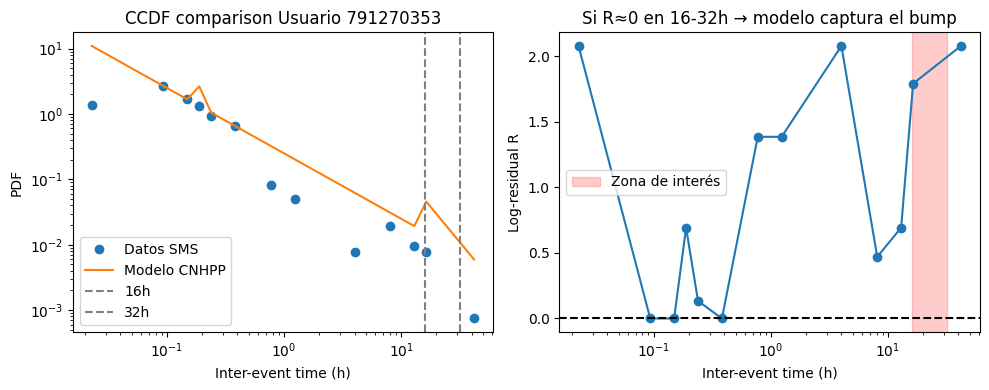

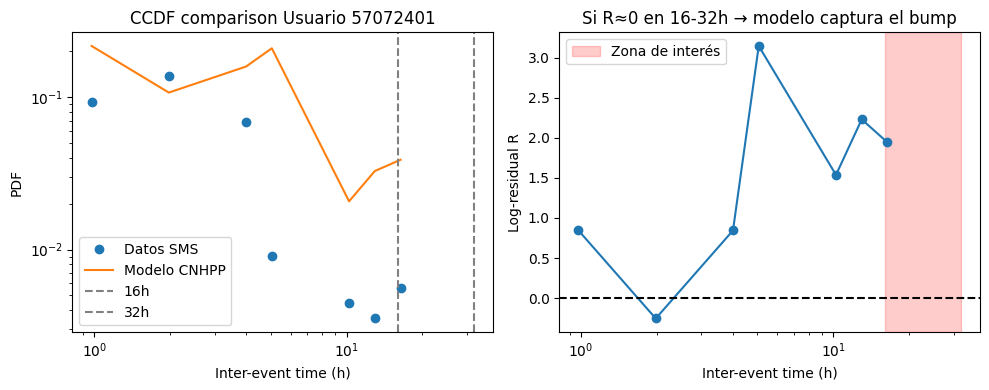

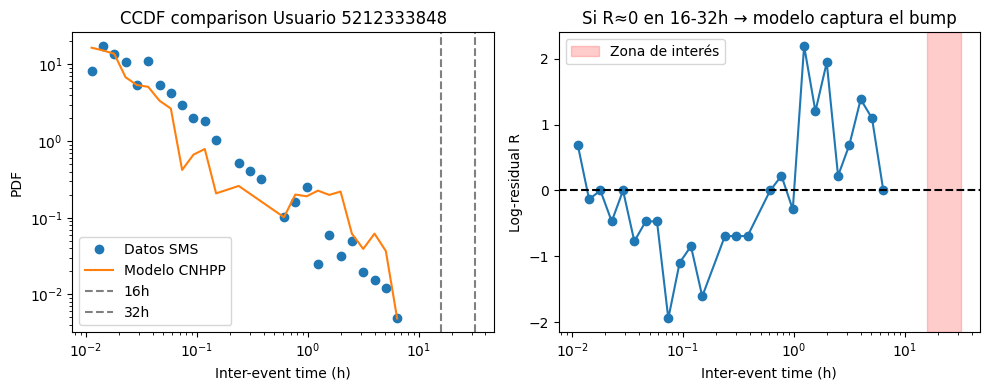

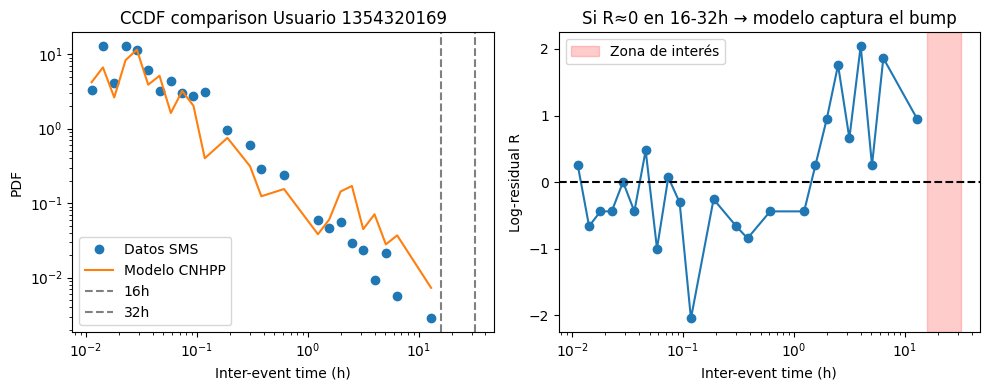

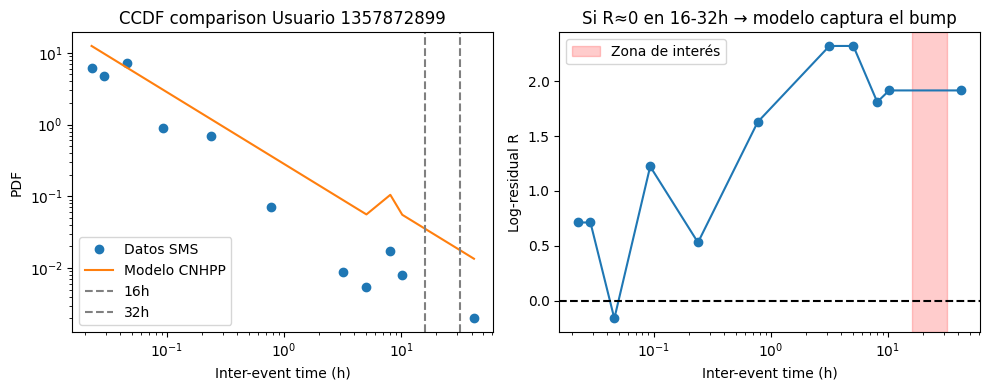

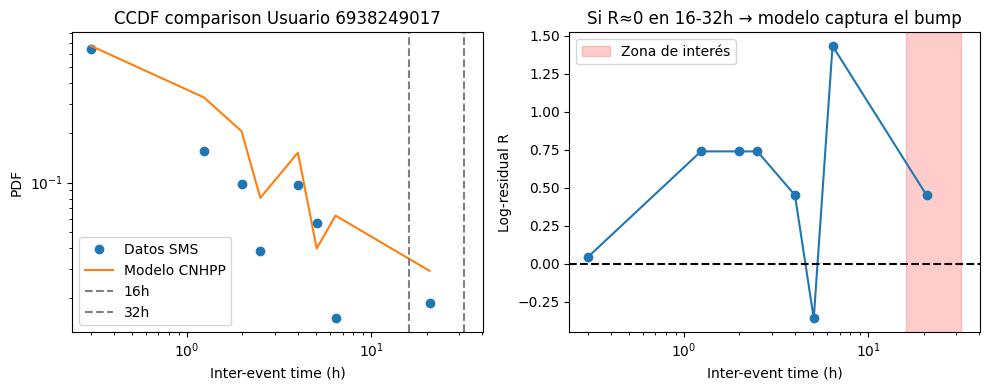

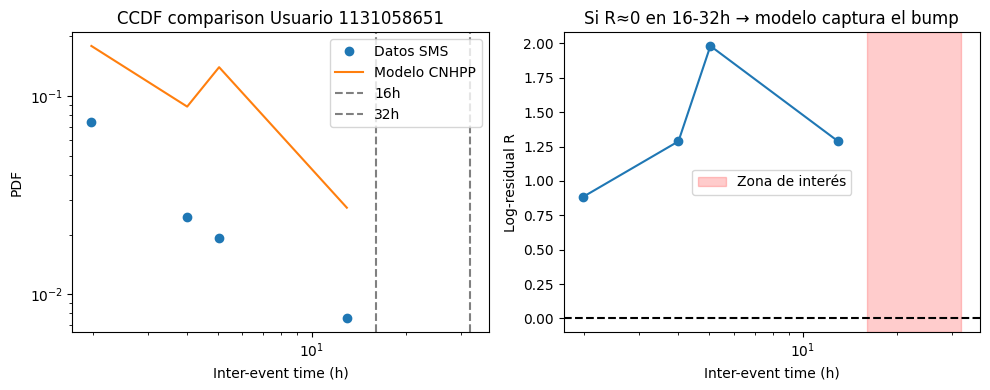

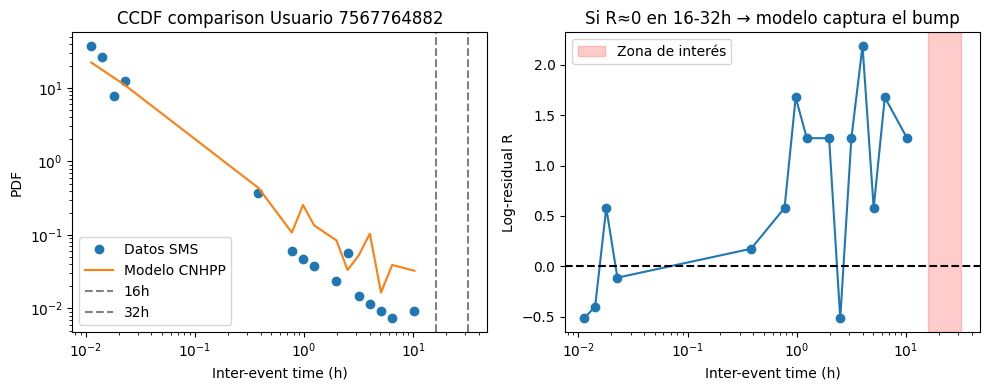

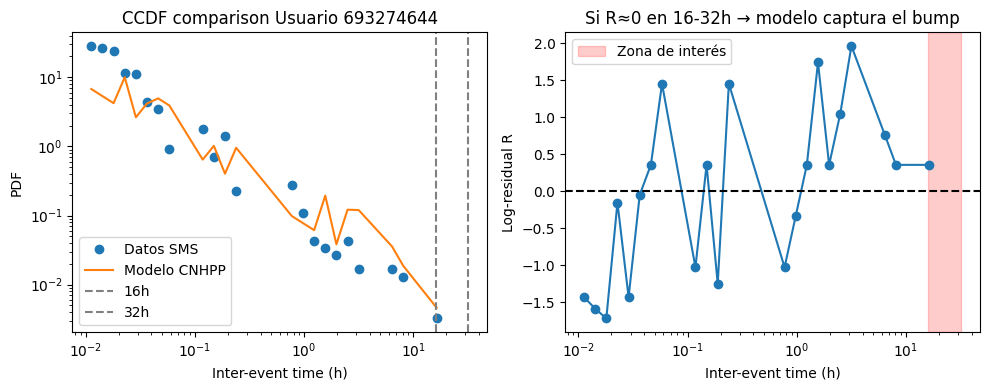

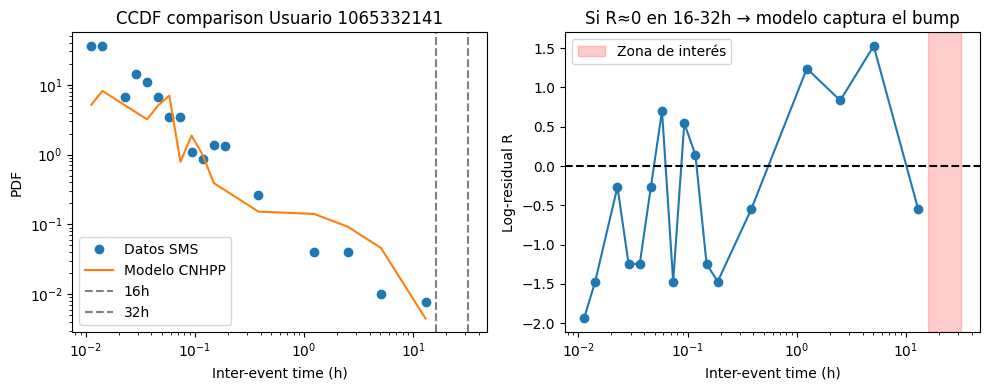

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


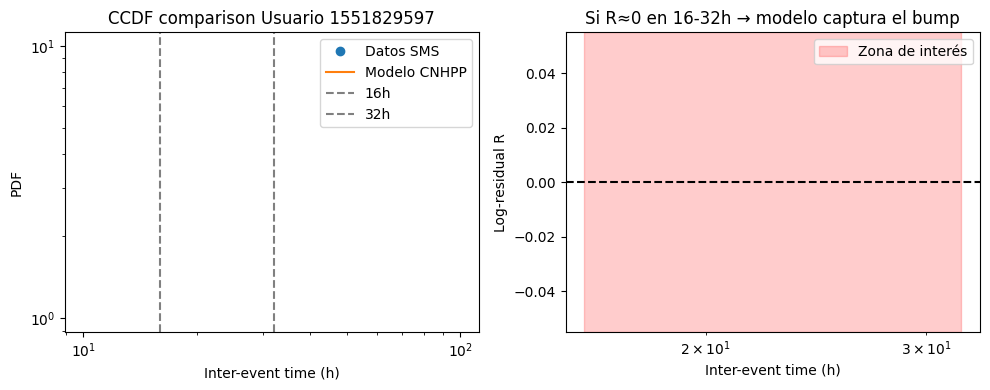

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


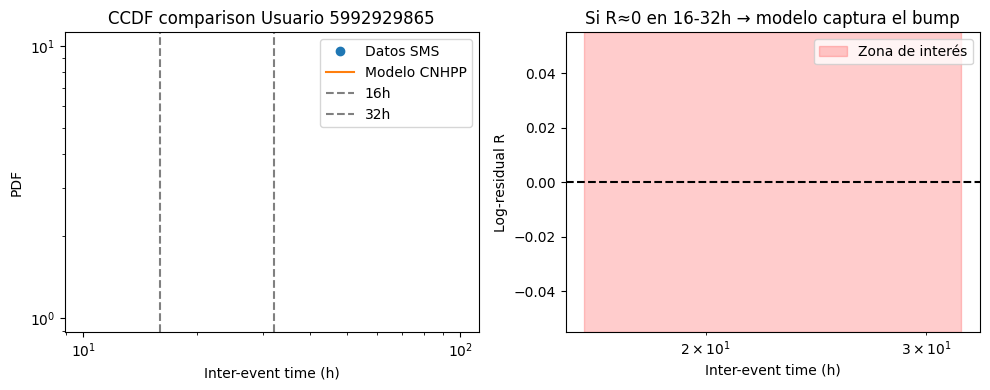

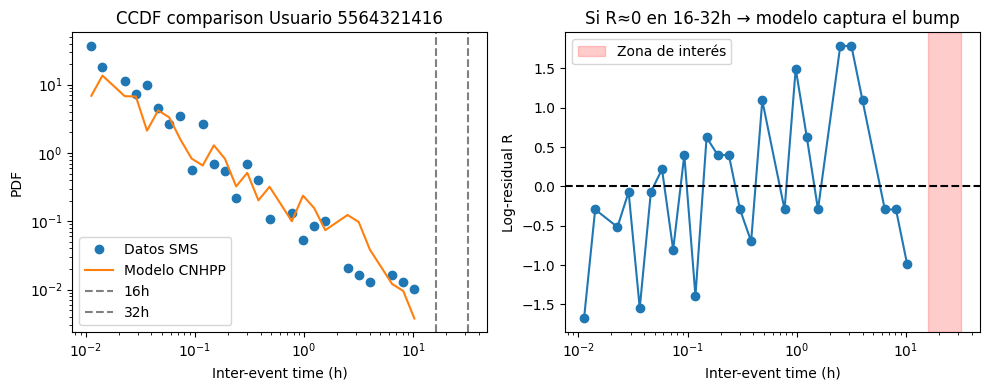

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


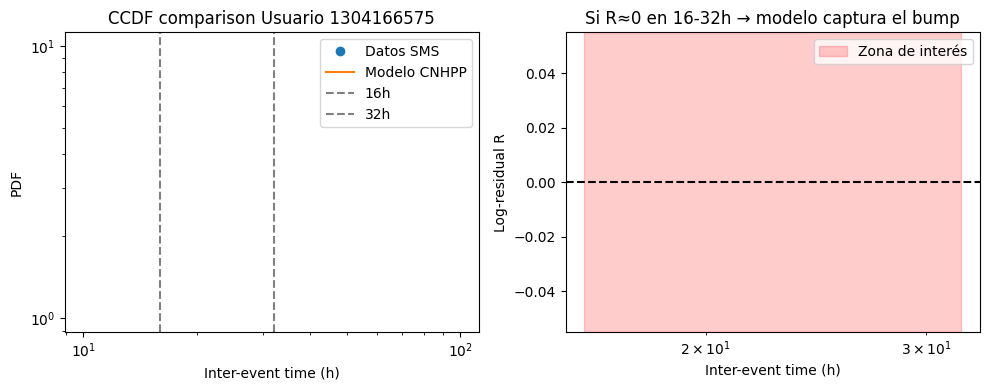

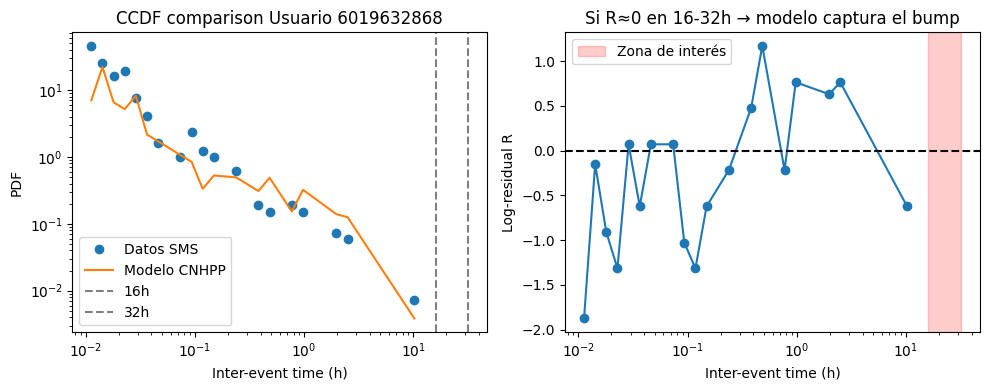

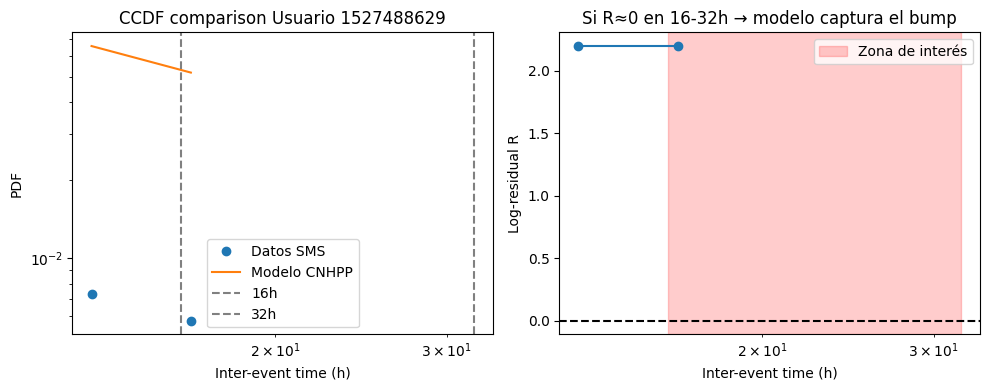

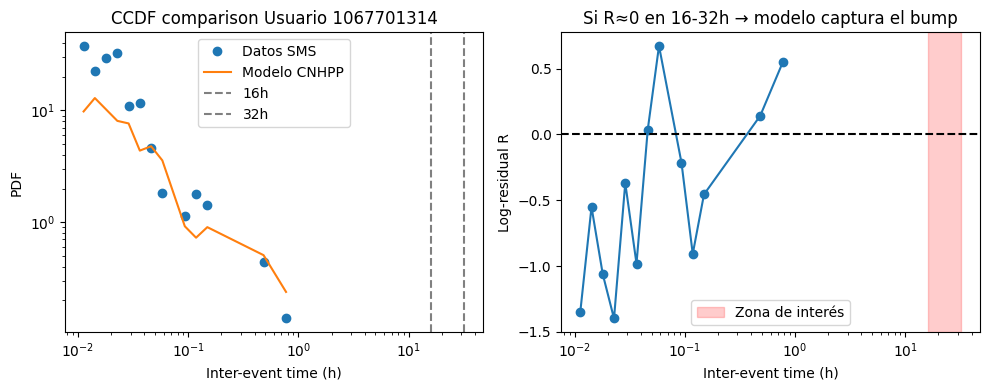

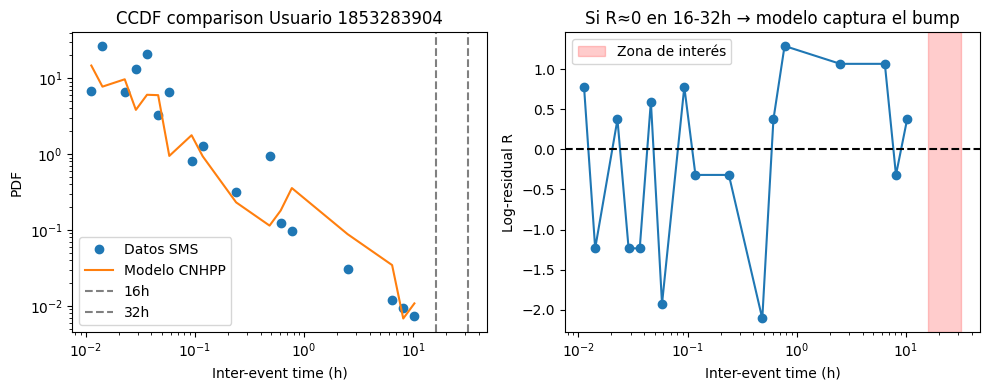

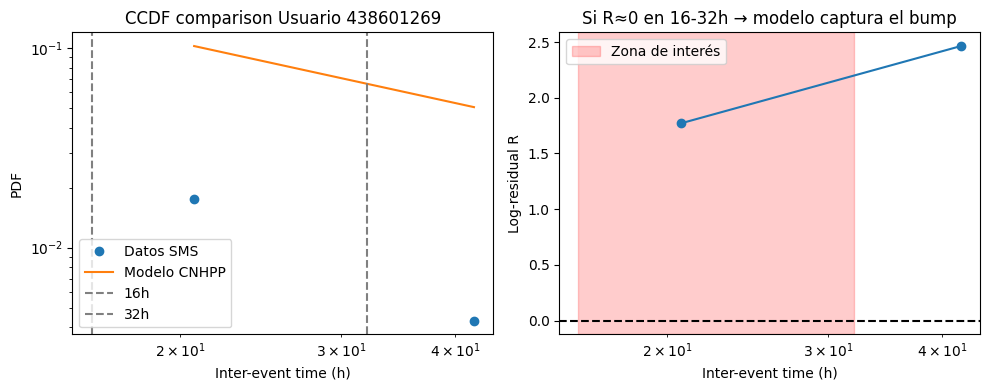

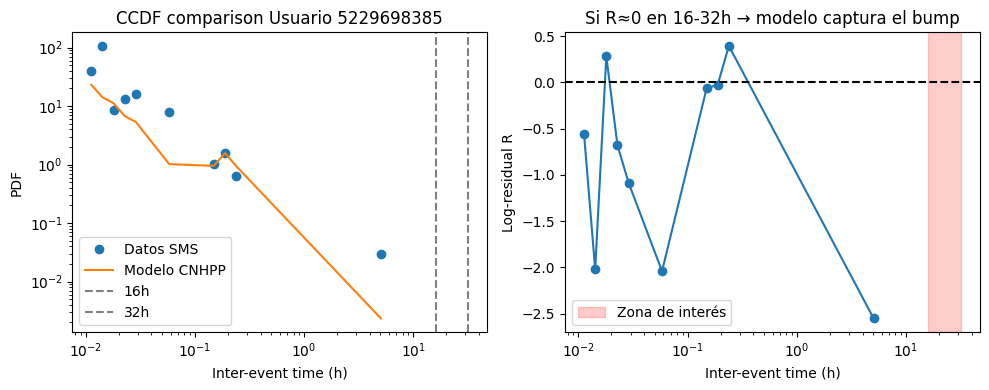

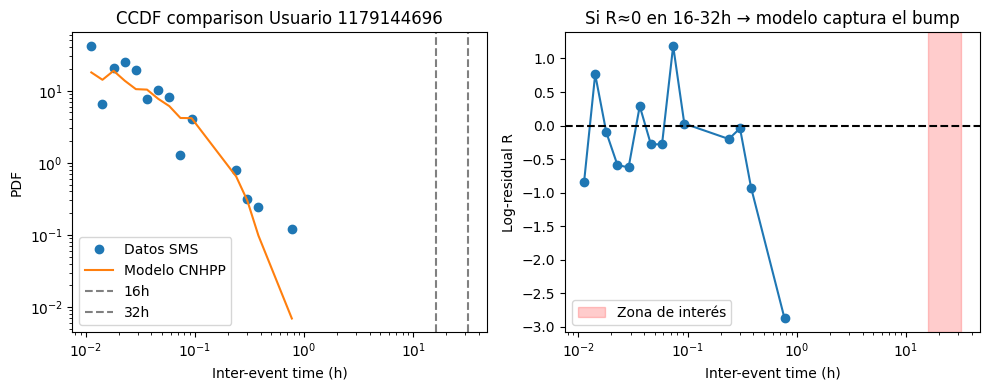

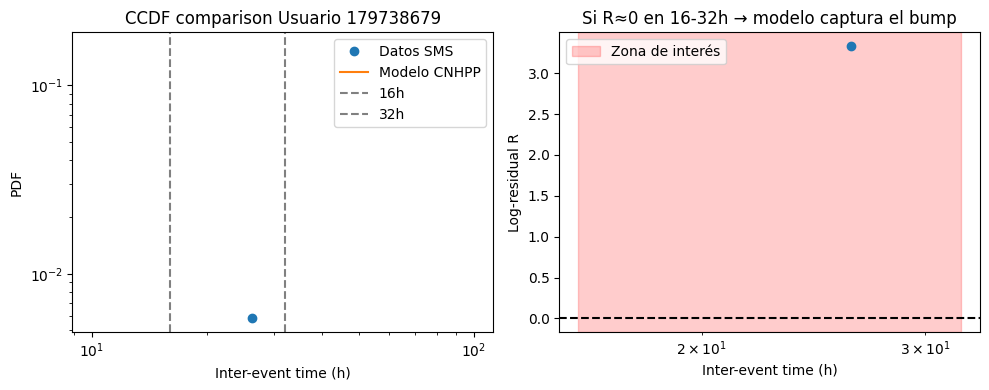

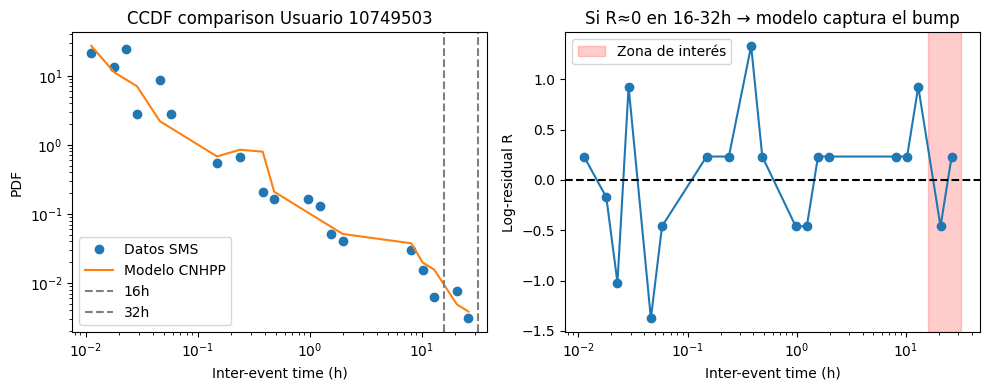

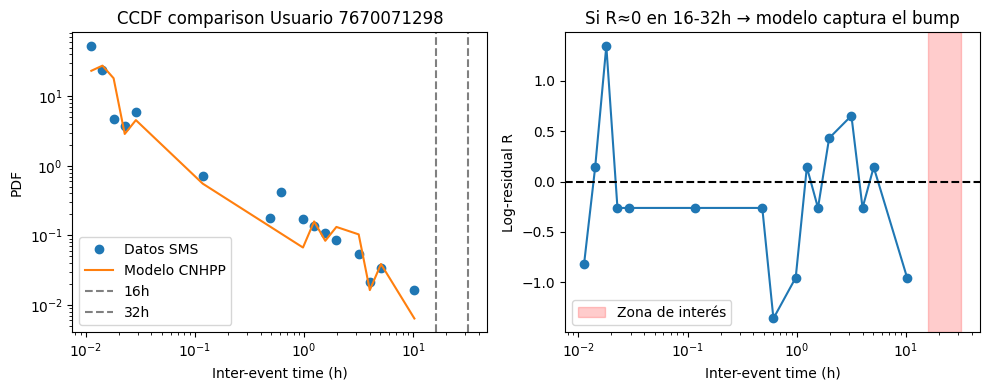

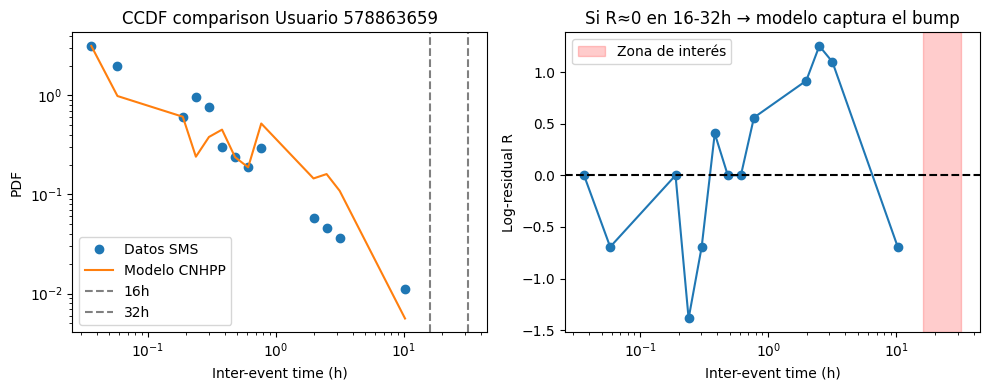

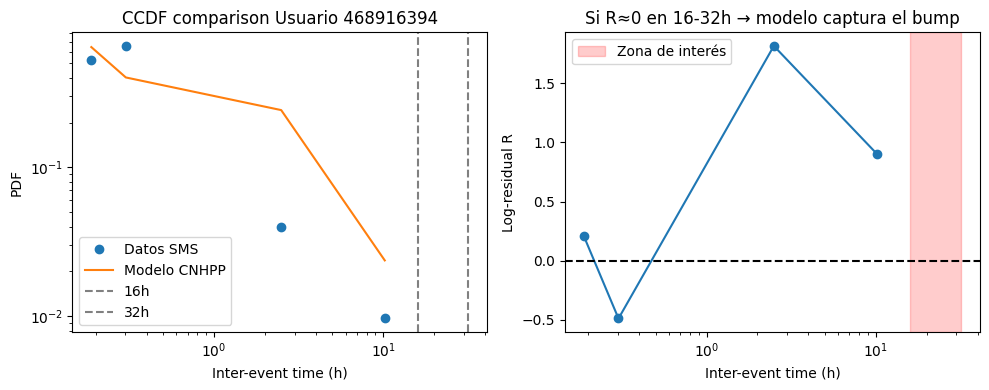

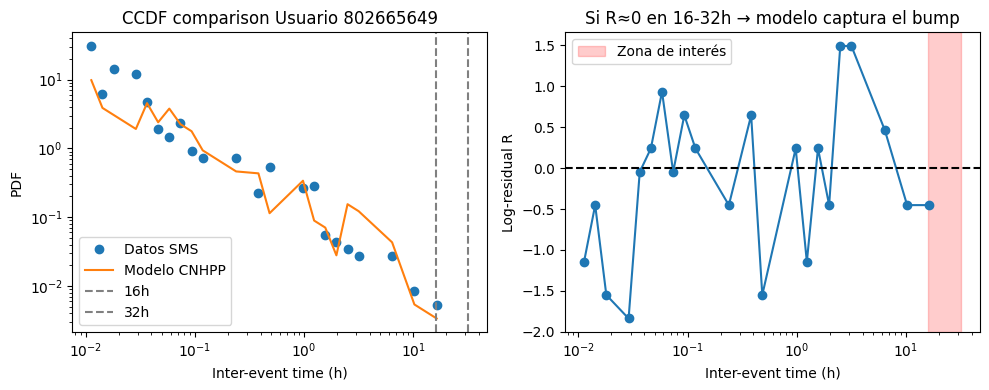

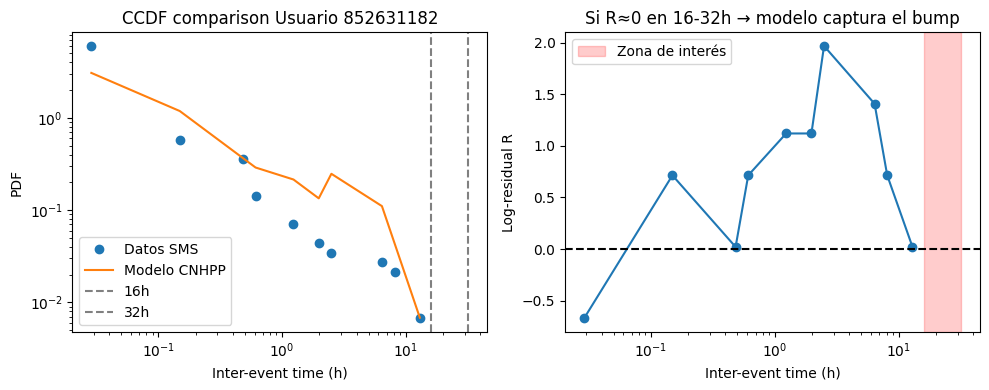

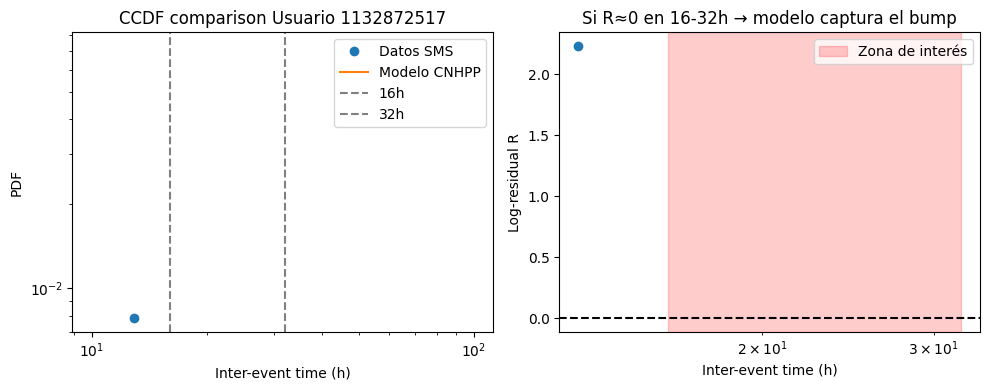

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


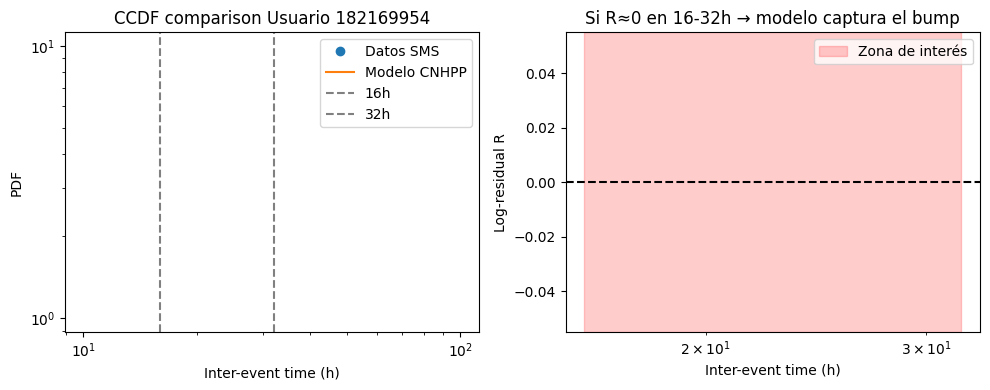

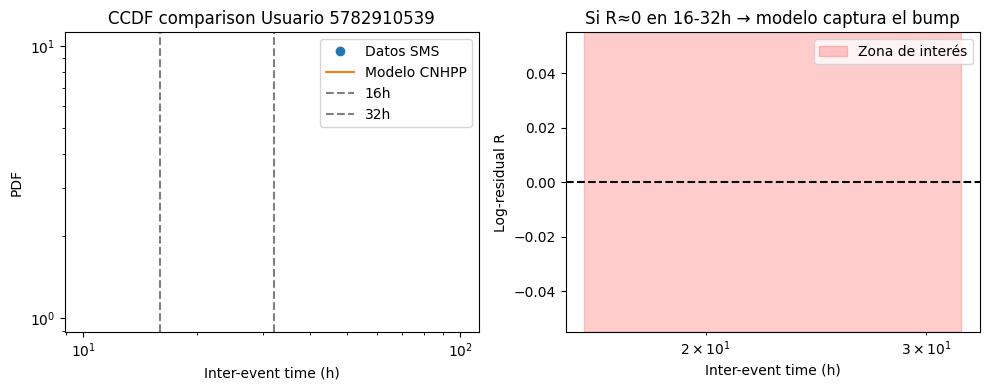

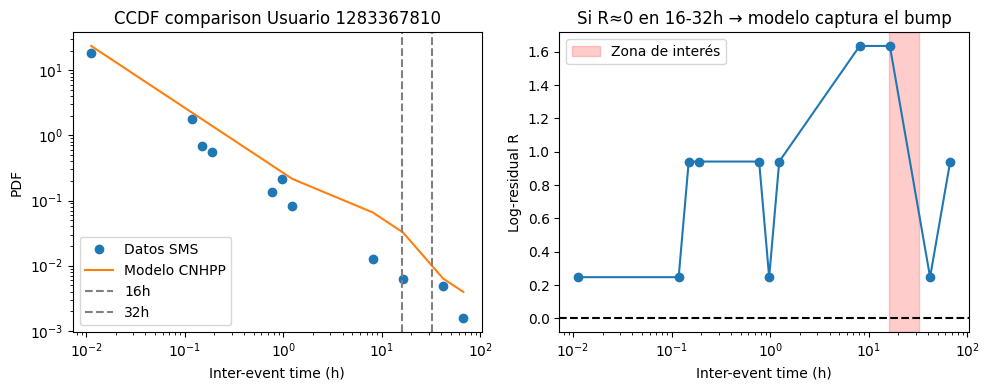

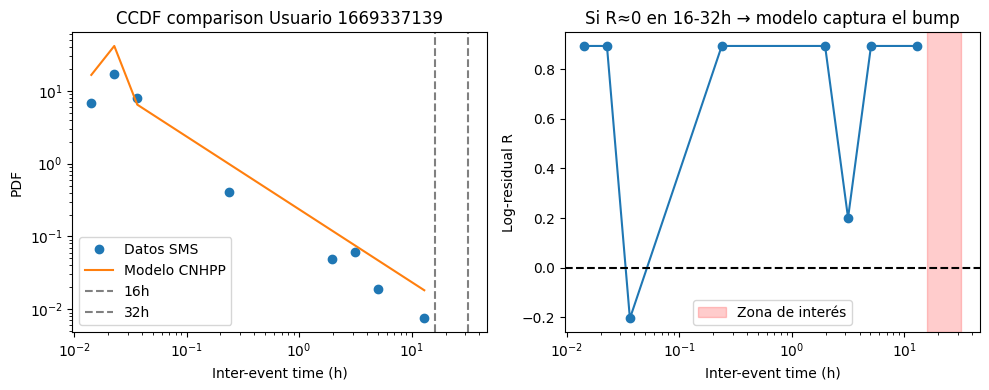

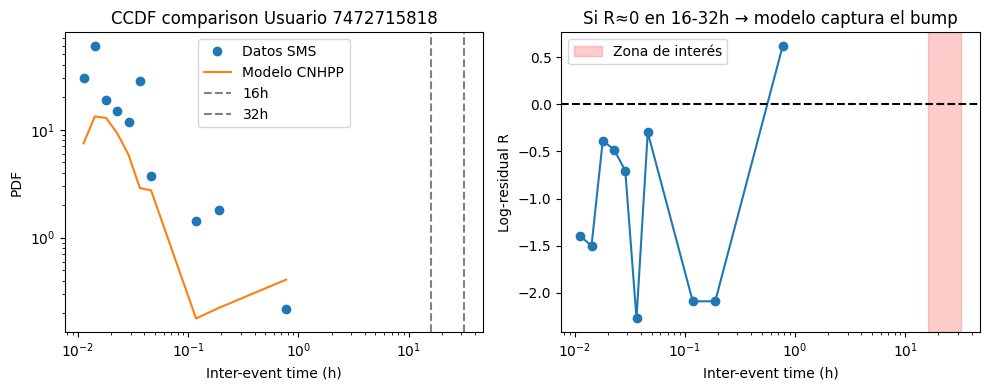

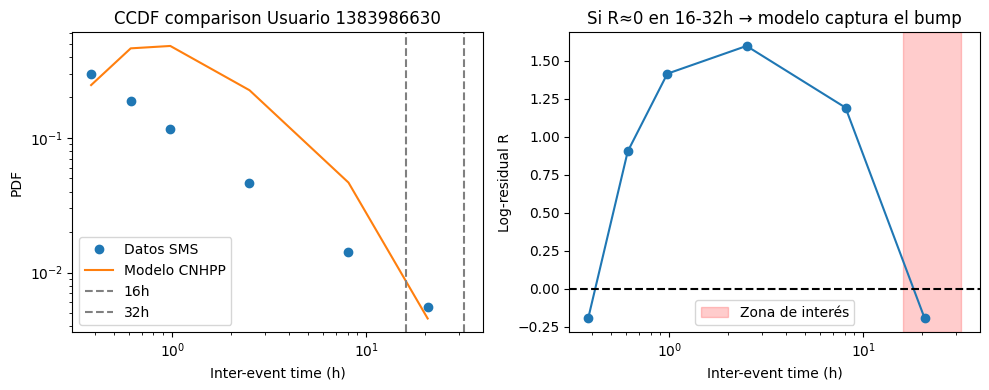

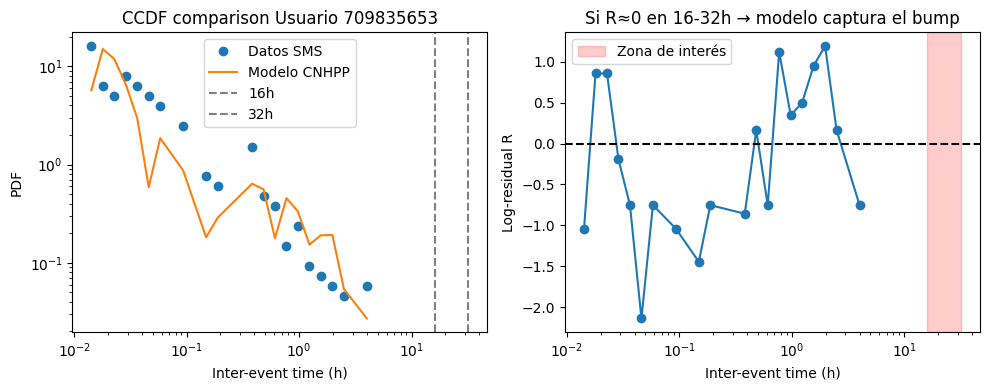

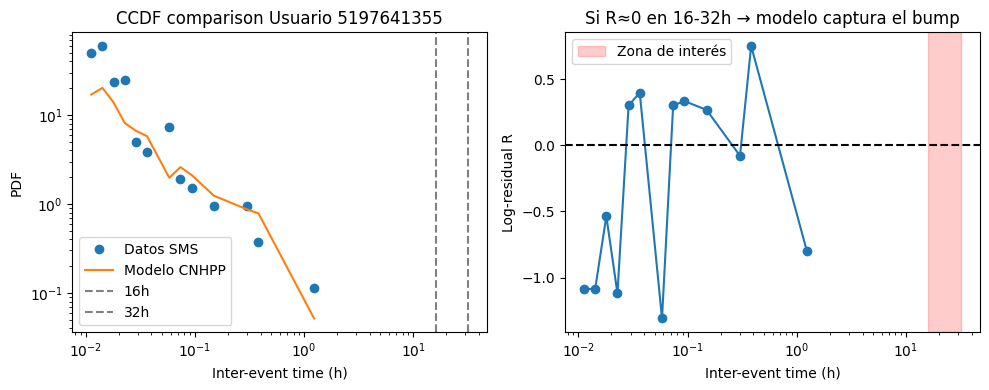

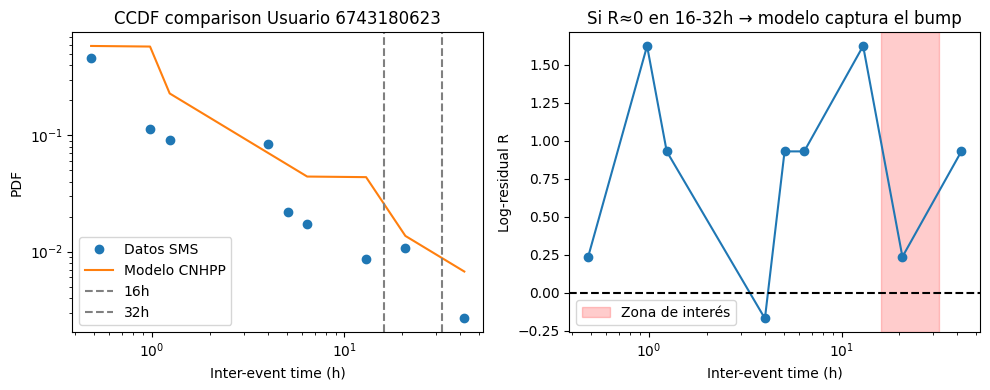

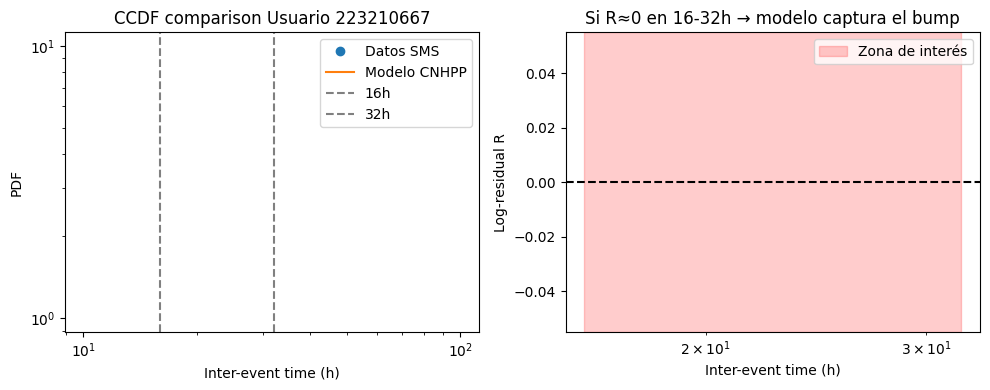

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


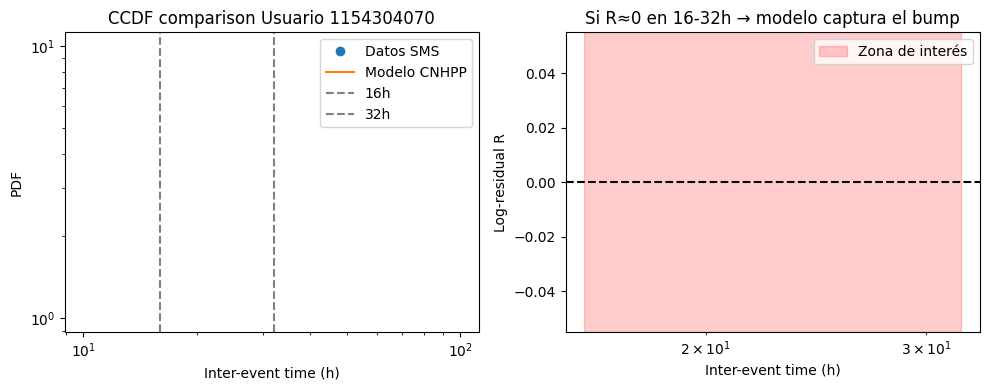

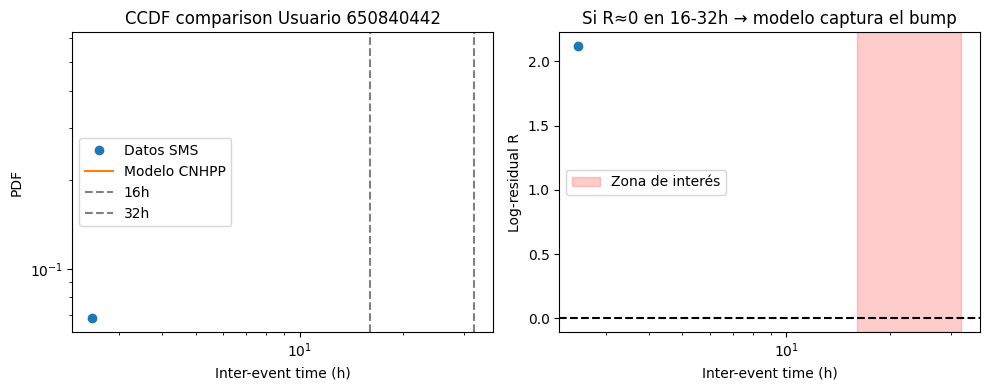

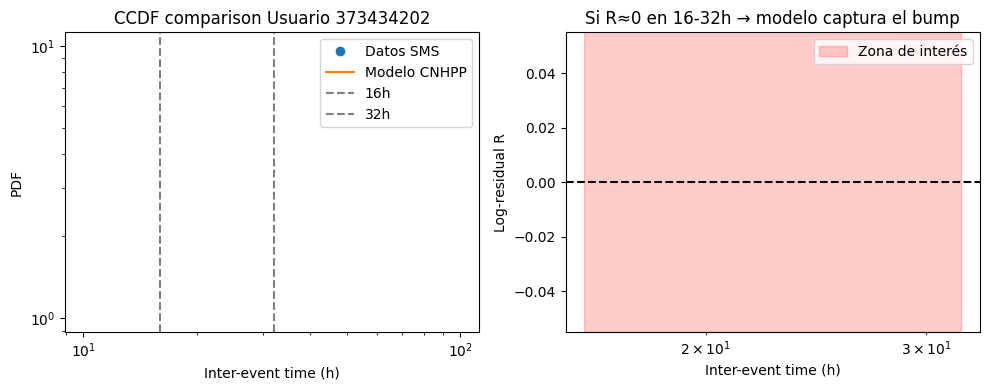

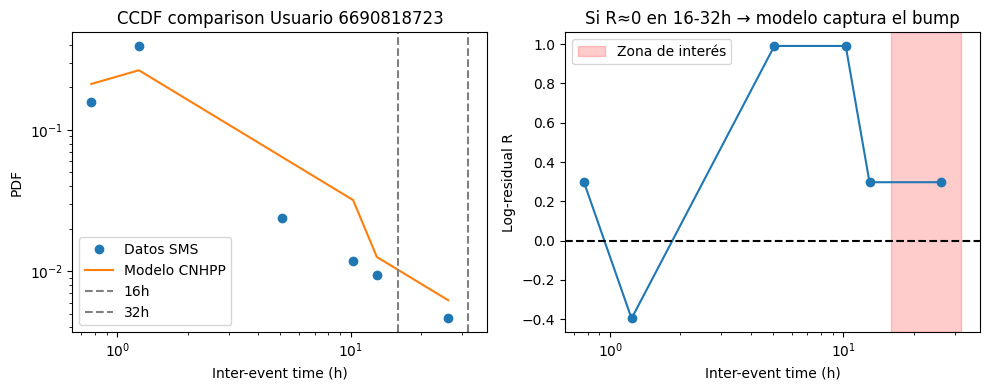

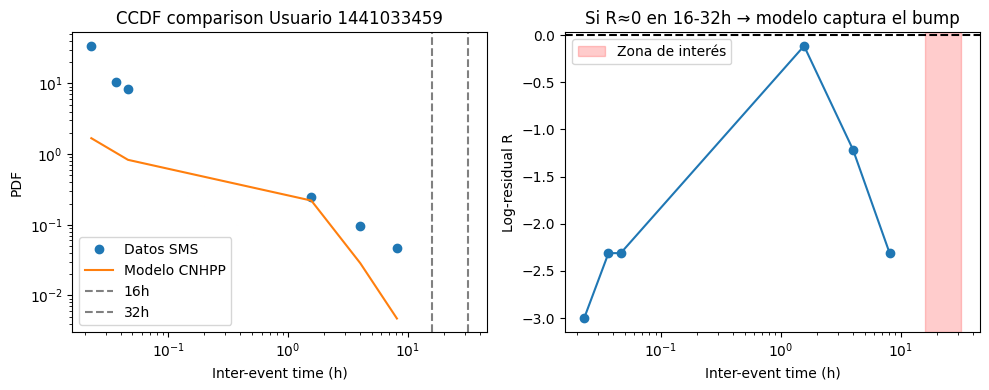

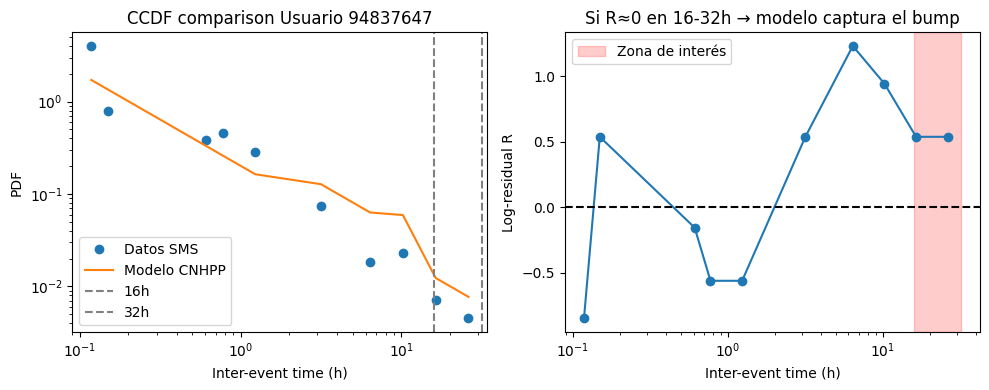

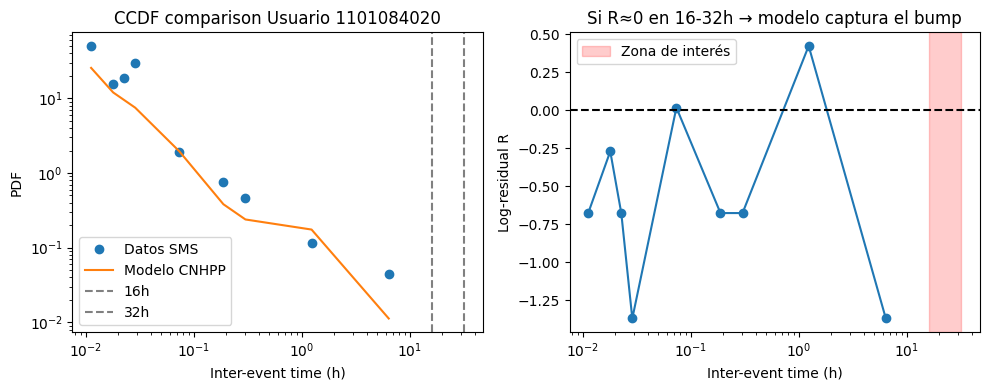

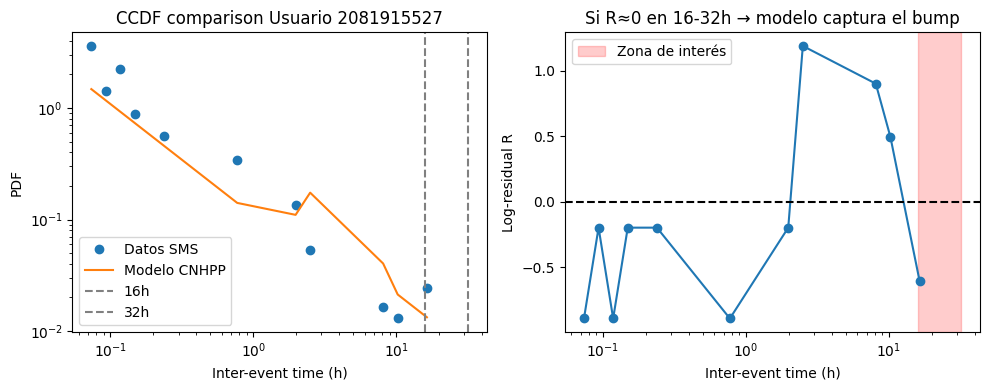

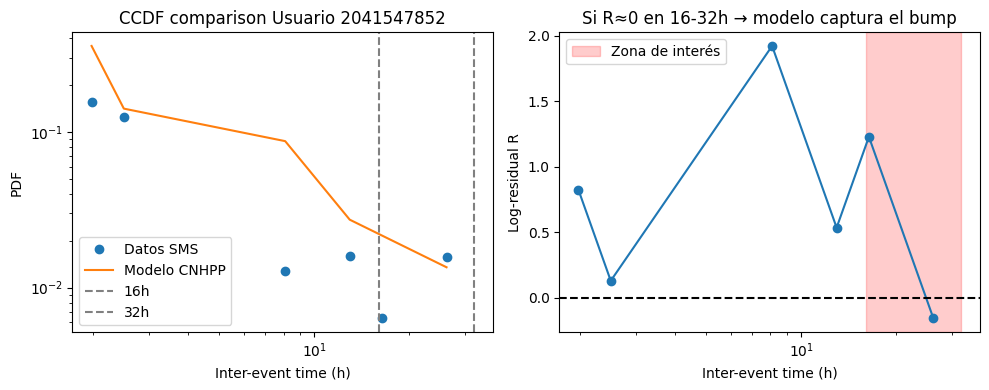

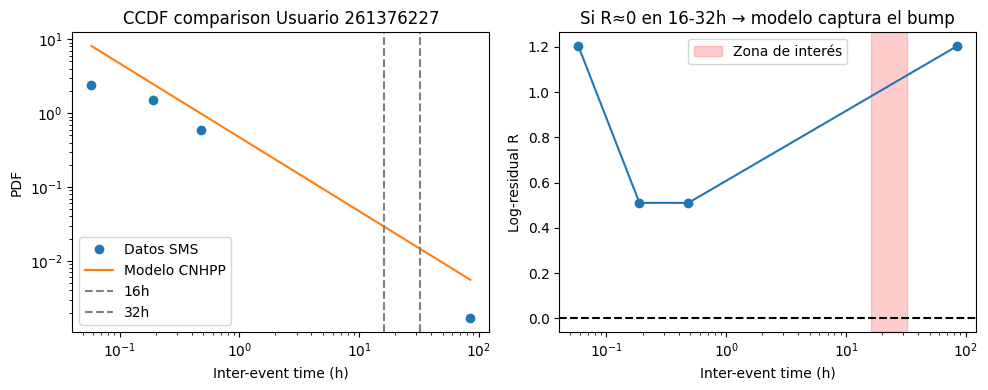

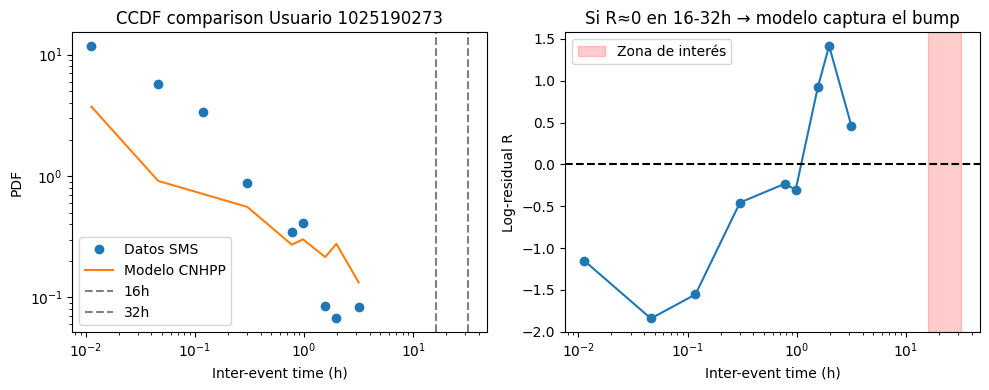

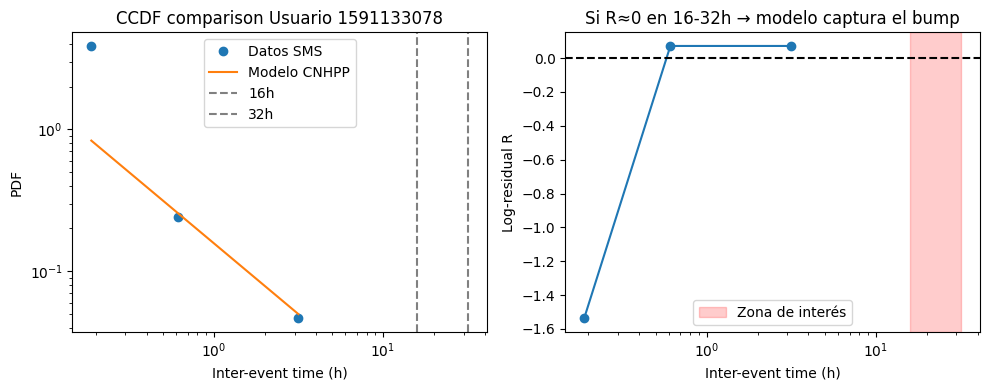

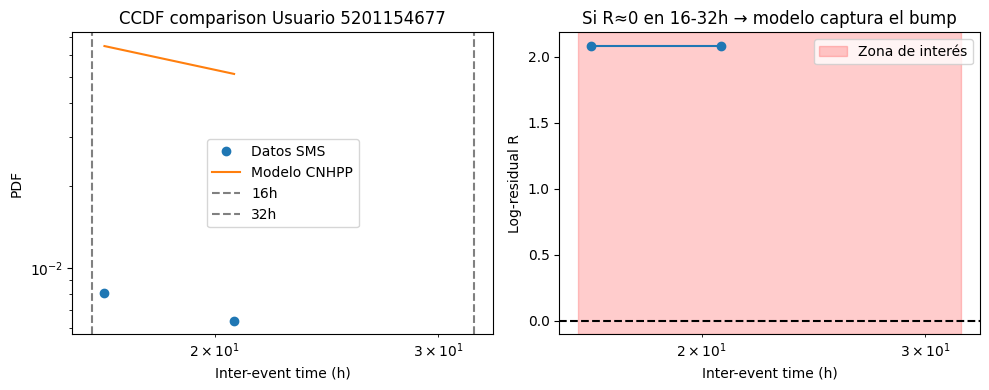

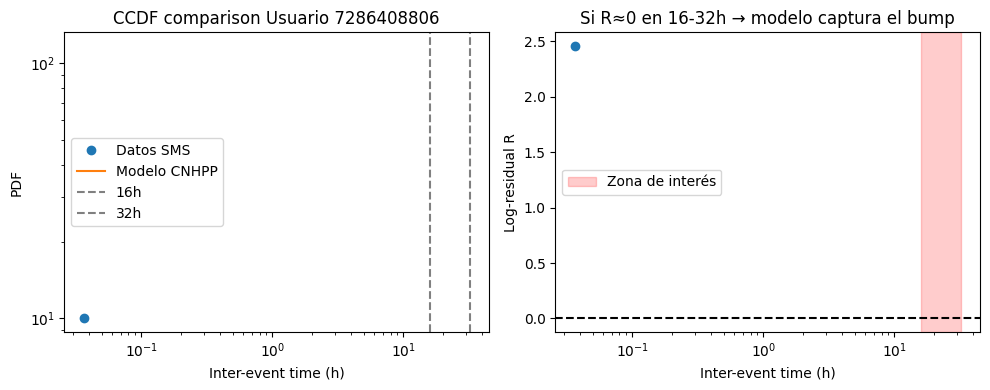

In [57]:
# Plot the log residuals for each user
for user_id in active_users:
    if user_id not in parameters_users:
        continue
    
    user_events = df[df['sender_id'] == user_id]['date'].sort_values()
    events_hours = (user_events - user_events.iloc[0]).dt.total_seconds() / 3600
    empirical_iets = np.diff(events_hours.values)
    
    sim_events = simulated_cascades[user_id]
    simulated_iets = np.diff(sim_events)
    
    plot_log_residuals(empirical_iets, simulated_iets, title=f'Usuario {user_id}')  